<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🏦 Bank Customer Churn 📉
    </h1>
</div>


# 📂 Overview

* **Background** <br>
Every bank wants to hold there customers for sustaining their business. Understanding the reasons why customers leave will help banks improve retention policies and reduce costs.

* **Goal of the Project** <br>
Based on the data, we will find out what causes customers to leave and then come up with appropriate strategies to help the bank.

**Key Features**

**Target Variable** <br>
- `Exited`: *whether or not the customer left the bank.*

**General Property Characteristics** <br>
- `RowNumber`: Corresponds to the record (row) number and has no effect on the output.
- `CustomerId`: Contains random values and has no effect on customer leaving the bank.
- `Surname`: The surname of a customer has no impact on their decision to leave the bank.
- `CreditScore`: can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank.
- `Geography`: A customer’s location can affect their decision to leave the bank.
- `Gender`: It’s interesting to explore whether gender plays a role in a customer leaving the bank.
- `Age`: This is certainly relevant, since older customers are less likely to leave their bank than younger ones.
- `Tenure`: Refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to leave a bank.
- `Balance`: Also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances.
- `NumOfProducts`: Refers to the number of products that a customer has purchased through the bank.
- `HasCrCard`: Denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank.
- `IsActiveMember`: Active customers are less likely to leave the bank.
- `EstimatedSalary`: As with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries.

**Files Provided**

* `train.csv`: The train dataset.
* `test.csv`: The test dataset (no target).
* `credit_risk_dataset.csv`: The original dataset.

Source: [Binary Classification with a Bank Churn Dataset](https://www.kaggle.com/competitions/playground-series-s4e1)

Source: [Bank Customer Churn Prediction](https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction)

**Project Objective**

The primary objective of this notebook is to **EDA and build machine learning model to predict**.

Key components of the approach include:

* **Exploratory Data Analysis (EDA):** Understand feature distributions, relationships.
* **Feature Engineering:** Encode categorical variables and align schema across training and test data.
* **Modeling:** Train with some models and choise the best model for predicting.
* **Multi-Label Prediction Strategy:** Generate predictions for each test row.
* **Evaluation Framework:** <br>
  * Cross-validation.
  * Metrics: ROC-AUC

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [214]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import shap

# Statistical functions
from scipy.stats import skew, kurtosis, probplot

# Display utilities for Jupyter notebooks
from IPython.display import display, HTML

# Machine learning preprocessing and modeling
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Metrics
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             precision_recall_curve, classification_report, average_precision_score)

# Statistical
from scipy.stats import chi2_contingency
from scipy.stats import probplot
from scipy.stats import kruskal
import scikit_posthocs as sp
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
from scipy.stats import levene
from scipy import stats
import pingouin as pg
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500) # To display all the columns of dataframe
pd.set_option("max_colwidth", None) # To set the width of the column to maximum

In [ ]:
class Config:
    seed = 42
    max_iter = 50000
    n_split_shuffle = 1
    n_split_kfold = 5
    test_size = 0.2
    train_csv = "train.csv"
    test_csv = "test.csv"
    original_csv = "Churn_Modelling.csv"
    target_feature = "Exited"   

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #2e7d32; 
    padding: 20px; 
    background: linear-gradient(125deg, #1b5e20 5%, #43a047 40%, #81c784 75%, #c8e6c9 100%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>

In [156]:
# Load the datasets
df_train = pd.read_csv(Config.train_csv)
df_origin = pd.read_csv(Config.original_csv)
df_test = pd.read_csv(Config.test_csv)

# Verify shapes
print("[i] Train Data Shape:", df_train.shape)
print("\n[i] Origin Data Shape:", df_origin.shape)
print("\n[i] Test Data Shape:", df_test.shape)

[i] Train Data Shape: (165034, 14)

[i] Origin Data Shape: (10002, 14)

[i] Test Data Shape: (110023, 13)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #2e7d32; 
    padding: 20px; 
    background: linear-gradient(125deg, #1b5e20 5%, #43a047 40%, #81c784 75%, #c8e6c9 100%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>

In [157]:
# Display few rows of each dataset
print("[i] Train Data Preview:")
display(df_train.head())

print("\n[i] Origin Data Preview:")
display(df_origin.head())

print("\n[i] Test Data Preview:")
display(df_test.head())

[i] Train Data Preview:


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0



[i] Origin Data Preview:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0



[i] Test Data Preview:


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,165034,15773898,Lucchese,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75
1,165035,15782418,Nott,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27
2,165036,15807120,K?,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09
3,165037,15808905,O'Donnell,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57
4,165038,15607314,Higgins,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00


In [158]:
# Display information about the DataFrames
print("[i] Train Data Info:")
df_train.info()

print("\n[i] Origin Data Info:")
df_origin.info()

print("\n[i] Test Data Info:")
df_test.info()

print("\n[✓] Completed displaying DataFrame info.")

[i] Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB

[i] Origin Data Info:
<class 'pandas.core.frame.Data

## Insights from Initial Data Exploration

**Dataset Size and Structure**
   - The **training dataset** contains 165034 samples with 14 columns, including the target variable `Exited`.
   - The **original dataset** has 10002 samples and 14 columns, similar in structure but smaller in size. 
   - The **test dataset** includes 110023 samples with 13 columns (without the target), ready for prediction.

**Feature Overview**  
   - Both datasets include all important attributes:
     - **Numerical features:** `CreditScore`, `Age`, `Tenure`, `Balance`, `EstimatedSalary`.
     - **Categorical features:** `Geography`, `Gender`, `HasCrCard`, `IsActiveMember`, `NumOfProducts`.
   - The target variable is **int64** value but we need to convert to **int8** to save memory usage.

**Data Completeness**  
   - The dataset have **no missing values** on train and test datasets but the missing value was detected on the origin dataset. We need to handle it.
   - Data types are appropriate: numerical features is float64 and int64, and categorical features are objects (strings).
   - The columns `Surname`, `id` are not meaningful for analysis. So these columns are not really a part of the information we should care about. We can drop them.

In [159]:
# Drop columns Surname, id
df_train.drop(columns="Surname", axis=1, inplace=True)
df_train.drop(columns="id", axis=1, inplace=True)
df_train.drop(columns="CustomerId", axis=1, inplace=True)

df_origin.drop(columns="Surname", axis=1, inplace=True)
df_origin.drop(columns="RowNumber", axis=1, inplace=True)
df_origin.drop(columns="CustomerId", axis=1, inplace=True)

list_test_id = df_test["id"].copy().to_list()
df_test.drop(columns="Surname", axis=1, inplace=True)
df_test.drop(columns="id", axis=1, inplace=True)
df_test.drop(columns="CustomerId", axis=1, inplace=True)

# Remove space in name columns
df_train.columns = (
    df_train.columns
    .str.strip()
    .str.replace(" ", "")
)

df_origin.columns = (
    df_origin.columns
    .str.strip()
    .str.replace(" ", "")
)

df_test.columns = (
    df_test.columns
    .str.strip()
    .str.replace(" ", "")
)

In [160]:
num_features = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "NumOfProducts"]
cm = sns.light_palette("blue", as_cmap=True)
print("[i] Train Data describe:")
display(df_train[num_features].describe().T.style.background_gradient(cmap=cm))

print("\n[i] Test Data describe:")
display(df_test[num_features].describe().T.style.background_gradient(cmap=cm))

print("\n[i] Origin Data describe:")
display(df_origin[num_features].describe().T.style.background_gradient(cmap=cm))

[i] Train Data describe:


,count,mean,std,min,25%,50%,75%,max
CreditScore,165034.000000,656.454373,80.103340,350.000000,597.000000,659.000000,710.000000,850.000000
Age,165034.000000,38.125888,8.867205,18.000000,32.000000,37.000000,42.000000,92.000000
Tenure,165034.000000,5.020353,2.806159,0.000000,3.000000,5.000000,7.000000,10.000000
Balance,165034.000000,55478.086689,62817.663278,0.000000,0.000000,0.000000,119939.517500,250898.090000
EstimatedSalary,165034.000000,112574.822734,50292.865585,11.580000,74637.570000,117948.000000,155152.467500,199992.480000



[i] Test Data describe:


,count,mean,std,min,25%,50%,75%,max
CreditScore,110023.000000,656.530789,80.315415,350.000000,597.000000,660.000000,710.000000,850.000000
Age,110023.000000,38.122205,8.861550,18.000000,32.000000,37.000000,42.000000,92.000000
Tenure,110023.000000,4.996637,2.806148,0.000000,3.000000,5.000000,7.000000,10.000000
Balance,110023.000000,55333.611354,62788.519675,0.000000,0.000000,0.000000,120145.605000,250898.090000
EstimatedSalary,110023.000000,112315.147765,50277.048244,11.580000,74440.325000,117832.230000,154631.350000,199992.480000



[i] Origin Data describe:


,count,mean,std,min,25%,50%,75%,max
CreditScore,10002.000000,650.555089,96.661615,350.000000,584.000000,652.000000,718.000000,850.000000
Age,10001.000000,38.922311,10.487200,18.000000,32.000000,37.000000,44.000000,92.000000
Tenure,10002.000000,5.012498,2.891973,0.000000,3.000000,5.000000,7.000000,10.000000
Balance,10002.000000,76491.112875,62393.474144,0.000000,0.000000,97198.540000,127647.840000,250898.090000
EstimatedSalary,10002.000000,100083.331145,57508.117802,11.580000,50983.750000,100185.240000,149383.652500,199992.480000


**Feature Highlights**

* **CreditScore**: Mean \~650 (original data) or \~656 (train and test data), range 350–850 → covers both poor and excellent credit levels; high standard deviation indicates considerable dispersion.
* **Age**: Mean \~38 years, primarily concentrated in the working-age group (25% = 32 years, 75% = 42 or 44 years).
* **Tenure**: Average of 5 years, evenly distributed from 0–10 years → reflects diverse customer loyalty levels.
* **Balance**: High mean (\$55k/$76k) but large standard deviation (~\$62k); 25% of customers have a balance of \$0 → possibly low usage or fully withdrawn accounts.
* **EstimatedSalary**: Mean ~\$100k (original data) or ~\$113k (train and test data), wide range (\$11.58 – \$199,992), median close to mean → relatively uniform distribution.

**Overall Observations**

* The three datasets (train, test, origin) have **very similar distributions** in statistical measures (mean, median, min, max, percentiles).
* Several features (`Balance`, `EstimatedSalary`, `CreditScore`) show high dispersion → further analysis is needed to check for skewness and outliers.
* Customers are mostly within the working-age demographic, with an average tenure of 5 years, and exhibit diverse financial behaviors and engagement levels.

In [161]:
def cast_features(dfs, dtype_map):
    """
    Cast multiple features in multiple DataFrames to specific dtypes.

    Args:
        dfs (list): List of DataFrames to process.
        dtype_map (dict): {column_name: target_dtype} mapping.
    """
    for df in dfs:
        for col, dtype in dtype_map.items():
            if col in df.columns:
                df[col] = df[col].astype(dtype)

# Mapping of columns and their target data types
dtype_map = {
    "CreditScore": "int16",
    "Age": "int8",
    "Tenure": "int8",
    "Balance": "float32",
    "Exited": "int8",
    "EstimatedSalary": "float32",
    "HasCrCard": "int8",
    "IsActiveMember": "int8",
    "NumOfProducts": "int8"
}

df_origin.dropna(inplace=True)

# Apply the function to both df_train and df_test
cast_features([df_train, df_test, df_origin], dtype_map)

def convert_cat(features, df):
    """
    Convert specified columns to categorical dtype.
    This helps reduce memory usage and prepares features
    for encoding steps in the ML pipeline.
    """
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")

convert_cat(cat_features, df=df_train)
convert_cat(cat_features, df=df_origin)
convert_cat(cat_features, df=df_test)

print("[i] Train Data describe:")
display(df_train[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

print("\n[i] Origin Data describe:")
display(df_origin[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

print("\n[i] Test Data describe:")
display(df_test[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

[i] Train Data describe:


,count,unique,top,freq
Geography,165034,3,France,94215
Gender,165034,2,Male,93150
HasCrCard,165034,2,1,124428
IsActiveMember,165034,2,0,82885
NumOfProducts,165034,4,2,84291



[i] Origin Data describe:


,count,unique,top,freq
Geography,9998,3,France,5012
Gender,9998,2,Male,5455
HasCrCard,9998,2,1,7054
IsActiveMember,9998,2,1,5147
NumOfProducts,9998,4,1,5083



[i] Test Data describe:


,count,unique,top,freq
Geography,110023,3,France,63171
Gender,110023,2,Male,61942
HasCrCard,110023,2,1,82852
IsActiveMember,110023,2,0,55536
NumOfProducts,110023,4,2,56338


**1. Geography**

* Contains 3 countries: **France**, **Spain**, and **Germany**.
* **France** has the highest proportion in all three datasets (\~50–57%), indicating an **uneven distribution** across countries.
* Spain and Germany make up the remaining portion with noticeably smaller shares.

**2. Gender**

* Only 2 values: **Male** and **Female**.
* **Male** accounts for a slightly higher proportion (\~55%) compared to Female (\~45%) across all datasets → relatively balanced distribution, not heavily skewed.

**3. NumOfProducts**

* Four levels (1–4), with **2 products** being the most common (\~50% of customers).
* Levels 3 and 4 have very small proportions → can be grouped during analysis or modeling.

**4. HasCrCard**

* Two values: **1 (has a credit card)** and **0 (does not)**.
* Customers with a credit card (**1**) make up the majority (\~70–72%) across all datasets.

**5. IsActiveMember**

* Two values: **1 (active)** and **0 (inactive)**.
* Fairly balanced distribution: around 50–51% active and 49–50% inactive.

**Overall Observations**

* The distribution patterns of categorical variables are **almost identical** between the Train, Origin, and Test datasets → indicating consistent data with no distribution shift between training and testing sets.
* Some features have **uneven distributions** (e.g., Geography and NumOfProducts).
* Binary variables like HasCrCard and IsActiveMember have clear distributions and can be easily utilized in analysis or modeling.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>


## Handling Missing Value

In [162]:
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    print("=" * 80)
    
    if total_missing == 0:
        print(f"[✓] No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left", "left")))
        except ImportError:
            print(missing_df.to_string(index=False))
        
        print(f"\n[!] Total missing values: {total_missing:,} out of {total_rows:,} rows.")

print("[i] Missing value train dataset... ")
displayNULL(df_train, dataset_name="Train Set")

print("\n[i] Missing value Origin dataset... ")
displayNULL(df_origin, dataset_name="Origin Set")

print("\n[i] Missing value test dataset... ")
displayNULL(df_test, dataset_name="Test Set")

[i] Missing value train dataset... 
[✓] No missing values detected in 165,034 rows.

[i] Missing value Origin dataset... 
[✓] No missing values detected in 9,998 rows.

[i] Missing value test dataset... 
[✓] No missing values detected in 110,023 rows.


## Checking duplicate Value

In [163]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)
    
    # print("=" * 80)
    print(f"[i] {dataset_name} Duplicate Analysis...")
    print("=" * 80)

    if duplicates_count == 0:
        print(f"[✓] No duplicate rows found out of {total_rows:,} total rows.")
    else:
        print(f"[!] {duplicates_count:,} duplicate rows detected ({duplicates_count/total_rows:.2%}).")
        print(f"[!] Rows affected: {duplicates_count:,} out of {total_rows:,}.")

datasets = {
    "Training Data": df_train,
    "Origin Data": df_origin,
    "Test Data": df_test
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }
    print()

print("[✓] Duplicate value inspection successfully completed across datasets.")

[i] Training Data Duplicate Analysis...
[!] 123 duplicate rows detected (0.07%).
[!] Rows affected: 123 out of 165,034.

[i] Origin Data Duplicate Analysis...
[!] 2 duplicate rows detected (0.02%).
[!] Rows affected: 2 out of 9,998.

[i] Test Data Duplicate Analysis...
[!] 72 duplicate rows detected (0.07%).
[!] Rows affected: 72 out of 110,023.

[✓] Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [164]:
def checking_outlier(list_feature, df, dataset_name):
    print("=" * 40)
    print(f"[i] Checking for outliers in {dataset_name}...")
    print("=" * 40)
    outlier_info = []
    
    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        
        if len(outliers) > 0:
            outlier_info.append({
                "Feature": feature,
                "Outlier Count": len(outliers),
                # "Outlier Detail": outliers.tolist()
            })

    if len(outlier_info) == 0:
        print("[✓] No outliers detected in any of the selected features.")
    else:
        return pd.DataFrame(outlier_info)

checking_outlier(list_feature=num_features, df=df_train, dataset_name="Training Data")

[i] Checking for outliers in Training Data...


,Feature,Outlier Count
0,CreditScore,253
1,Age,6394


In [165]:
checking_outlier(list_feature=num_features, df=df_origin, dataset_name="Origin data")

[i] Checking for outliers in Origin data...


,Feature,Outlier Count
0,CreditScore,15
1,Age,359


In [166]:
checking_outlier(list_feature=num_features, df=df_test, dataset_name="Test data")

[i] Checking for outliers in Test data...


,Feature,Outlier Count
0,CreditScore,176
1,Age,4246


#### Data Quality Insights: Missing Values, Duplicates and Outliers.

**Missing Values Analysis**

* We conducted a thorough examination for missing values across the **train**, **test**, and **original** datasets.
* **No missing values** were detected — ensuring clean synthetic data for model training.

**Duplicate Records Analysis**

* We performed a check for exact duplicate rows that could artificially inflate performance or introduce bias.

* **Training Data**:

  * **30 duplicate rows** found in 165,034 records.

* **Original Data**:

  * **2 duplicate rows** found in 9998 records.

* **Test Data**:

  * **19 duplicates** detected in 110,023 records
 
**Outlier Analysis**

* We also examined the datasets for checking outliers.
* **The outliers** were found in dataset at features. But we can not remove them since these outliers reflect reality.
* Both **train**, **origin** and **test** datasets contain **notable outliers** in `CreditScore`, `Age`.

**Conclusion**

* The **synthetic training** and **test datasets** exhibit excellent data quality with **no missing**.
* The duplicate record exist across the **train**, **test**, and **original** datasets.
* The outlier value exist across the **train**, **test**, and **original** datasets.
* Overall, data readiness is high and preprocessing complexity is minimal.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis (EDA)</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis (EDA)
    </h1>
</div>

In [167]:
def color(n_colors=2, tone="diverging"):
    """
    Generate a list of colors based on predefined Seaborn palettes or custom palettes.

    Parameters
    ----------
    n_colors : int, default=2
        Number of colors to generate. If the palette is continuous (e.g., diverging, viridis),
        colors are sampled evenly across the colormap. If the palette is categorical,
        the first `n_colors` colors are returned.

    tone : str, default="diverging"
        The color style or palette to use. Supported values include:
        - "diverging": Seaborn diverging palette (continuous)
        - "pastel": Pastel palette
        - "muted": Muted palette
        - "husl": HUSL palette
        - "Dark2": Dark2 palette
        - "viridis": Viridis palette
        - "crest": Crest palette
        - "Paired": Paired categorical palette
        - "rocket", "rocket_r": Rocket palette and its reversed version
        - "mako": Mako palette
        - "RdYlGn": Red–Yellow–Green palette
        - "modern": Custom modern-style color set
        - "custom": Custom pastel/bright mixed color set

    Returns
    -------
    list of tuple
        A list of RGB color tuples in the range [0, 1].

    Notes
    -----
    - For continuous palettes (e.g., diverging, viridis, rocket), colors are sampled
      evenly across the palette using `numpy.linspace`.
    - For categorical palettes, the function simply slices the first `n_colors` items.

    Examples
    --------
    >>> color(3, tone="pastel")
    [(...RGB...), (...), (...)]

    >>> color(5, tone="diverging")
    [(0...., 0...., 0....), ...]

    >>> color(4, tone="modern")
    [(0.902, 0.223, 0.275), ...]
    """
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    elif tone == "custom":
        cmap = sns.color_palette(["#A077FF","#D6BBFF","#FFCAF8","#FE86C1","#40CBEA", "#9CE8EE"])

    positions = np.linspace(0, 1, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]


In [168]:
def cal_ChiSquare(cat_feature, target_feature, df, show_expected=False, show_residuals=False):
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    print(f"\n[i] Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'...")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    print(f"[i] Chi-squared statistic: {chi2:.3f}")
    print(f"[i] Degrees of freedom: {dof}")
    print(f"[i] p-value: {p:.6f}")

    if p < 0.05:
        print("[✓] Result: p-value < 0.05 → Reject H₀")
        print(f"[✓] Variables '{cat_feature}' and '{target_feature}' are statistically associated.")
    else:
        print("[!] Result: p-value ≥ 0.05 → Fail to reject H0")
        print(f"[!] No statistically significant association detected between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        print("\n[i] Expected Frequencies:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))

    # Optional: show standardized residuals
    if show_residuals:
        residuals = (crosstab - expected) / np.sqrt(expected)
        print("\n[i] Standardized Residuals:")
        print(round(residuals, 2))

        # Heatmap of residuals
        plt.figure(figsize=(10, 7))
        sns.heatmap(residuals, annot=True, cmap=sns.diverging_palette(0, 230, 90, 60, as_cmap=True), center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=12, pad=15)
        plt.ylabel(cat_feature)
        plt.xlabel(target_feature)
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df, categorical_feature, numeric_feature):
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        print(f"[x] Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        print(f"\n[i] Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}...")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        print(f"[i] Kruskal-Wallis H-statistic: {stat:.3f}")
        print(f"[i] p-value: {p}")

        if p < 0.05:
            print("[✓] Significant difference detected among groups (p < 0.05).")
            print("[i] Running Dunn's Post-Hoc Test (Bonferroni corrected)...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            print("[!] No statistically significant difference detected between groups (p ≥ 0.05).")

def check_normality_with_plots(df, feature, target_feature, threshold_skew_1=0.5, threshold_skew_2=1.0,
                               threshold_kurt=1.5, ncols=2):
    """
    Check the normality of numerical features *within each group* of a categorical feature,
    using Skewness, Kurtosis, and Q–Q plots. 
    If non-normality is detected in any group, automatically perform Kruskal–Wallis test.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing both numeric and categorical features.

    feature : numeric
        Numerical columns to test (e.g. ["Temparature"]).

    target_feature : str
        Categorical variable name (e.g. "Fertilizer_Name").

    threshold_skew_1 : float, default = 0.5
        Threshold for approximately symmetric (|skew| ≤ 0.5).

    threshold_skew_2 : float, default = 1.0
        Threshold for moderate skewness (0.5 < |skew| ≤ 1.0).

    threshold_kurt : float, default = 1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default = 2
        Number of Q–Q plots per row.
    """

    results = []
    non_normal_detected = False

    print(f"\n[i] Checking normality of feature '{feature}' by groups of '{target_feature}'...")

    # ===  Evaluate normality within each group ===
    print(f"[i] Evaluating distribution characteristics...")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    print("[i] Generating Q–Q plots for visual assessment...")

    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=12, weight="bold")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=12, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    cm = sns.light_palette("blue", as_cmap=True)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    # === Final evaluation ===
    if non_normal_detected:
        print("[!] At least one group deviates from normality.")
        print("[i] Non-normal distribution detected → Consider Kruskal–Wallis or Mann–Whitney U test.")
    else:
        print("[✓] All groups approximately follow a normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df, numeric_feature, categorical_feature, typ=2):
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        print("[x] Error: ANOVA requires at least 3 groups.")
        return
    else:
        print(f"\n[i] Running ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})...")

        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        print("\n[i] ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            print("\n[✓] Significant difference detected (p < 0.05).")
            print("[i] Running Tukey's HSD post-hoc test...")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            print("\n[!] No statistically significant difference detected (p ≥ 0.05).")

def perform_welch_anova(df, numeric_feature, categorical_feature):
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        print("[x] Error: Welch’s ANOVA requires 3 or more groups.")
        return

    print(f"\n[i] Running Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    print("[i] Assessing mean differences under heteroscedastic conditions...")

    # Perform Welch's ANOVA (scipy.stats)
    welch_result = stats.f_oneway(*groups)
    print("\n[i] Welch’s ANOVA Result:")
    print(f"[i] F-statistic: {welch_result.statistic:.4f}")
    print(f"[i] p-value: {welch_result.pvalue:.6f}")

    # Interpret result
    if welch_result.pvalue < 0.05:
        print("\n[✓] Significant difference detected (p < 0.05).")
        print("[i] Performing Games–Howell post-hoc test...\n")

        # Perform Games–Howell post-hoc test (robust for unequal variances)
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)

        display(HTML("<b>Games–Howell Post-hoc Test (adjusted p-values)</b>"))
        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        print("\n[!] No statistically significant difference detected (p ≥ 0.05).")

def check_homogeneity_of_variance(df, feature, target_feature, alpha=0.05, ratio_threshold=2.0):
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.
    feature : str
        Numeric variable to test (e.g. "Temparature").
    target_feature : str
        Categorical grouping variable (e.g. "Fertilizer_Name").
    alpha : float, default = 0.05
        Significance level for hypothesis testing.
    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → Use One-Way ANOVA or Independent Two-Sample T-Test
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
        - If ratio ≥ 2 OR p < 0.05  →  Use Kruskal–Wallis or Mann–Whitney U test.
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="mean")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "[✓] Variances are statistically and practically homogeneous."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "[!] Statistically different variances, but practical difference is small."
        recommendation = "ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended."
        anova_use = True
    else:
        status = "[x] Strong variance heterogeneity detected."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Blues")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    print("\n[i] Interpretation:")
    print(f"   {status}")
    print(f"   Recommendation → {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe, categorical_feature, num_feature):
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """
    groups = dataframe[categorical_feature].dropna().unique()

    # Validation check
    if len(groups) != 2:
        print(f"[x] Error: Mann–Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    print(f"\n[i] Running Mann–Whitney U Test: '{num_feature}' by '{categorical_feature}'...")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    print(f"[i] U statistic: {stat}")
    print(f"[i] p-value    : {p:.6f}")

    # Interpretation
    if p <= 0.05:
        print("\n[✓] Significant difference detected between the two groups (Reject H0).")
        median1 = group1.median()
        median2 = group2.median()

        print(f"[i] Median of group '{groups[0]}': {median1:.4f}")
        print(f"[i] Median of group '{groups[1]}': {median2:.4f}")

        if median1 > median2:
            print(f"[i] Interpretation: Group '{groups[0]}' has a higher median '{num_feature}'.")
        elif median1 < median2:
            print(f"[i] Interpretation: Group '{groups[1]}' has a higher median '{num_feature}'.")
        else:
            print("[i] Interpretation: Medians are equal, although distributions may still differ.")
    else:
        print("\n[!] No statistically significant difference detected (Fail to reject H0).")

def t_test_with_cohens_d(data, categorical_feature, num_feature, equal_var=False):
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        print("[x] Error: Independent T-Test requires exactly 2 groups.")
        return

    test_type = (
        "Student’s T-Test (equal variances)" 
        if equal_var 
        else "Welch’s T-Test (unequal variances)"
    )

    print(f"\n[i] Running Independent Two-Sample T-Test: '{num_feature}' ~ '{categorical_feature}'")
    print(f"[i] Test Type: {test_type}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Display results
    print(f"\n[i] Comparing groups: '{groups[0]}' vs '{groups[1]}'")
    print(f"[i] t-statistic: {t_stat:.3f}")
    print(f"[i] p-value: {p_value:.6f}")
    print(f"[i] Cohen's d: {cohens_d:.3f}")

    # Significance interpretation
    if p_value < 0.05:
        print("[✓] Significant difference detected (p < 0.05).")
    else:
        print("[!] No statistically significant difference detected (p ≥ 0.05).")

    # Effect size interpretation
    abs_d = abs(cohens_d)

    if abs_d < 0.2:
        effect_label = "small"
    elif abs_d < 0.5:
        effect_label = "medium"
    else:
        effect_label = "large"

    print(f"[i] Effect size interpretation: {effect_label} effect (|d| = {abs_d:.3f})")

## Exited Distribution

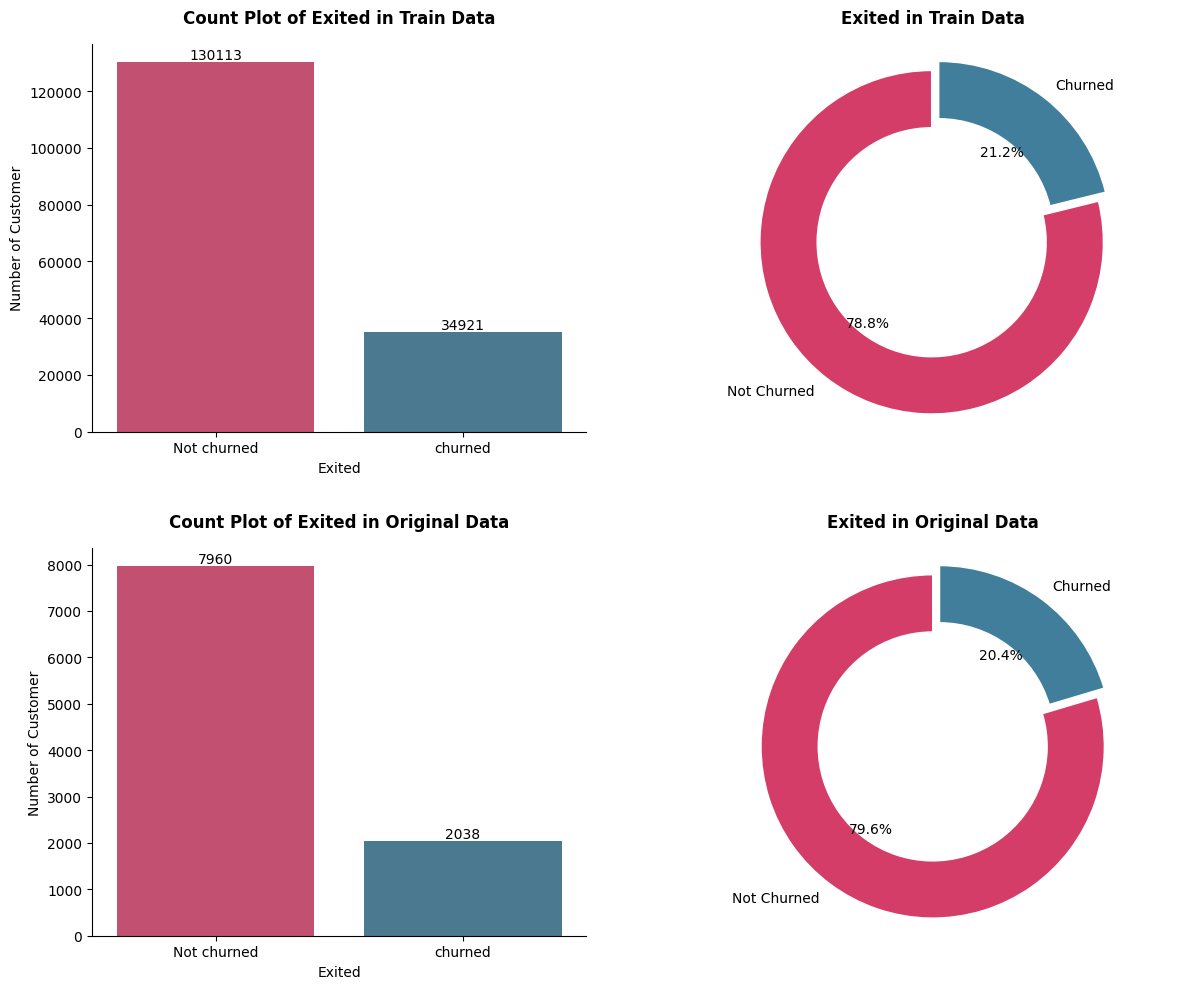

In [169]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
datasets = [("Train Data", df_train), ("Original Data", df_origin)]

for i, (title, data) in enumerate(datasets):
    ax = axes[i, 0]
    sns.countplot(x=Config.target_feature, data=data, ax=ax, palette=color(n_colors=df_train[Config.target_feature].nunique()))
    ax.set_title(f"Count Plot of Exited in {title}", pad=15, weight="bold", fontsize=12)
    ax.set_ylabel("Number of Customer")
    ax.set_xlabel("Exited")
    ax.set_xticks([0, 1], ["Not churned", "churned"])

    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    for container in ax.containers:
        ax.bar_label(container, fmt="%d", label_type="edge", fontsize=10)

    loan_counts = data[Config.target_feature].value_counts().sort_index()
    wedges, texts, autotexts = axes[i, 1].pie(
        loan_counts,
        labels = ["Not Churned", "Churned"],
        autopct="%1.1f%%",
        startangle=90,
        colors=color(n_colors=df_train[Config.target_feature].nunique()),
        wedgeprops=dict(width=0.4, edgecolor="w"),
        radius=1.2,
        explode = (0, 0.08)
    )
    
    for text in texts + autotexts:
        text.set_fontsize(10)
    
    centre_circle = plt.Circle((0, 0), 0.70, fc="white")
    axes[i, 1].add_artist(centre_circle)
    axes[i, 1].set_title(f"Exited in {title}", pad=15, weight="bold", fontsize=12)
    axes[i, 1].axis("equal") 

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

### Class Distribution Insights

**Training Data vs Original Data**

* Both datasets show **very similar churn ratios** — about **20% churn** and **80% non-churn**.
* This means **1 out of every 5 customers** has churned.
* The close alignment in counts and percentages indicates **no significant distribution shift** between datasets.

**Imbalance Characteristics**

* The class imbalance is **moderate** (not extreme).
* However, the majority class dominates, which may cause the model to **overpredict the Non-Churn class** if not addressed.

**Implications**

* Consider imbalance-handling strategies such as:

  * **Class weighting**,
  * **Oversampling (e.g., SMOTE)**,
  * **Under-sampling**,
  * or **threshold tuning**.

**Conclusion**

→ Both datasets maintain **consistent class structure**, but **imbalance mitigation is still necessary** to avoid biased model predictions.

## Numerical Feature Distributions

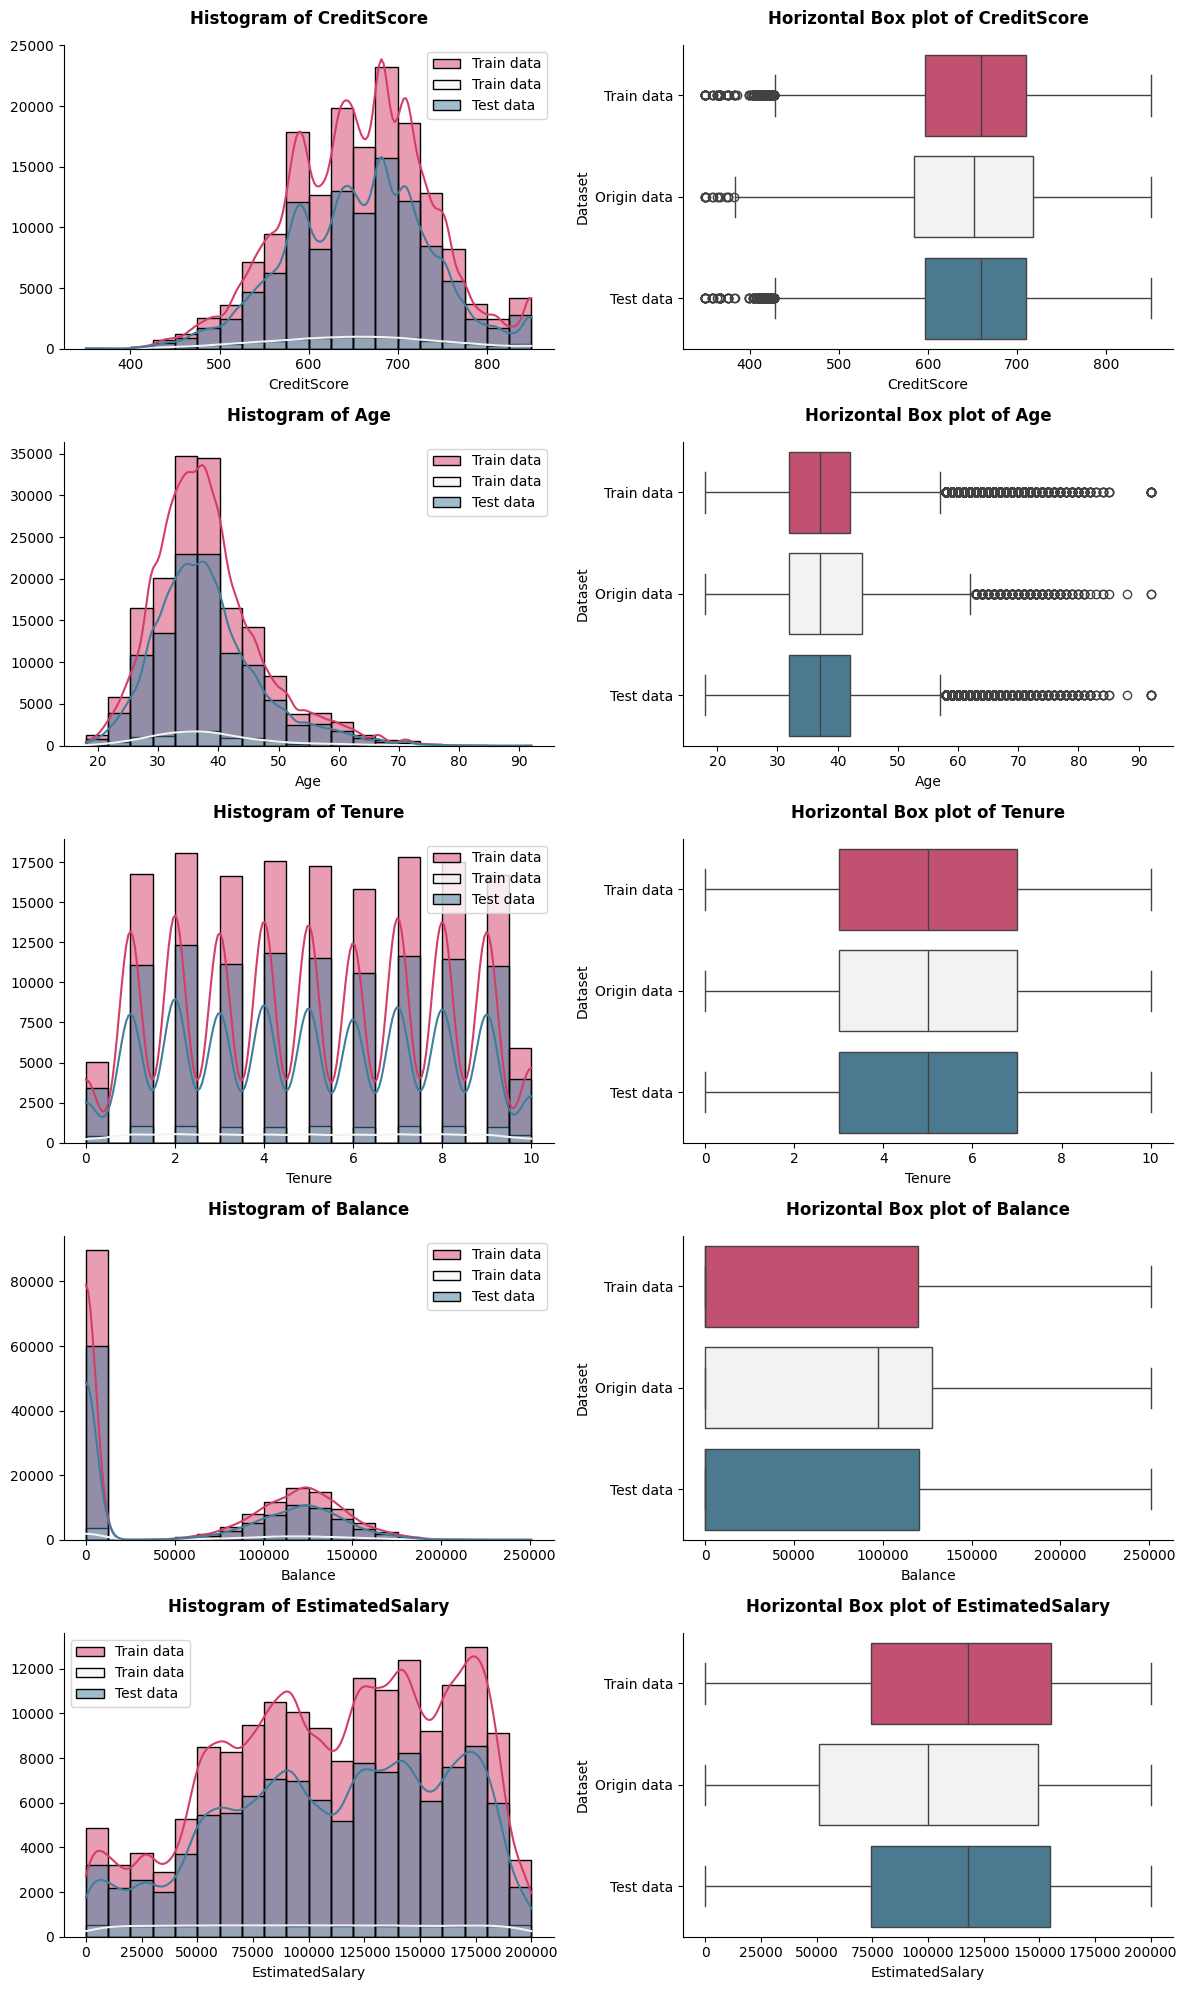

In [170]:
def plot_numerical_features(df_train, df_test, df_origin, num_features):
    colors = color(n_colors=3)
    n = len(num_features)

    fig, ax = plt.subplots(n, 2, figsize=(12, n * 4))
    ax = np.array(ax).reshape(n, 2)

    for i, feature in enumerate(num_features):
        sns.histplot(data=df_train[feature], color=colors[0], bins=20, kde=True, ax=ax[i, 0], label="Train data")
        sns.histplot(data=df_origin[feature], color=colors[1], bins=20, kde=True, ax=ax[i, 0], label="Train data")
        sns.histplot(data=df_test[feature], color=colors[2], bins=20, kde=True, ax=ax[i, 0], label="Test data")
        ax[i, 0].set_title(f"Histogram of {feature}", pad=15, weight="bold", fontsize=12)
        ax[i, 0].legend()
        ax[i, 0].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 0])

        df_plot = pd.concat([
            pd.DataFrame({"Dataset": "Train data", feature: df_train[feature]}),
            pd.DataFrame({"Dataset": "Origin data", feature: df_origin[feature]}),
            pd.DataFrame({"Dataset": "Test data", feature: df_test[feature]})
        ]).reset_index(drop=True)

        sns.boxplot(
            data=df_plot,
            x=feature,
            y="Dataset",
            palette=colors,
            orient="h",
            ax=ax[i, 1]
        )
        ax[i, 1].set_title(f"Horizontal Box plot of {feature}", pad=15, weight="bold", fontsize=12)
        sns.despine(left=False, bottom=False, ax=ax[i, 1])

    plt.tight_layout()
    plt.show()

plot_numerical_features(df_train = df_train, df_test = df_test, df_origin = df_origin, num_features=num_features)

In [171]:
def check_skewness(data, dataset_name, numerical_features = num_features, highlight=True, sort=True):
    skewness_dict = {}
    skew_feature = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)

    print(f"\n[i] Skewness for {dataset_name}...")
    print("-"*70)
    print(f"{'Feature':<30} | {'Skewness':<9} | {'Remark'}")
    print("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = "\033[91m"
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = "\033[93m"
        else:
            remark = "Approximately symmetric"
            color = ""
        endc = "\033[0m" if color else ""
        if highlight and color:
            print(f"{color}{feature:<30} | {skew:>+9.4f} | {remark}{endc}")
            skew_feature.append(feature)
        else:
            print(f"{feature:<30} | {skew:>+9.4f} | {remark}")
    print("-"*70)
    return skew_feature, skew_df

skew_feature_origin, skew_origin_df = check_skewness(df_origin, "Original Data")
skew_feature_train, skew_train_df = check_skewness(df_train, "Train Data")
skew_feature_test, skew_test_df = check_skewness(df_test, "Test Data")


[i] Skewness for Original Data...
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
Age                            |   +1.0118 | Highly skewed
Balance                        |   -0.1410 | Approximately symmetric
CreditScore                    |   -0.0723 | Approximately symmetric
Tenure                         |   +0.0109 | Approximately symmetric
EstimatedSalary                |   +0.0019 | Approximately symmetric
----------------------------------------------------------------------

[i] Skewness for Train Data...
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
Age                            |   +0.9681 | Moderately skewed
Balance                        |   +0.3820 | Approximately symmetric
Estimat

## Insights on Numerical Feature Distributions

* The **train, test, and original datasets show highly similar distributions**, indicating that the data preparation or synthetic generation process preserved the original statistical properties. This reduces the risk of **distribution shift** and supports strong **model generalization**.

* **Most numerical features follow roughly symmetric distributions**, except for `Age`, which is **right-skewed**. `Balance` also shows a notable pattern with many zero values and a secondary peak at high balances, suggesting two distinct customer groups.

* **Skewness:**

  * `Age`: **moderately to highly positively skewed** (~ +1.0).
  * Other features (`CreditScore`, `Tenure`, `Balance`, `EstimatedSalary`) are **approximately symmetric** (|skew| < 0.5).

* **Feature-level observations:**

  * `CreditScore`: near-normal distribution around 650–660.
  * `Tenure`: evenly distributed from 0 to 10 years.
  * `EstimatedSalary`: uniformly distributed.
  * `Balance`: clearly separated into a zero-balance group and a high-balance group (>100k).

* **Conclusion:** The dataset shows strong representativeness across splits; the only feature that may require transformation is **`Age`**, which could benefit from log, Box-Cox, or Yeo-Johnson adjustments to reduce skewness.

## Correlation Analysis of Numerical Features

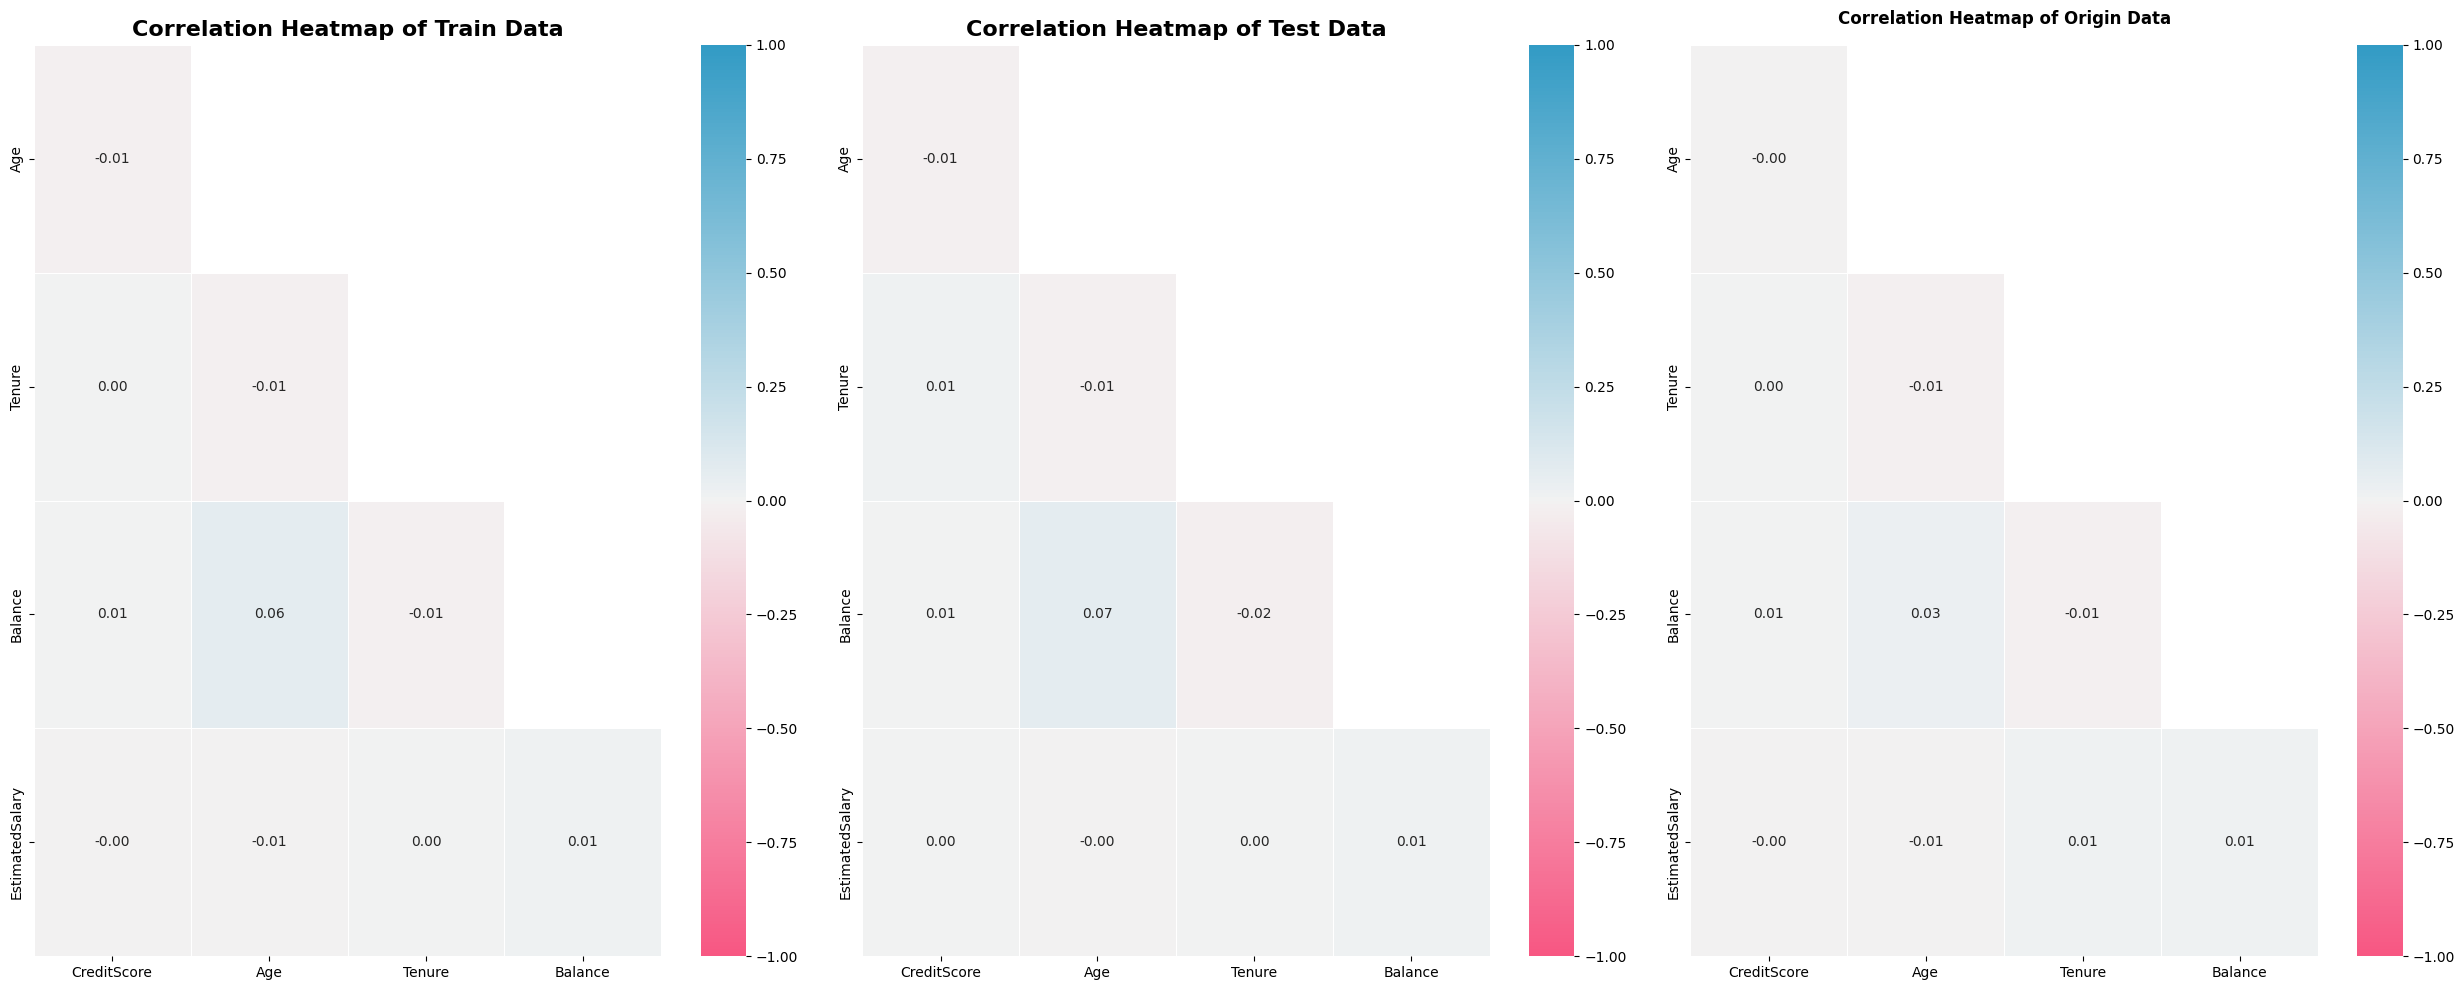

In [172]:
def plot_correlation(df_train, df_origin, df_test, origin_name="Origin Data", train_name="Train Data", test_name="Test Data"):
    corr_train = df_train.corr(numeric_only=True)
    corr_origin = df_origin.corr(numeric_only=True)
    corr_test = df_test.corr(numeric_only=True)

    mask_train = np.triu(np.ones_like(corr_train, dtype=bool))
    adjusted_mask_train = mask_train[1:, :-1]
    adjusted_cereal_corr_train = corr_train.iloc[1:, :-1]

    mask_origin = np.triu(np.ones_like(corr_origin, dtype=bool))
    adjusted_mask_origin = mask_origin[1:, :-1]
    adjusted_cereal_corr_origin = corr_origin.iloc[1:, :-1]

    mask_test = np.triu(np.ones_like(corr_test, dtype=bool))
    adjusted_mask_test = mask_test[1:, :-1]
    adjusted_cereal_corr_test = corr_test.iloc[1:, :-1]

    cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
    fig, ax = plt.subplots(1, 3, figsize=(25, 10))

    sns.heatmap(data=adjusted_cereal_corr_train, mask=adjusted_mask_train,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[0])
    ax[0].set_title(f"Correlation Heatmap of {train_name}", fontsize=16, weight="bold")

    sns.heatmap(data=adjusted_cereal_corr_test, mask=adjusted_mask_test,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[1])
    ax[1].set_title(f"Correlation Heatmap of {test_name}", fontsize=16, weight="bold")

    sns.heatmap(data=adjusted_cereal_corr_origin, mask=adjusted_mask_origin,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[2])
    ax[2].set_title(f"Correlation Heatmap of {origin_name}", fontsize=12, weight="bold", pad=15)

    plt.tight_layout()
    plt.show()

plot_correlation(df_train=df_train.drop(columns="Exited", axis=1),
                 df_origin=df_origin.drop(columns="Exited", axis=1),
                 df_test=df_test)

### Insights from Correlation Analysis of Numerical Features

**Overall Weak Correlations:** Most correlation coefficients are extremely close to zero, indicating very weak or no linear relationship between the numerical features.

**Implications for Modeling**

- The near-zero correlations imply that each numerical feature provides **unique, non-redundant information**.
- Since multicollinearity is not an issue, these features can be safely used together in models like linear regression or tree-based methods.

## Categorical Feature Distributions

In [173]:
def plot_categorical_distribution_across_datasets(
    df_train: pd.DataFrame = df_train,
    df_origin: pd.DataFrame = df_origin,
    df_test: pd.DataFrame = df_test,
    feature="gender"
):
    # --- Summarize categorical feature in training set ---
    train_summary = (
        df_train[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Train_Count")
    )

    # Calculate percentage distribution in training data
    train_summary["Train_%"] = round((train_summary["Train_Count"] / train_summary["Train_Count"].sum() * 100), 2)

    # --- Summarize categorical feature in training set ---
    original_summary = (
        df_origin[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Origin_Count")
    )

    # Calculate percentage distribution in training data
    original_summary["Origin_%"] = round((original_summary["Origin_Count"] / original_summary["Origin_Count"].sum() * 100), 2)

    # --- Summarize categorical feature in test set ---
    test_summary = (
        df_test[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Test_Count")
    )

    # Calculate percentage distribution in test data
    test_summary["Test_%"] = round((test_summary["Test_Count"] / test_summary["Test_Count"].sum() * 100), 2)

    # --- Merge train and test summaries for comparison ---
    summary = pd.merge(train_summary, original_summary, on="Category", how="inner")
    summary = pd.merge(summary, test_summary, on="Category", how="inner")

    # Ensure Category column is of string type before handling missing values
    summary["Category"] = summary["Category"].astype(str)

    # Fill missing values only for numeric columns
    cat_cols = ["Train_Count", "Train_%", "Origin_Count", "Origin_%", "Test_Count", "Test_%"]
    summary[cat_cols] = summary[cat_cols].fillna(0)

    # Convert summary table to HTML for better visualization in notebook
    html = summary.to_html(
        index=False,
        justify="center",
        classes="table table-striped table-hover",
    )

    # Display formatted HTML table with title
    display(HTML(f"[✓] Categorical Feature Distribution: <b>{feature}</b>" + html))
    print("*" * 80)


# ----- Run the function for all categorical features -----
for feature in cat_features:
    plot_categorical_distribution_across_datasets(df_train=df_train, df_origin=df_origin, df_test=df_test, feature=feature)

Category,Train_Count,Train_%,Origin_Count,Origin_%,Test_Count,Test_%
France,94215,57.09,5012,50.13,63171,57.42
Spain,36213,21.94,2476,24.76,23913,21.73
Germany,34606,20.97,2510,25.11,22939,20.85


********************************************************************************


Category,Train_Count,Train_%,Origin_Count,Origin_%,Test_Count,Test_%
Male,93150,56.44,5455,54.56,61942,56.3
Female,71884,43.56,4543,45.44,48081,43.7


********************************************************************************


Category,Train_Count,Train_%,Origin_Count,Origin_%,Test_Count,Test_%
1,124428,75.4,7054,70.55,82852,75.3
0,40606,24.6,2944,29.45,27171,24.7


********************************************************************************


Category,Train_Count,Train_%,Origin_Count,Origin_%,Test_Count,Test_%
0,82885,50.22,4851,48.52,55536,50.48
1,82149,49.78,5147,51.48,54487,49.52


********************************************************************************


Category,Train_Count,Train_%,Origin_Count,Origin_%,Test_Count,Test_%
2,84291,51.07,4589,45.90,56338,51.21
1,77374,46.88,5083,50.84,51567,46.87
3,2894,1.75,266,2.66,1814,1.65
4,475,0.29,60,0.60,304,0.28


********************************************************************************


In [174]:
def top_ratio(df_test = df_test, df_train = df_train, df_origin=df_origin, cat_features = cat_features):
    dataset_names = ["Train", "Test", "Origin"]
    datasets = [df_train, df_origin, df_test]
    for i, (data, name) in enumerate(zip(datasets, dataset_names)):
        print(f"{name} Data")
        flagged = False
        for feature in cat_features:
            freq = data[feature].value_counts(normalize=True)
            top_ratio = freq.iloc[0]
            if top_ratio > 0.99:
                flagged = True
                print(f"[!]  {feature}: {top_ratio:.1%} là '{freq.index[0]}'")
        if not flagged:
            print("[✓] No feature has a category that makes up more than 99% of its values.")
        print("*" * 50)
top_ratio()

Train Data
[✓] No feature has a category that makes up more than 99% of its values.
**************************************************
Test Data
[✓] No feature has a category that makes up more than 99% of its values.
**************************************************
Origin Data
[✓] No feature has a category that makes up more than 99% of its values.
**************************************************


### Insights on Categorical Feature Distributions

**Geography**

* France is overrepresented in Train/Test (~57%) compared to Original (~50%).
* Germany and Spain remain similar across datasets (~21–25%).
  → *Potential bias toward French customer patterns; consider stratification or weighting if regional fairness matters.*

**Gender**

* Male customers consistently account for ~56%, Female ~44% across all datasets.
  → *Slight imbalance but stable; no critical adjustment needed.*

**HasCrCard**

* Credit card holders represent ~75% in Train/Test vs ~70% in Original.
  → *Synthetic data slightly increases cardholder proportion, which may influence prediction patterns.*

**IsActiveMember**

* Balanced distribution (~50% Active / 50% Inactive) across all datasets.
  → *No concern regarding representativeness.*

**NumOfProducts**

* Majority use 1–2 products (~47–51% each), while 3–4 products are rare (<2%).
  → *Sparse upper categories may limit model learning; consider grouping “3+ products”.*

**Overall Summary**

* **Stable across datasets:** Gender, IsActiveMember.
* **Slight distribution shifts:** Geography (more France), HasCrCard (more cardholders).
* **Highly imbalanced category:** NumOfProducts (rare high-product counts).
* **Modeling considerations:**

  * Watch for bias from Geography and HasCrCard differences.
  * Combine rare product categories to improve model robustness.

## Bivariate Analysis

In [175]:
df_train_combined = pd.concat([df_train, df_origin], axis=0, ignore_index=True)
# Re-check duplicate

datasets = {
    "Training Data": df_train_combined,
    "Test Data": df_test
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }
    print()

[i] Training Data Duplicate Analysis...
[!] 571 duplicate rows detected (0.33%).
[!] Rows affected: 571 out of 175,032.

[i] Test Data Duplicate Analysis...
[!] 72 duplicate rows detected (0.07%).
[!] Rows affected: 72 out of 110,023.



,Exited,Count,Mean,Median,Std
0,0,138073,657.259146,662.000000,80.794112
1,1,36959,651.845126,651.000000,82.324839



[i] Checking normality of feature 'CreditScore' by groups of 'Exited'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


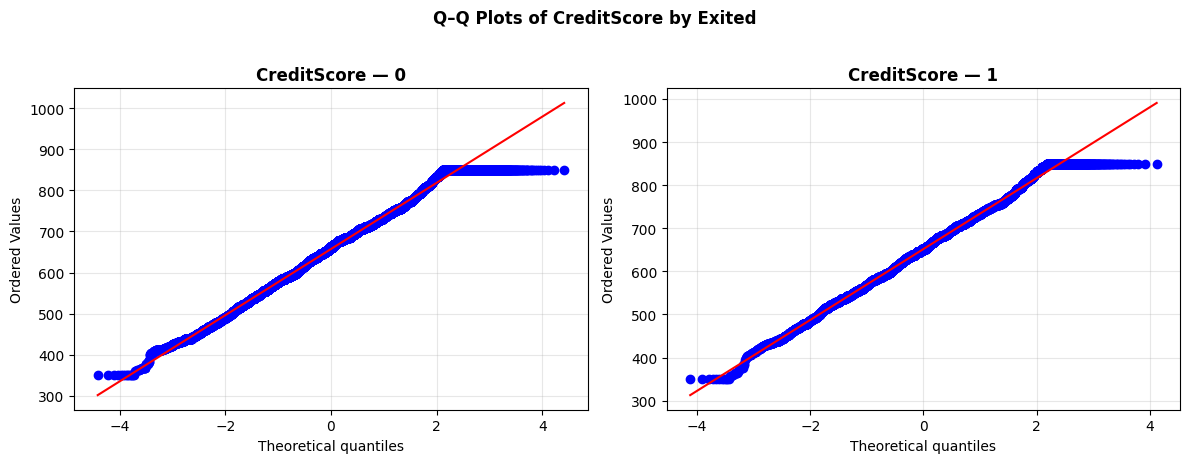

,Feature,Group,Skewness,Kurtosis,Remark
0,CreditScore,0,-0.0762,-0.0615,"Approximately symmetric, Normal tails"
1,CreditScore,1,-0.0243,-0.1199,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,25.1144
1,p-value,0.000001
2,Max/Min Variance Ratio,1.04



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'CreditScore' ~ 'Exited'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: '0' vs '1'
[i] t-statistic: 11.273
[i] p-value: 0.000000
[i] Cohen's d: 0.066
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.066)


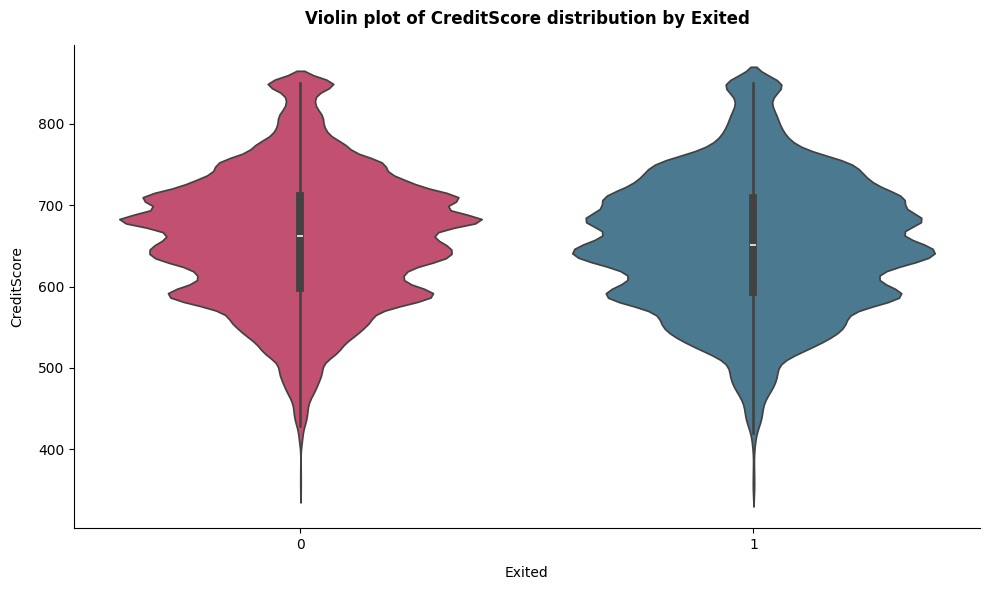

,Exited,Count,Mean,Median,Std
0,1,36959,44.006900,44.000000,9.049732
1,0,138073,36.609185,36.000000,8.277114



[i] Checking normality of feature 'Age' by groups of 'Exited'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


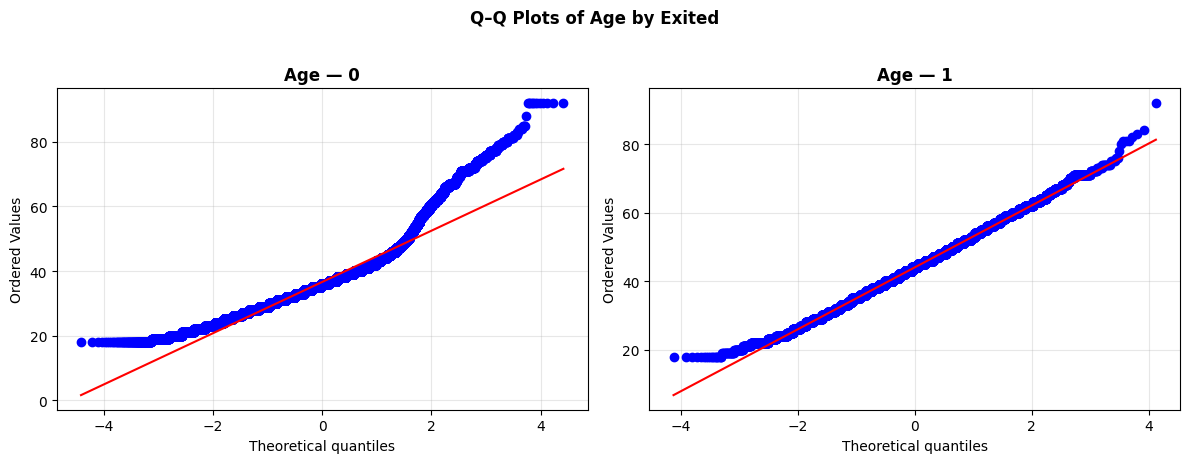

,Feature,Group,Skewness,Kurtosis,Remark
0,Age,0,1.3432,3.5124,"Highly skewed, Heavy/light tails"
1,Age,1,0.1136,-0.0238,"Approximately symmetric, Normal tails"


[!] At least one group deviates from normality.
[i] Non-normal distribution detected → Consider Kruskal–Wallis or Mann–Whitney U test.

[i] Running Mann–Whitney U Test: 'Age' by 'Exited'...
[i] U statistic: 1279119411.0
[i] p-value    : 0.000000

[✓] Significant difference detected between the two groups (Reject H0).
[i] Median of group '0': 36.0000
[i] Median of group '1': 44.0000
[i] Interpretation: Group '1' has a higher median 'Age'.


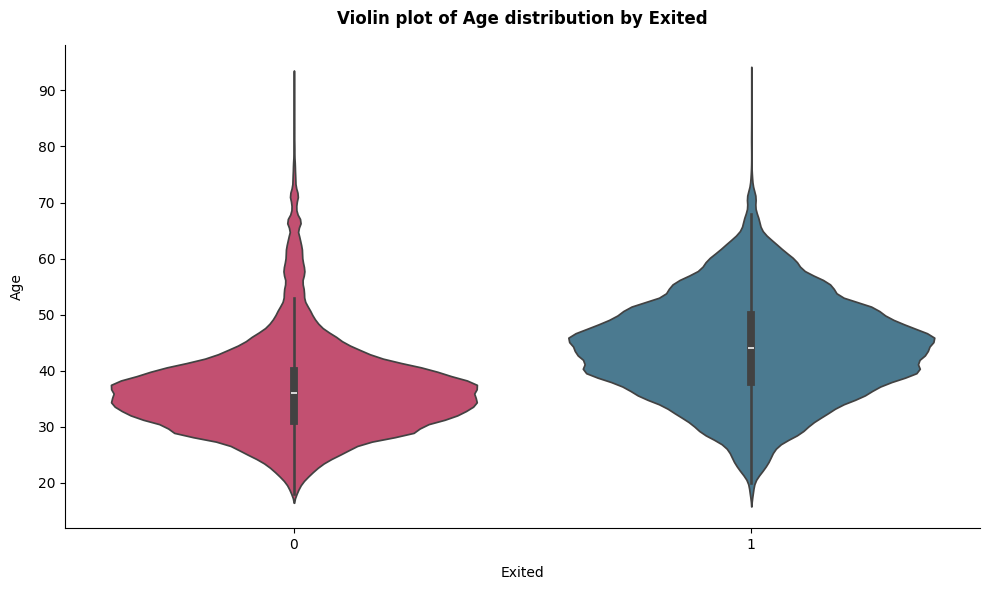

,Exited,Count,Mean,Median,Std
0,0,138073,5.047931,5.000000,2.804694
1,1,36959,4.915339,5.000000,2.832653



[i] Checking normality of feature 'Tenure' by groups of 'Exited'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


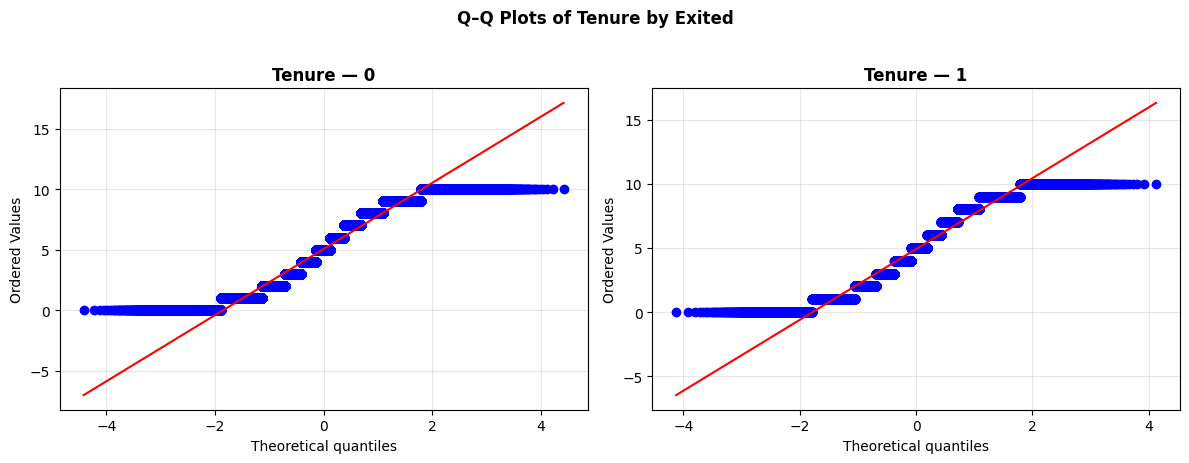

,Feature,Group,Skewness,Kurtosis,Remark
0,Tenure,0,-0.0074,-1.1617,"Approximately symmetric, Normal tails"
1,Tenure,1,0.0601,-1.1392,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,2.3654
1,p-value,0.124053
2,Max/Min Variance Ratio,1.02



[i] Interpretation:
   [✓] Variances are statistically and practically homogeneous.
   Recommendation → Use One-Way ANOVA or Independent Two-Sample T-Test.

[i] Running Independent Two-Sample T-Test: 'Tenure' ~ 'Exited'
[i] Test Type: Student’s T-Test (equal variances)

[i] Comparing groups: '0' vs '1'
[i] t-statistic: 8.055
[i] p-value: 0.000000
[i] Cohen's d: 0.047
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.047)


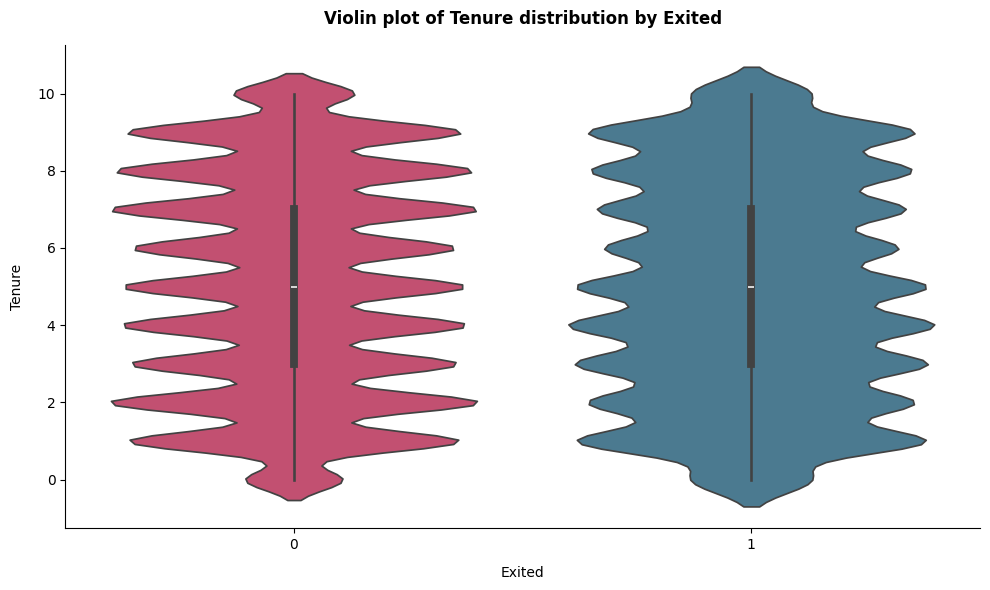

,Exited,Count,Mean,Median,Std
0,1,36959,72306.796875,100254.757812,62581.512539
1,0,138073,52494.300781,0.000000,62428.917930



[i] Checking normality of feature 'Balance' by groups of 'Exited'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


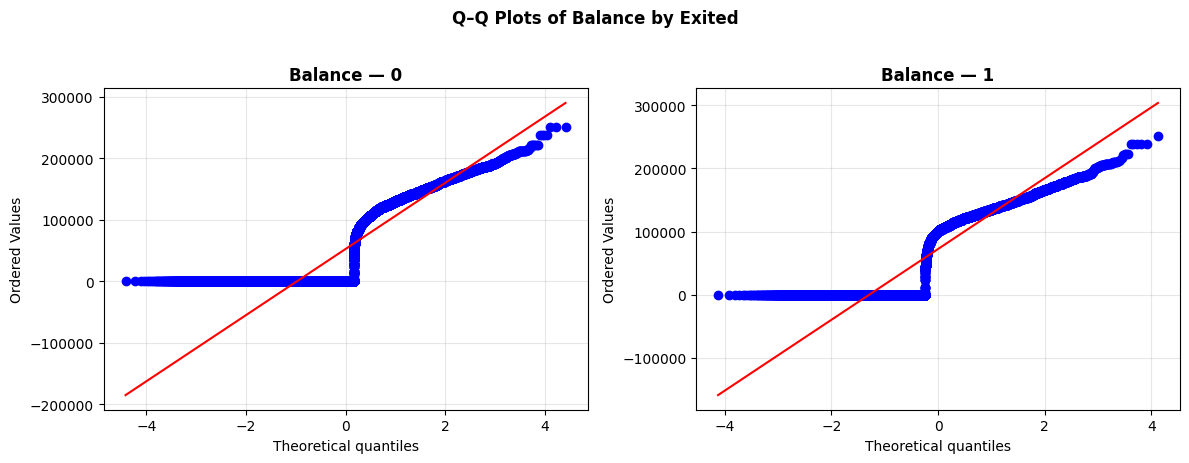

,Feature,Group,Skewness,Kurtosis,Remark
0,Balance,0,0.4852,-1.5040,"Approximately symmetric, Heavy/light tails"
1,Balance,1,-0.1250,-1.6658,"Approximately symmetric, Heavy/light tails"


[!] At least one group deviates from normality.
[i] Non-normal distribution detected → Consider Kruskal–Wallis or Mann–Whitney U test.

[i] Running Mann–Whitney U Test: 'Balance' by 'Exited'...
[i] U statistic: 2136005393.5
[i] p-value    : 0.000000

[✓] Significant difference detected between the two groups (Reject H0).
[i] Median of group '0': 0.0000
[i] Median of group '1': 100254.7578
[i] Interpretation: Group '1' has a higher median 'Balance'.


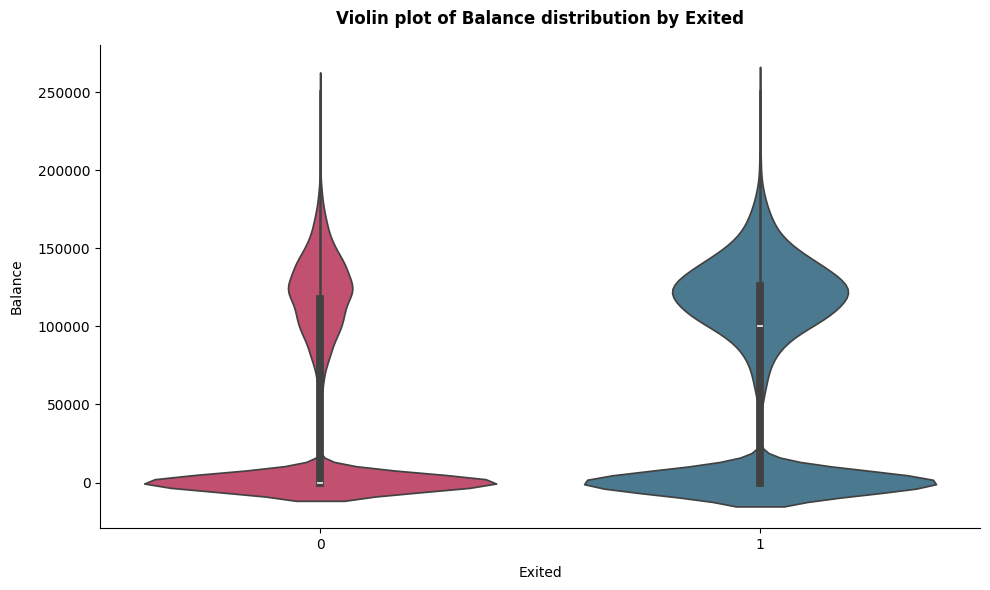

,Exited,Count,Mean,Median,Std
0,1,36959,113688.898438,120380.117188,51059.986619
1,0,138073,111373.273438,116253.101562,50738.490357



[i] Checking normality of feature 'EstimatedSalary' by groups of 'Exited'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


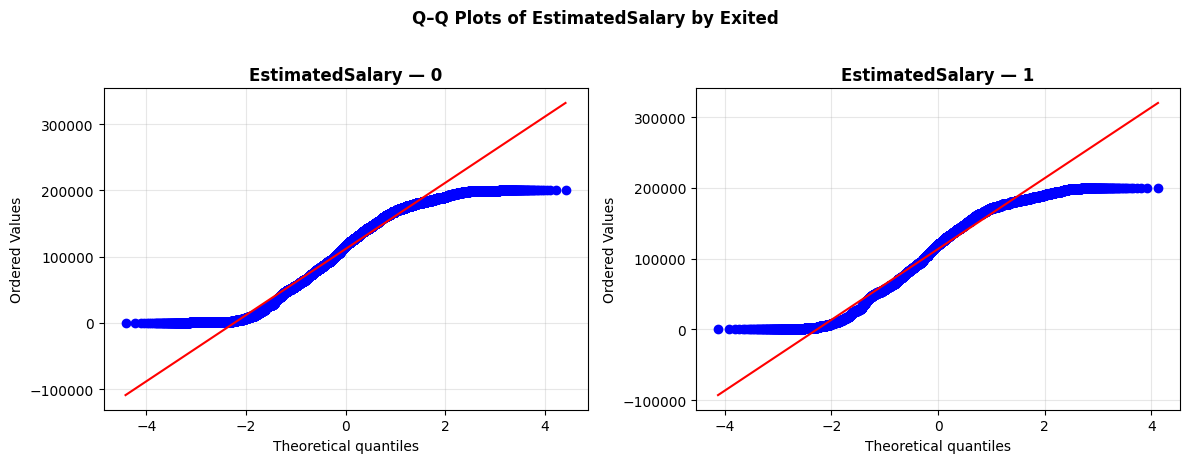

,Feature,Group,Skewness,Kurtosis,Remark
0,EstimatedSalary,0,-0.2842,-0.8624,"Approximately symmetric, Normal tails"
1,EstimatedSalary,1,-0.3366,-0.8724,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,6.4825
1,p-value,0.010895
2,Max/Min Variance Ratio,1.01



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'EstimatedSalary' ~ 'Exited'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: '0' vs '1'
[i] t-statistic: -7.754
[i] p-value: 0.000000
[i] Cohen's d: -0.045
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.045)


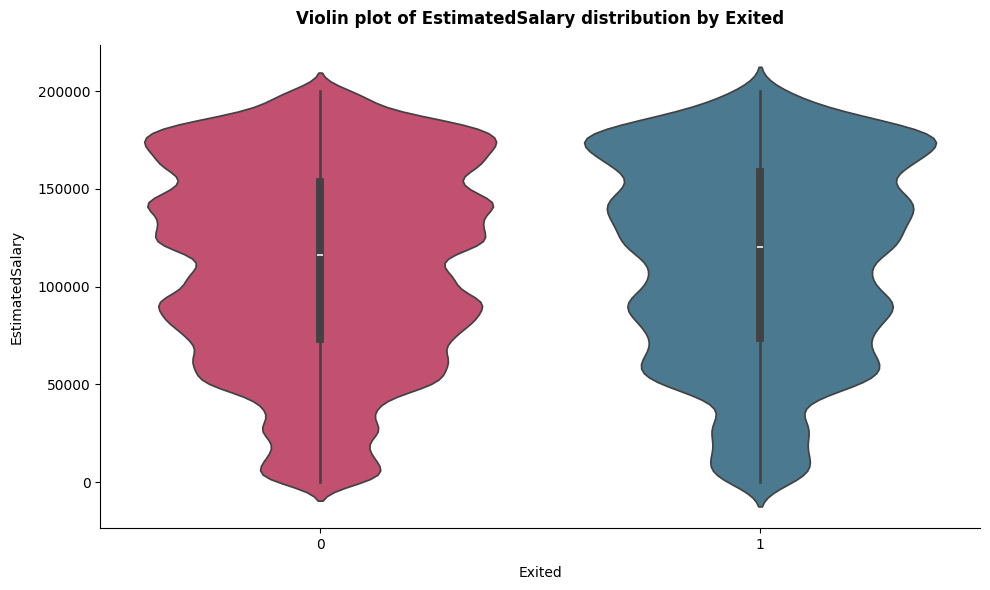

In [176]:
def perform_statical_testing(feature: str, df: pd.DataFrame = df_train_combined,  target_feature: str = Config.target_feature) -> None:
    """
    Perform statistical tests (normality and Kruskal-Wallis) 
    to evaluate whether there are significant differences 
    in the distribution of a numerical feature across categories 
    of the target variable.

    Args:
        feature (str): Name of the numerical feature to be tested.
        df (pd.DataFrame): Dataset containing both numerical and target columns.
        target_feature (str): Name of the target categorical feature.

    Returns:
        None: Prints or displays statistical test results.
    """
    # Perform normality test (e.g., Shapiro-Wilk or D’Agostino test) for feature distribution
    non_normal_detected = check_normality_with_plots(df=df, feature=feature, target_feature=target_feature)
    total_categories = df[target_feature].nunique()
    if total_categories > 2:
        if non_normal_detected == True:
            perform_kruskal_test(df=df, categorical_feature=target_feature,
                                numeric_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                perform_anova_with_tukey(df=df, numeric_feature=feature,
                                        categorical_feature=target_feature)
            elif anove_use and is_homogeneous_variances == False:
                perform_welch_anova(df=df, numeric_feature=feature, categorical_feature=target_feature)
            else:
                perform_kruskal_test(df=df, categorical_feature=target_feature,
                        numeric_feature=feature)
    else:
        if non_normal_detected == True:
            cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=True)
            elif anove_use and is_homogeneous_variances == False:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=False)
            else:
                cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def plot_numerical_distribution(feature: str, df: pd.DataFrame = df_train_combined,
                                target_feature: str = Config.target_feature, order: list = None) -> None:
    """
    Perform statistical testing and visualize the distribution of a numerical feature 
    across different classes of the target variable using violin plots and summary statistics.

    The function executes:
      1. Statistical tests.
      2. Summary table with mean, median, std per category.
      3. Violin plot for visualizing feature distributions across classes.

    Args:
        feature (str): The name of the numerical feature to analyze.
        df (pd.DataFrame): Input dataframe containing numerical & target features.
        target_feature (str): Target variable name (categorical feature).
        order (list, optional): Custom ordering for category display in the plot.

    Returns:
        None: Displays statistical summaries and plots directly.
    """

    # Compute summary statistics for each Fertilizer category
    df_summary_feature = (
        df.groupby(by=target_feature, as_index=False)
        .agg(
            Count=(feature, "count"),
            Mean=(feature, "mean"),
            Median=(feature, "median"),
            Std=(feature, "std")
        )
        .sort_values(by="Mean", ascending=False).reset_index(drop=True)
    )

    # Compute global statistics for the entire feature
    summary_data = [
        ("Overall Mean", f"{df[feature].mean():.2f}"),
        ("Overall Median", f"{df[feature].median()}"),
        ("Overall Std", f"{df[feature].std():.2f}")
    ]

    # Display overall statistics in HTML format for better notebook visualization
    summary_html = "<ul>" + "".join([
        f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data
    ]) + "</ul>"
    display(HTML(summary_html))

    # Display detailed summary per category as styled dataframe
    display(
        df_summary_feature.style.background_gradient(cmap=cm)
        .set_table_attributes('style="width:75%; margin:auto;"')
    )

    # Run statistical significance testing
    perform_statical_testing(feature=feature, target_feature=target_feature)

    # Visualize distribution via violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature, order=order,
                   palette=color(n_colors=df[target_feature].nunique()))
    
    plt.title(f"Violin plot of {feature} distribution by {target_feature}", pad=15, weight="bold", fontsize=12)
    plt.xlabel(f"{Config.target_feature}", labelpad=10)
    plt.ylabel(feature, labelpad=10)
    plt.legend().remove()
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {feature} by {Config.target_feature}</b></h2>"))
    plot_numerical_distribution(feature=feature, df = df_train_combined)

### Insight Numerical Features by Exited

**CreditScore**

* Churned customers have slightly lower credit scores (651 vs. 662).
  → *CreditScore has some influence but the effect size is small.*

**Age**

* Churned customers are noticeably older (median 44 vs. 36).
  → *Age is one of the strongest predictors of churn.*

**Tenure**

* Both groups share the same median tenure (5 years), but their distributions differ significantly.
  → *Tenure shows some influence, though it is not a strong standalone predictor.*

**Balance**

* Churned customers have much higher account balances (100,253 vs. 0).
  → *Balance is a strong predictor, with high-balance customers more likely to churn.*

**EstimatedSalary**

* Churned customers have slightly higher estimated salaries (120,378 vs. 116,267).
  → *Statistically significant but the practical impact is weak.*

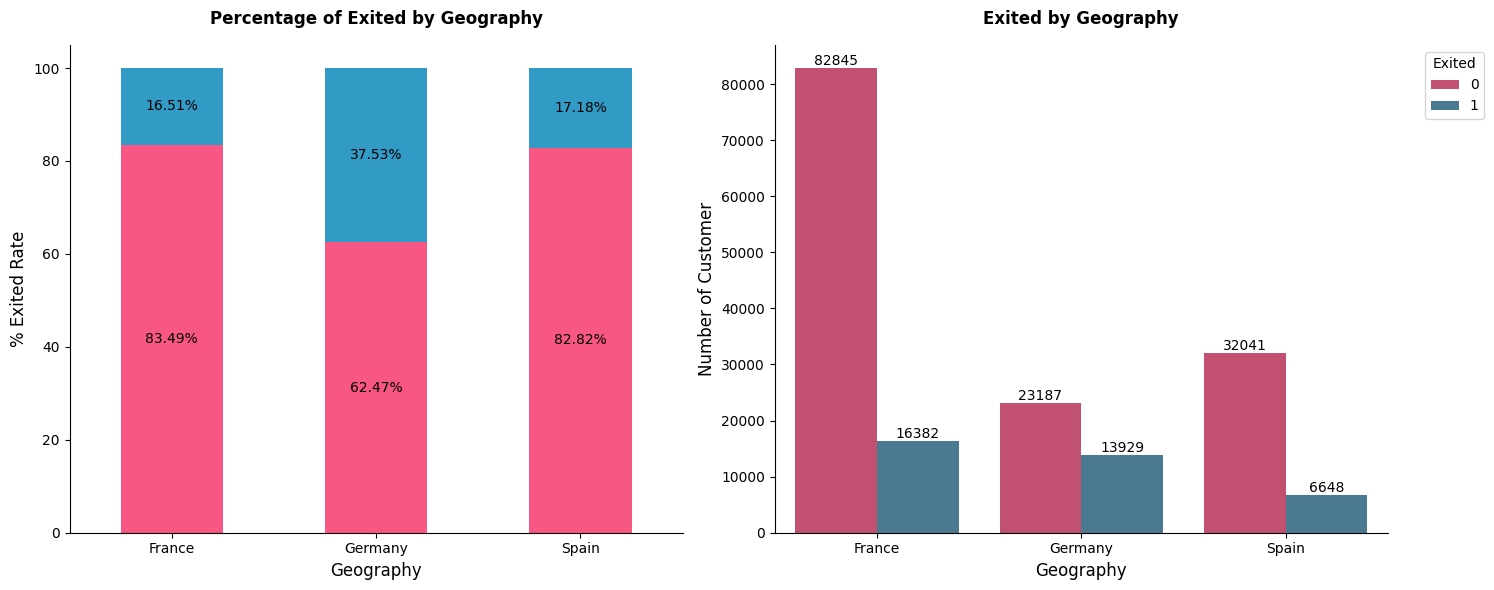


[i] Chi-Square Test of Independence: 'Geography' vs. 'Exited'...
[i] Chi-squared statistic: 7625.409
[i] Degrees of freedom: 2
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'Geography' and 'Exited' are statistically associated.

[i] Standardized Residuals:
Exited         0      1
Geography              
France     16.34 -31.57
Germany   -35.60  68.81
Spain       8.71 -16.83


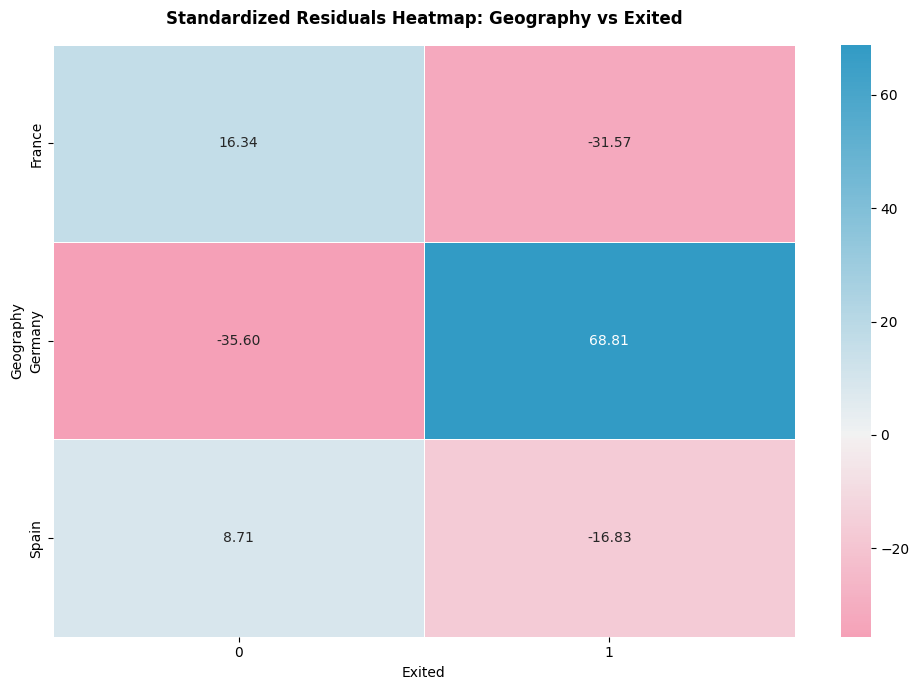

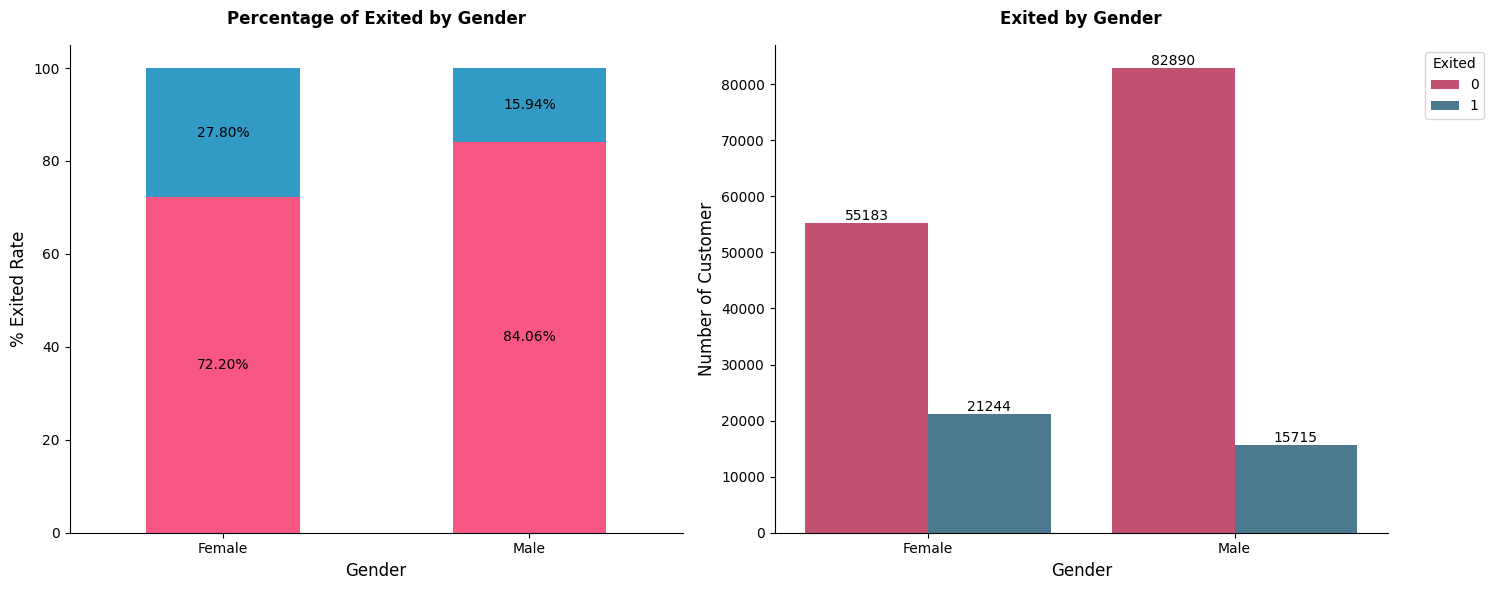


[i] Chi-Square Test of Independence: 'Gender' vs. 'Exited'...
[i] Chi-squared statistic: 3634.587
[i] Degrees of freedom: 1
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'Gender' and 'Exited' are statistically associated.

[i] Standardized Residuals:
Exited      0      1
Gender              
Female -20.80  40.19
Male    18.31 -35.39


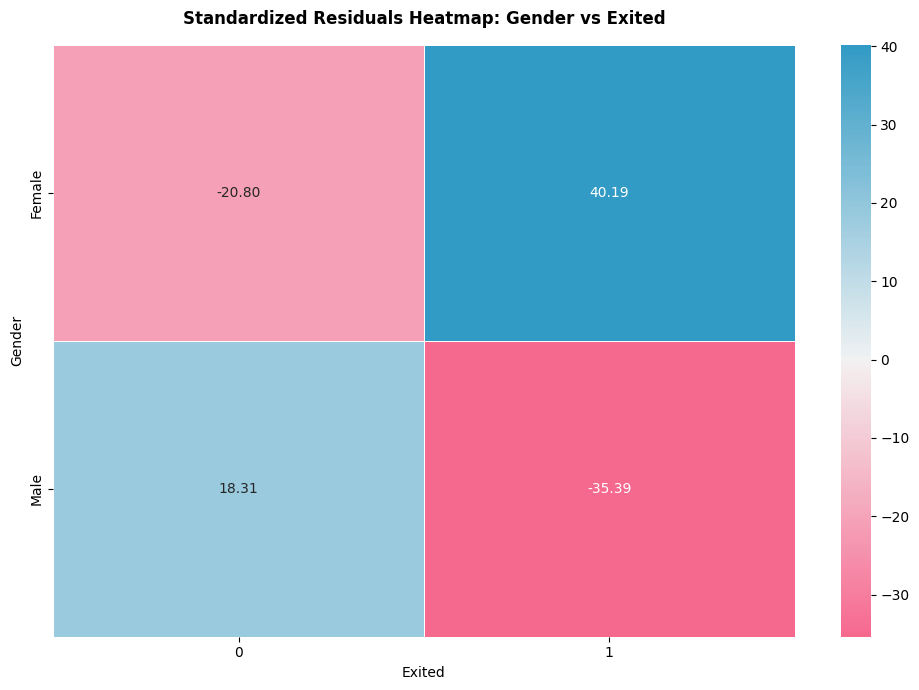

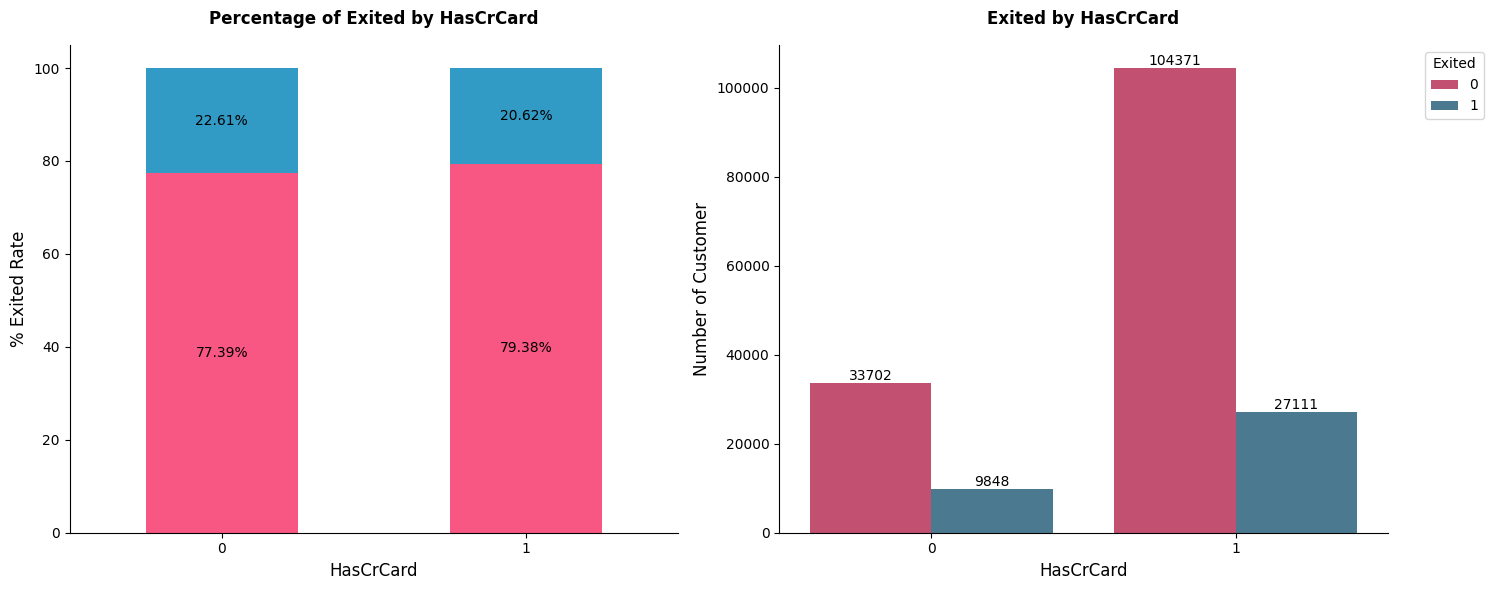


[i] Chi-Square Test of Independence: 'HasCrCard' vs. 'Exited'...
[i] Chi-squared statistic: 77.934
[i] Degrees of freedom: 1
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'HasCrCard' and 'Exited' are statistically associated.

[i] Standardized Residuals:
Exited        0     1
HasCrCard            
0         -3.52  6.80
1          2.03 -3.91


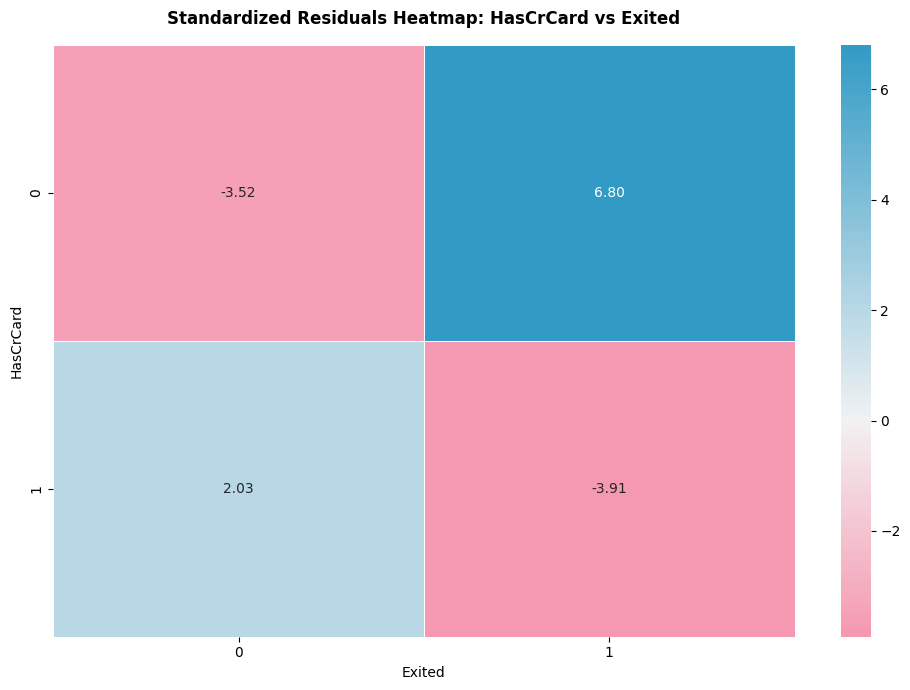

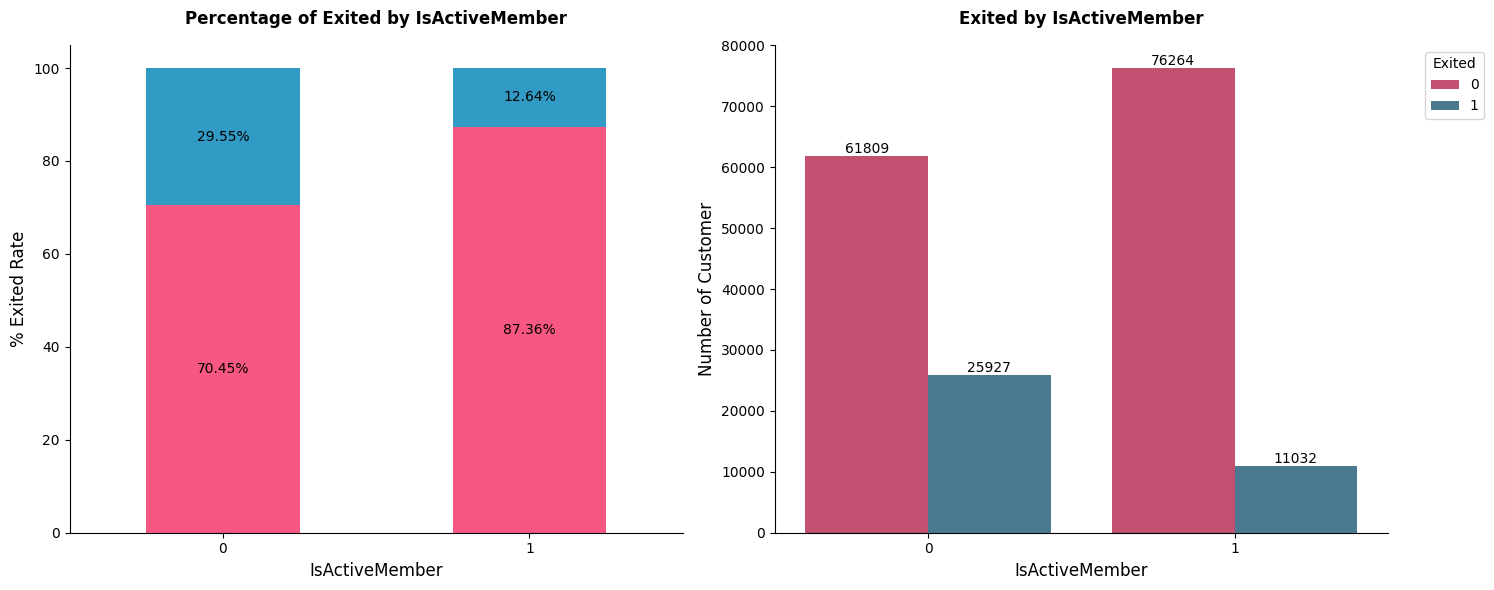


[i] Chi-Square Test of Independence: 'IsActiveMember' vs. 'Exited'...
[i] Chi-squared statistic: 7514.130
[i] Degrees of freedom: 1
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'IsActiveMember' and 'Exited' are statistically associated.

[i] Standardized Residuals:
Exited              0      1
IsActiveMember              
0              -28.13  54.38
1               28.20 -54.51


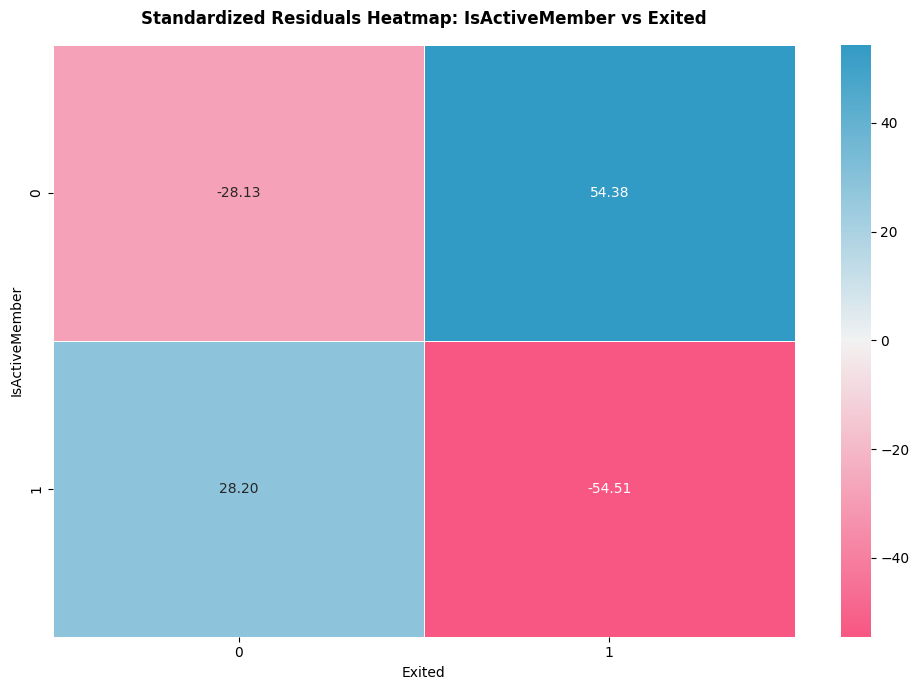

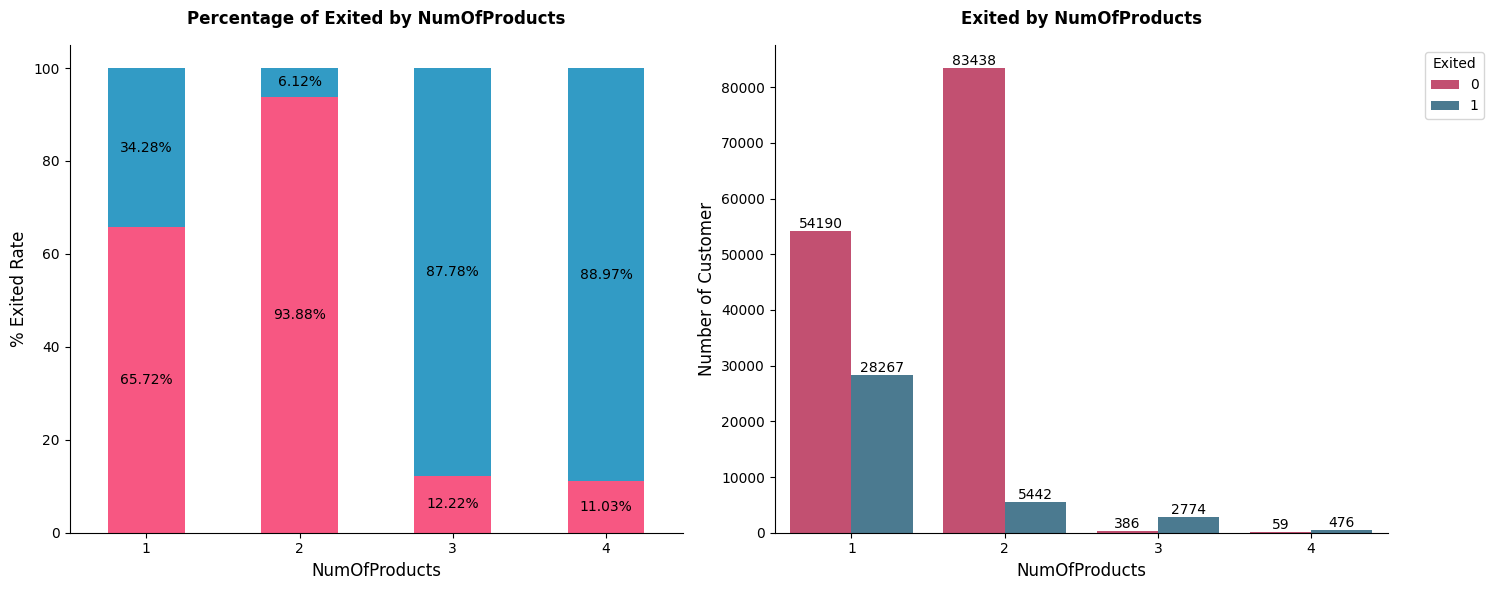


[i] Chi-Square Test of Independence: 'NumOfProducts' vs. 'Exited'...
[i] Chi-squared statistic: 30485.526
[i] Degrees of freedom: 3
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'NumOfProducts' and 'Exited' are statistically associated.

[i] Standardized Residuals:
Exited             0      1
NumOfProducts              
1             -42.56  82.27
2              50.33 -97.27
3             -42.20  81.56
4             -17.67  34.16


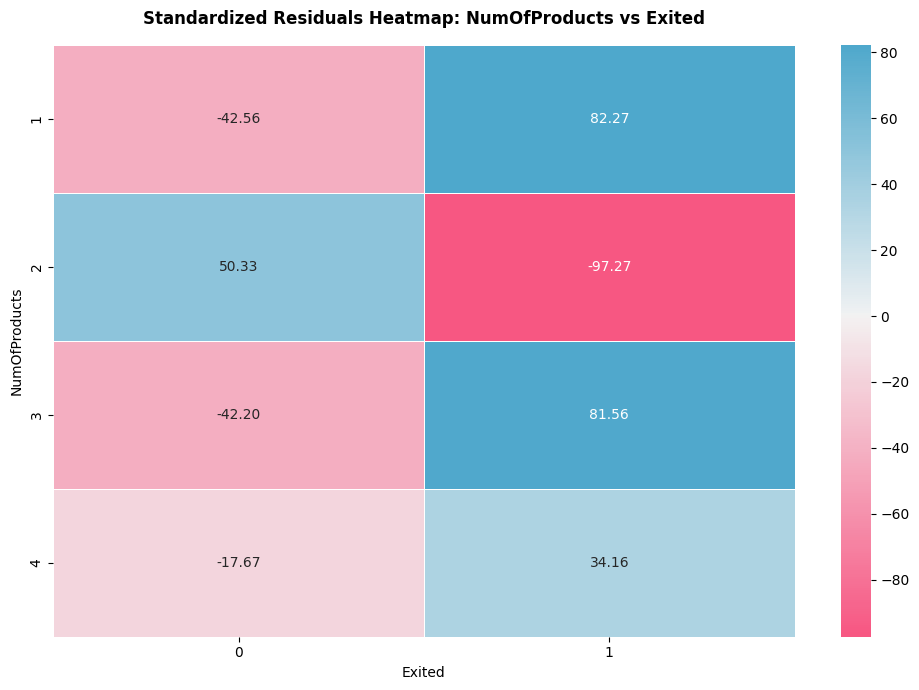

In [177]:
# defining function for plotting
def bivariate_percent_plot(cat, df, figsize=(15, 6), order = None, rot = 0):
    
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {cat} by {Config.target_feature}</b></h2>"))
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=figsize)
    # Plot 1
    # Calculate the total number of each "cat" by Exited
    grouped = df.groupby([cat, Config.target_feature]).size().unstack(fill_value=0)
    # Calculate the percentages
    percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100
    if order is not None:
        percentages = percentages.loc[order]
    
    # That method uses HUSL colors, so you need hue, saturation, and lightness. 
    # I used hsluv.org to select the colors of this chart.
    cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
    # Draw stacked bar plot
    ax[0] = percentages.plot(kind="bar", stacked=True, cmap=cmap, ax = ax[0], use_index=True)
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt='%1.2f%%', label_type="center", fontsize=10)

    ax[0].set_title(f"Percentage of {Config.target_feature} by {cat}", fontsize=12, weight="bold", pad=15)
    ax[0].set_xlabel(f"{cat}", fontsize=12)
    ax[0].set_ylabel(f"% {Config.target_feature} Rate", fontsize=12)
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=rot)
    ax[0].legend_.remove()
    sns.despine(left=False, bottom=False, ax=ax[0])

    # Plot 2
    sns.countplot(data=df, hue = Config.target_feature, x = cat,
                palette=color(n_colors=2), ax=ax[1], order=percentages.index, hue_order = [0, 1])
    # Show value for each bar.
    for container in ax[1].containers:
        ax[1].bar_label(container, fmt='%d', label_type="edge", fontsize=10)

    ax[1].set_title(f"{Config.target_feature} by {cat}", fontsize=12, weight="bold", pad=15)
    ax[1].set_xlabel(f"{cat}", fontsize=12)
    ax[1].set_ylabel("Number of Customer", fontsize=12)
    ax[1].legend(title=f"{Config.target_feature}", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=rot)
    sns.despine(left=False, bottom=False, ax=ax[1])
    plt.tight_layout()
    plt.show()

    cal_ChiSquare(cat_feature=cat, target_feature=Config.target_feature, df=df, show_residuals=True)

for feature in cat_features:
    bivariate_percent_plot(cat=feature, df= df_train_combined)


### Insight for Categorical Features by Attrition

**Geography**

* Shows a very strong relationship with churn.
* Customers from **Germany churn significantly more**, while those from **France and Spain** tend to stay.
  → *Geography is one of the most influential categorical variables.*

**Gender**

* Gender affects churn behavior.
* **Female customers churn more than males**.
  → *Targeted retention strategies by gender may be beneficial.*

**HasCrCard**

* The churn difference is small but **statistically significant**.
* Customers **without a credit card churn more than expected**.
  → *Credit card ownership has a clear association with churn.*

**IsActiveMember**

* Strongly related to churn.
* **Inactive customers churn more**, while active customers are more likely to stay.
  → *A key behavioral variable in churn prediction.*

**NumOfProducts**

* Shows a very strong and significant relationship with churn.
* Customers using **1, 3, or 4 products** exhibit higher-than-expected churn.
  → *NumOfProducts is a critical factor for churn modeling.*

### Overall Picture


| **Feature**         | **Summary**                                                                                    |
| ------------------- | ---------------------------------------------------------------------------------------------- |
| **Geography**       | Customers from **Germany** are more likely to churn; **France** and **Spain** are less likely. |
| **Gender**          | **Female** customers have a higher churn rate than males.                                      |
| **HasCrCard**       | Customers **without a credit card** churn more; those **with** a card churn less.              |
| **IsActiveMember**  | **Inactive** customers are more likely to churn.                                               |
| **NumOfProducts**   | Customers with **1, 3, or 4 products** show higher-than-expected churn.                        |
| **CreditScore**     | Non-churned customers have slightly **higher median credit scores** (653 vs. 646).             |
| **Age**             | Churned customers tend to be **older** (median 45 vs. 36).                                     |
| **Balance**         | Churned customers have a **higher median balance** (109,344 vs. 92,063).                       |
| **Tenure**          | Tenure distributions differ significantly between churned and non-churned customers.           |
| **EstimatedSalary** | Churned customers have a **higher median estimated salary**.                                   |

## Business Questions

In [178]:
df_customer_churnma = df_train_combined.copy()

###  Why is the churn rate higher among customers in Germany?

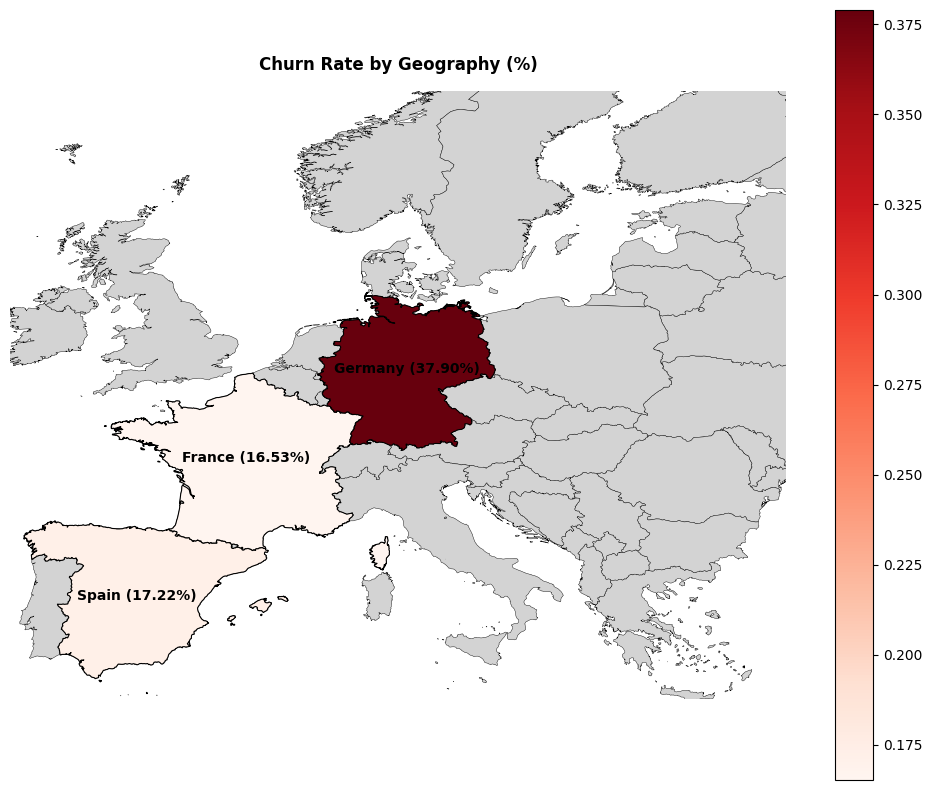

In [179]:
def geography_distribution(df=df_train):
    import geopandas as gpd
    # 1. Calculate churn rate by Geography: mean() = % of customers who exited
    churn_rate_by_geo = df.groupby("Geography")["Exited"].mean()

    # 2. Load geojson file (country names must match the "admin" column)
    world = gpd.read_file("https://raw.githubusercontent.com/daominhthuan42/kaggle-portfolio/refs/heads/main/14-bank-churn-customer/custom.geo.json")

    # 3. Map churn rate to each country
    world["churn_rate"] = world["admin"].map(churn_rate_by_geo)

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 8))

    # Draw base map (entire Europe in grey)
    world.plot(ax=ax, color="#D3D3D3", edgecolor="black", linewidth=0.3)

    # Highlight countries that have churn data
    highlighted = world[world["churn_rate"].notnull()]
    highlighted.plot(ax=ax, column="churn_rate", cmap="Reds", edgecolor="black", linewidth=0.8, legend=True)

    # Annotate country names and churn rates
    for idx, row in highlighted.iterrows():
        point = row["geometry"].representative_point()
        plt.annotate(
            text=f"{row['admin']} ({row['churn_rate'] * 100:.2f}%)",
            xy=(point.x, point.y),
            ha="center",
            fontsize=10,
            color="black",
            weight="bold"
        )

    ax.set_xlim(-10, 30)
    ax.set_ylim(35, 65)
    ax.axis("off")
    ax.set_title("Churn Rate by Geography (%)", fontsize=12, pad=15, weight="bold")

    plt.tight_layout()
    plt.show()

geography_distribution()

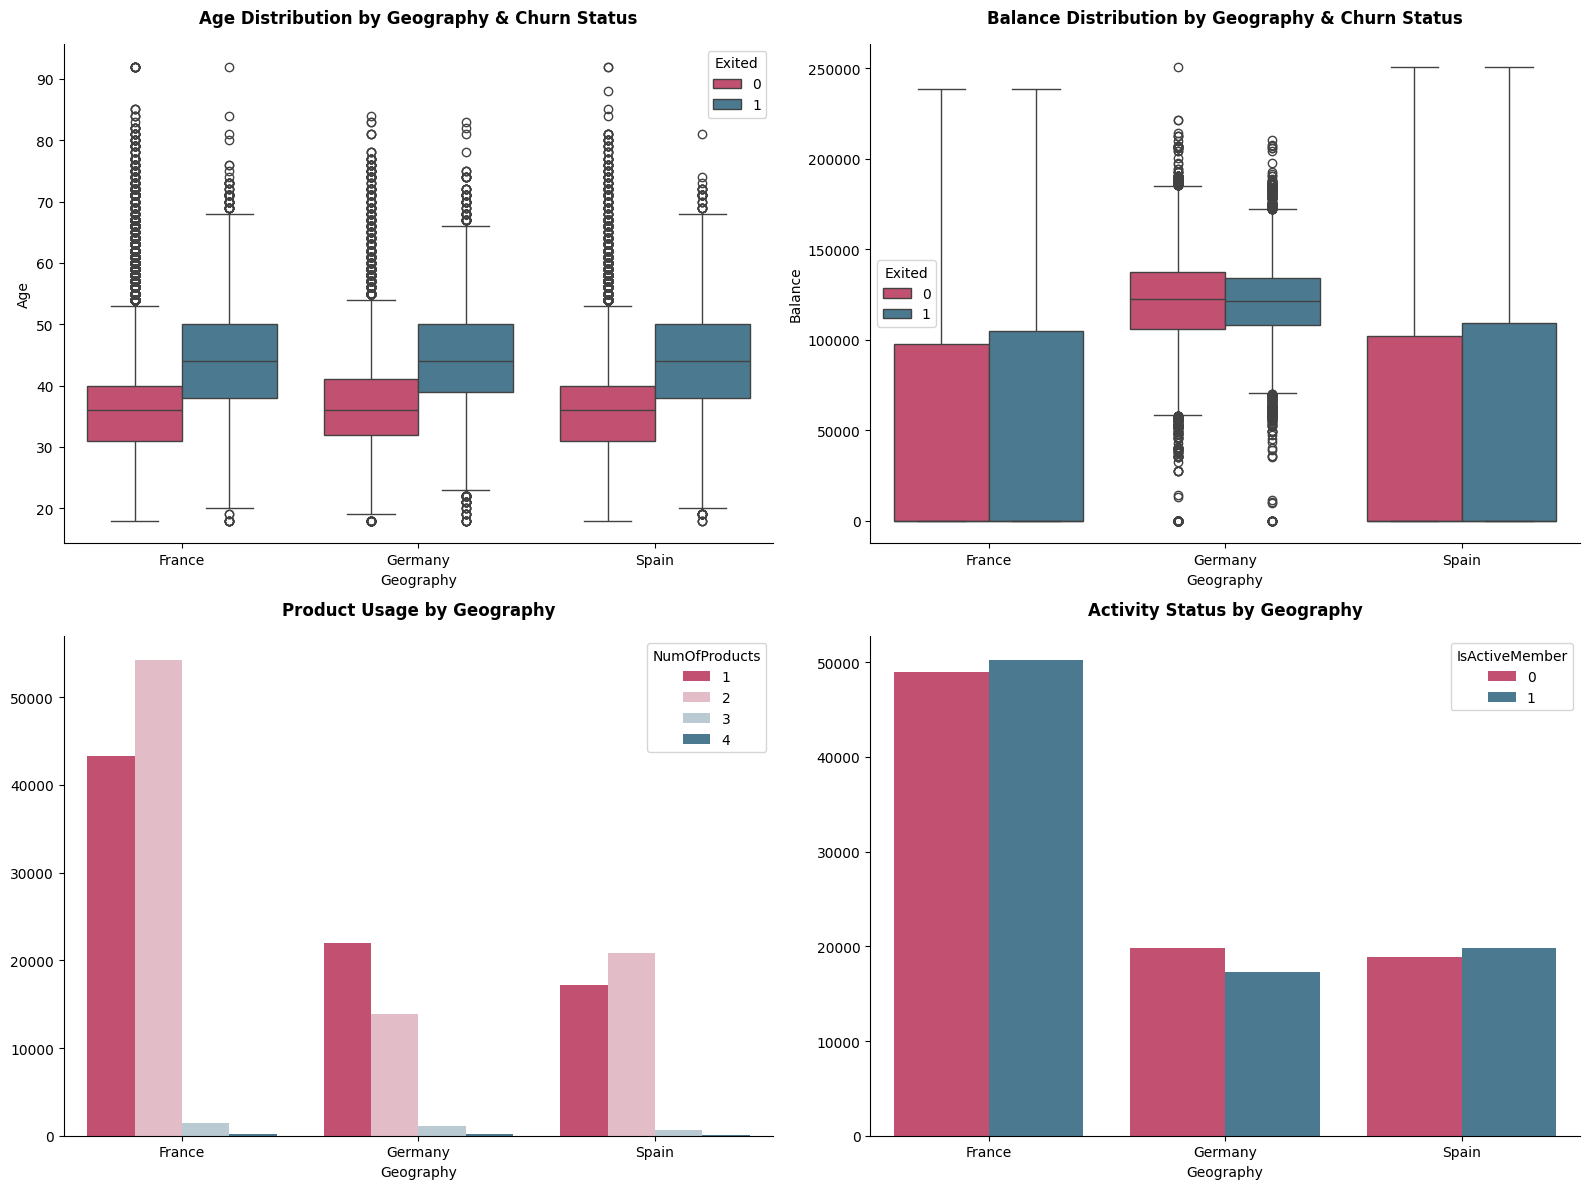

In [180]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# A. Age Distribution by Geography & Churn Status
sns.boxplot(x="Geography", y="Age", data=df_customer_churnma, ax=ax[0, 0], hue=Config.target_feature, palette=color(n_colors=2),
            order=["France", "Germany", "Spain"],)
ax[0, 0].set_title("Age Distribution by Geography & Churn Status", weight="bold", pad=15, fontsize=12)
ax[0, 0].set_xlabel("Geography")
ax[0, 0].set_ylabel("Age")
sns.despine(left=False, bottom=False, ax=ax[0, 0])

# B. Balance Distribution by Geography & Churn Status
sns.boxplot(x="Geography", y="Balance", data=df_customer_churnma, ax=ax[0, 1], hue=Config.target_feature, palette=color(n_colors=2))
ax[0, 1].set_title("Balance Distribution by Geography & Churn Status",weight="bold", pad=15, fontsize=12)
ax[0, 1].set_xlabel("Geography")
ax[0, 1].set_ylabel("Balance")
sns.despine(left=False, bottom=False, ax=ax[0, 1])

# C. Product Usage by Geography
sns.countplot(x="Geography", hue="NumOfProducts", data=df_customer_churnma, ax=ax[1, 0], palette=color(n_colors=4))
ax[1, 0].set_title("Product Usage by Geography", weight="bold", pad=15, fontsize=12)
ax[1, 0].set_xlabel("Geography")
ax[1, 0].set_ylabel("")
sns.despine(left=False, bottom=False, ax=ax[1, 0])

# D. Activity Status by Geography
sns.countplot(x="Geography", hue="IsActiveMember", data=df_customer_churnma, ax=ax[1, 1], palette=color(n_colors=2))
ax[1, 1].set_title("Activity Status by Geography", weight="bold", pad=15, fontsize=12)
ax[1, 1].set_xlabel("Geography")
ax[1, 1].set_ylabel("")
sns.despine(left=False, bottom=False, ax=ax[1, 1])

plt.tight_layout()
plt.show()

**Analysis:**

**Age Profile**

* Churned customers in Germany tend to be **older**, and the proportion of older churners (40+) is notably higher.

**Balance Levels**

* Churned German customers hold **higher account balances**, consistent with the pattern of high-balance customers being more likely to leave.

**Product Usage**

* Many German customers churn with **only 1 product**, a profile strongly linked to higher churn.

**Activity Status**

* Germany has **fewer active members**, and inactivity is a strong churn driver.

**Conclusion**

Germany’s elevated churn rate (**37.52%**) is largely driven by:

1. An **older customer base** among churners,
2. **High balances** attracting competitive offers,
3. **Low product engagement** (mostly 1 product),
4. **Lower overall customer activity**.

### Should we implement **dedicated retention campaigns** for Germany?

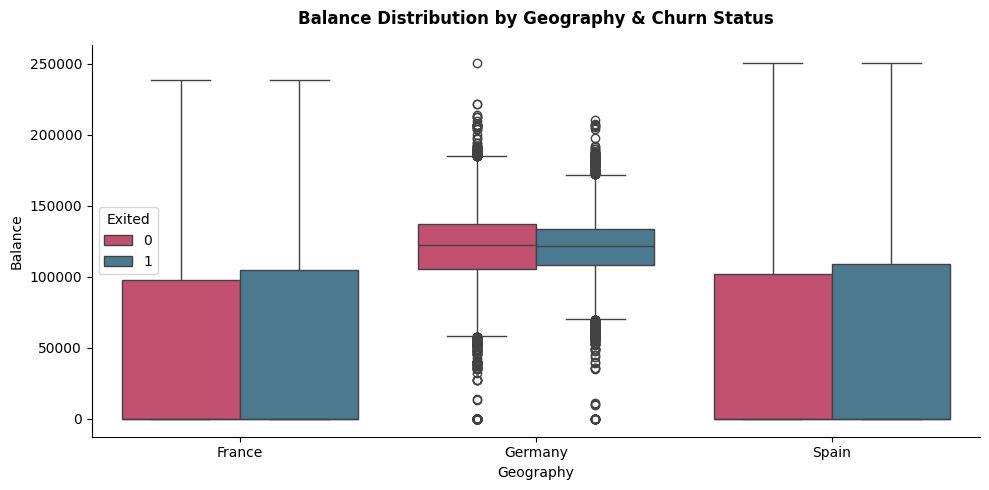

In [181]:
fig, ax = plt.subplots(figsize=(10, 5))

# A. Age Distribution by Geography & Churn Status
sns.boxplot(x="Geography", y="Balance", data=df_customer_churnma, ax=ax, hue=Config.target_feature, palette=color(n_colors=2))
ax.set_title("Balance Distribution by Geography & Churn Status", weight="bold", pad=15, fontsize=12)
ax.set_xlabel("Geography")
ax.set_ylabel("Balance")
sns.despine(left=False, bottom=False, ax=ax)

plt.tight_layout()
plt.show()

In [182]:
print("[i] Fitting logistic regression model...")
model_two = smf.logit(
    formula=f"{Config.target_feature} ~ Geography",
    data=df_customer_churnma
).fit()

print(model_two.summary())

# Compute Odds Ratios (OR)
coef = model_two.params
OR = np.exp(coef)

OR_table = pd.concat([coef, OR], axis=1)
OR_table.columns = ["coef", "OR"]

print("\n[i] Odds Ratios:")
print(OR_table)

[i] Fitting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.495714
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:               175032
Model:                          Logit   Df Residuals:                   175029
Method:                           MLE   Df Model:                            2
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                 0.03835
Time:                        17:45:00   Log-Likelihood:                -86766.
converged:                       True   LL-Null:                       -90226.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -1.6208      0.009   -1

**Analysis:**

**Yes — we should implement dedicated retention campaigns for Germany.**

**Because:**

1. Logistic regression shows German customers have **3× higher odds of churning** compared to France (OR ≈ 3.04).
2. German churners tend to have **high account balances**, making them more valuable and costly to lose.
3. They show **lower engagement** (less active, fewer products), which are strong churn drivers.

**Germany is clearly the highest-risk geography**, so a targeted retention strategy is justified and necessary.

### How do the **needs, expectations, or experiences** of female customers differ from males?

In [183]:
# Create summary table by gender
def gender_churn_summary(df):
    summary = df.groupby("Gender").agg(
        ChurnRate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Percent_Inactive=("IsActiveMember", lambda x: (x == 0).mean()),
        Avg_Age=("Age", "mean"),
        Avg_CreditScore = ("CreditScore", "mean"),
        Avg_EstimatedSalary = ("EstimatedSalary", "mean"),
        Count=("Exited", "count")
    ).reset_index()

    # Format percentages for readability
    summary["ChurnRate"] = (summary["ChurnRate"] * 100).round(2)
    summary["Percent_Inactive"] = (summary["Percent_Inactive"] * 100).round(2)
    summary["Avg_Balance"] = summary["Avg_Balance"].round(0)
    summary["Avg_CreditScore"] = summary["Avg_CreditScore"].round(0)
    summary["Avg_EstimatedSalary"] = summary["Avg_EstimatedSalary"].round(0)
    summary["Avg_Age"] = summary["Avg_Age"].round(1)

    return summary

# Apply to the entire dataset
summary_all = gender_churn_summary(df_customer_churnma)

from tabulate import tabulate
print(tabulate(summary_all, headers="keys", tablefmt="github", showindex=False))

| Gender   |   ChurnRate |   Avg_Balance |   Percent_Inactive |   Avg_Age |   Avg_CreditScore |   Avg_EstimatedSalary |   Count |
|----------|-------------|---------------|--------------------|-----------|-------------------|-----------------------|---------|
| Female   |       27.8  |         57666 |              52    |      38.8 |               656 |                112281 |   76427 |
| Male     |       15.94 |         55912 |              48.67 |      37.7 |               656 |                111537 |   98605 |


**Gender-based Churn Insights**

* **Churn Rate**: Female customers have a **significantly higher** churn rate compared to male customers (27.81% vs. 15.94%), indicating that gender is an important factor in churn behavior.
* **Account Balance**: On average, female customers have a **slightly higher** account balance than male customers (57,661 vs. 55,921).
* **Activity Level**: Female customers have a higher inactivity rate (52.01% vs. 48.68%), which may contribute to their higher churn rate.
* **Other factors** (Age, CreditScore, EstimatedSalary): Relatively similar between genders.

### Should we design **products/services** better suited for female customers?

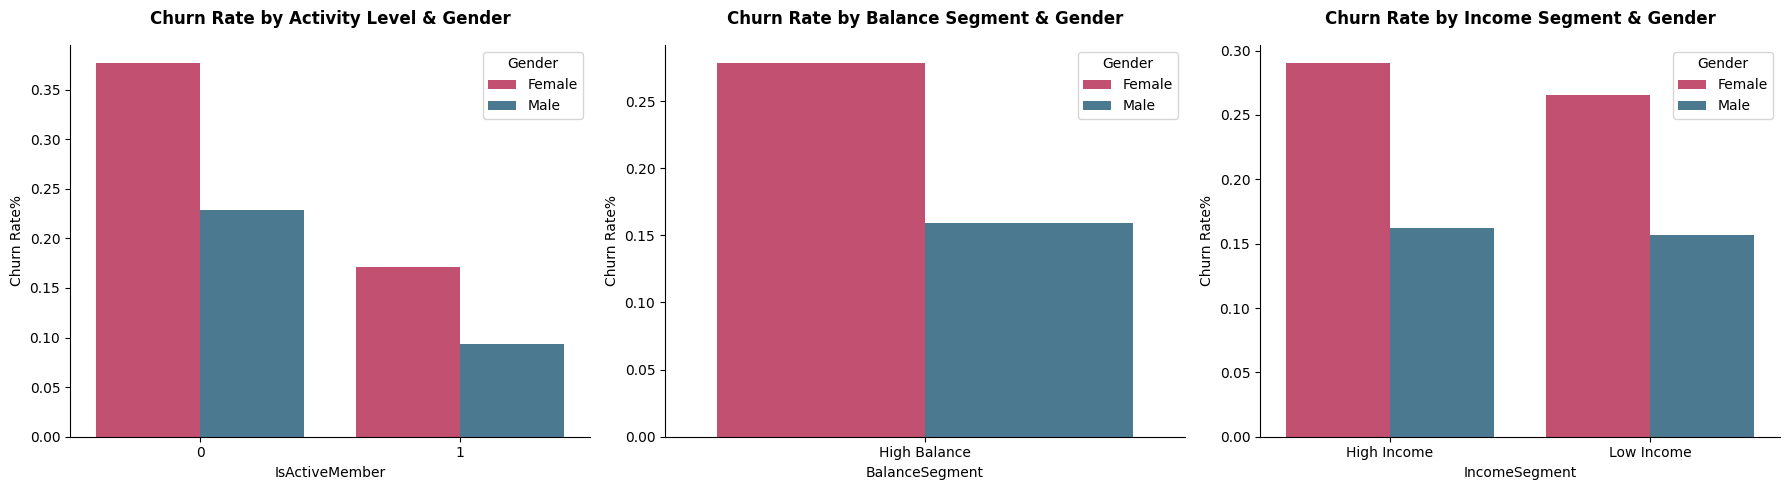

In [184]:
# 1. Create Balance & Income segments (high/low based on median)
balance_median = df_customer_churnma["Balance"].median()
income_median = df_customer_churnma["EstimatedSalary"].median()

df_customer_churnma["BalanceSegment"] = df_customer_churnma["Balance"].apply(lambda x: "High Balance" if x >= balance_median else "Low Balance")
df_customer_churnma["IncomeSegment"] = df_customer_churnma["EstimatedSalary"].apply(lambda x: "High Income" if x >= income_median else "Low Income")

# 2. Churn rate by activity level & gender
churn_activity_gender = (
    df_customer_churnma.groupby(["IsActiveMember", "Gender"])["Exited"]
    .mean()
    .reset_index()
)

# 3. Churn rate by customer value (Balance) & gender
churn_balance_gender = (
    df_customer_churnma.groupby(["BalanceSegment", "Gender"])["Exited"]
    .mean()
    .reset_index()
)

# 4. Churn rate by customer value (Income) & gender
churn_income_gender = (
    df_customer_churnma.groupby(["IncomeSegment", "Gender"])["Exited"]
    .mean()
    .reset_index()
)

# 5. Plot the charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Activity vs Gender
sns.barplot(data=churn_activity_gender, x="IsActiveMember", y="Exited", hue="Gender", ax=axes[0], palette=color(n_colors=2))
axes[0].set_title("Churn Rate by Activity Level & Gender", weight="bold", pad=15, fontsize=12)
axes[0].set_ylabel("Churn Rate%")
sns.despine(ax=axes[0])

# B. Balance vs Gender
sns.barplot(data=churn_balance_gender, x="BalanceSegment", y="Exited", hue="Gender", ax=axes[1], palette=color(n_colors=2))
axes[1].set_title("Churn Rate by Balance Segment & Gender", weight="bold", pad=15, fontsize=12)
axes[1].set_ylabel("Churn Rate%")
sns.despine(ax=axes[1])

# C. Income vs Gender
sns.barplot(data=churn_income_gender, x="IncomeSegment", y="Exited", hue="Gender", ax=axes[2], palette=color(n_colors=2))
axes[2].set_title("Churn Rate by Income Segment & Gender", weight="bold", pad=15, fontsize=12)
axes[2].set_ylabel("Churn Rate%")
sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()

**Analysis:**

* Across all segments, **female customers** consistently exhibit **higher churn rates** than male customers.
* The difference is most pronounced among:

  * **Inactive members**: Female churn rate \~37%, significantly higher than males (\~23%).
  * **High-balance customers**: Female churn rate \~28% vs. male \~16%.
  * **High-income customers**: Female churn rate \~29% vs. male \~16%.
* These segments represent **high-value customers** at greater risk of leaving.

**Recommendation – Tailored Offerings for Female Customers**
* Design **dedicated retention programs** targeting female customers, especially in the inactive, high-balance, and high-income segments.

### Do customers without credit cards share certain characteristics in Balance, Age, NumOfProducts, or IsActiveMember?

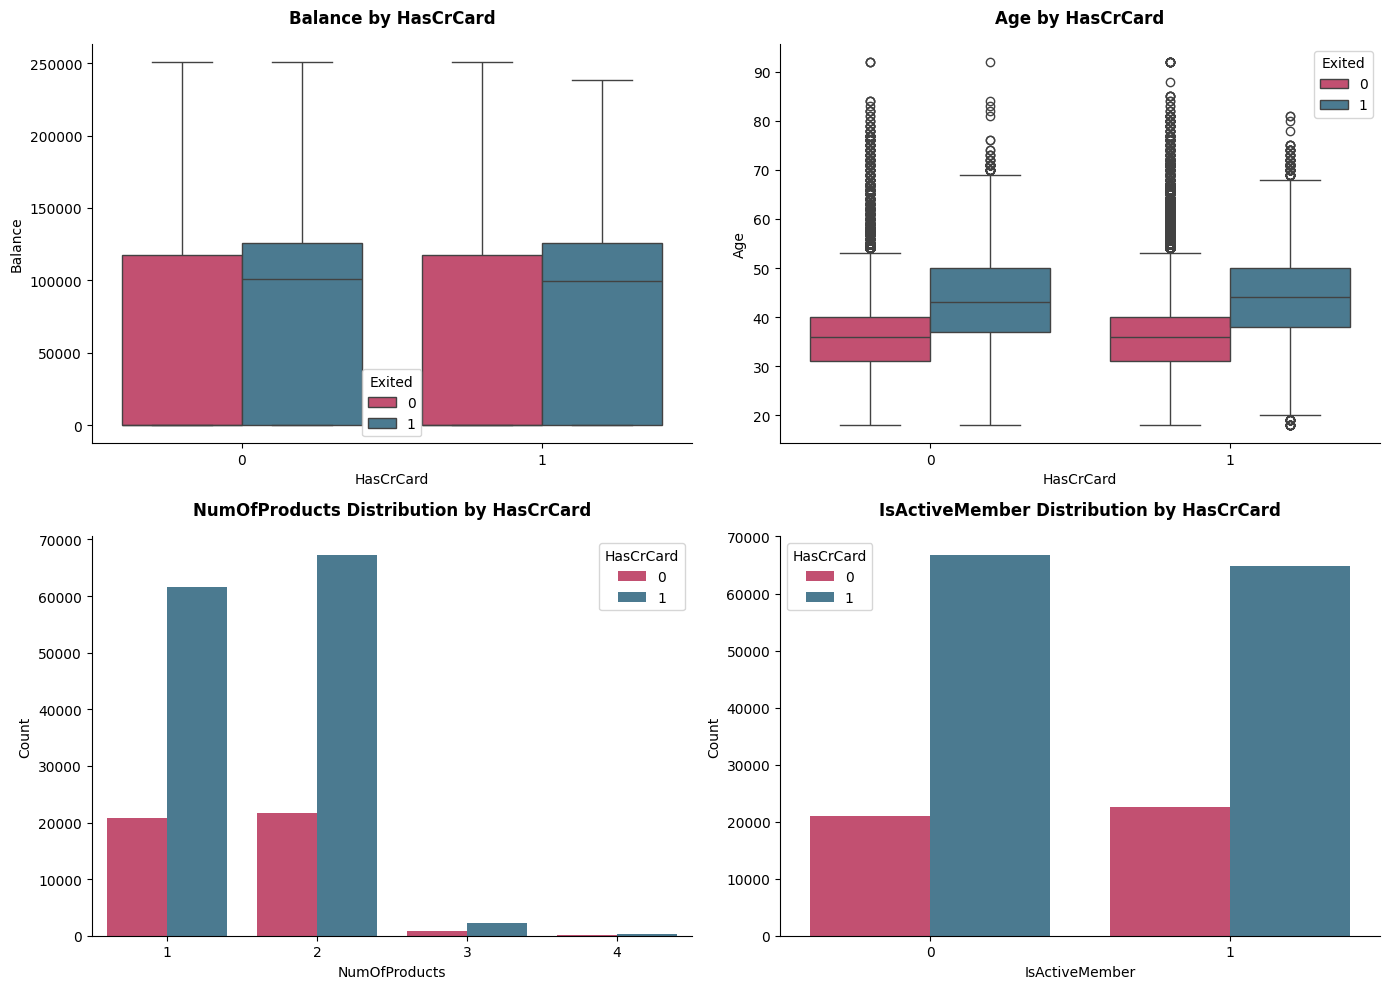

In [185]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Balance by HasCrCard
sns.boxplot(
    data=df_customer_churnma,
    x="HasCrCard",
    y="Balance",
    palette=color(n_colors=2),
    hue="Exited",
    ax=ax[0, 0]
)
sns.despine(ax=ax[0, 0])
ax[0, 0].set_title("Balance by HasCrCard", weight="bold", pad=15)
ax[0, 0].set_xlabel("HasCrCard")
ax[0, 0].set_ylabel("Balance")

# 2. Age by HasCrCard
sns.boxplot(
    data=df_customer_churnma,
    x="HasCrCard",
    y="Age",
    palette=color(n_colors=2),
    hue="Exited",
    ax=ax[0, 1]
)
sns.despine(ax=ax[0, 1])
ax[0, 1].set_title("Age by HasCrCard", weight="bold", pad=15)
ax[0, 1].set_xlabel("HasCrCard")
ax[0, 1].set_ylabel("Age")

# 3. NumOfProducts distribution by HasCrCard
num_prod_dist = df_customer_churnma.groupby(
    ["HasCrCard", "NumOfProducts"]
).size().reset_index(name="Count")

sns.barplot(
    data=num_prod_dist,
    x="NumOfProducts",
    y="Count",
    hue="HasCrCard",
    palette=color(n_colors=2),
    ax=ax[1, 0]
)
sns.despine(ax=ax[1, 0])
ax[1, 0].set_title("NumOfProducts Distribution by HasCrCard", weight="bold", pad=15)
ax[1, 0].set_xlabel("NumOfProducts")
ax[1, 0].set_ylabel("Count")


# 4. IsActiveMember distribution by HasCrCard
active_dist = df_customer_churnma.groupby(
    ["HasCrCard", "IsActiveMember"]
).size().reset_index(name="Count")

sns.barplot(
    data=active_dist,
    x="IsActiveMember",
    y="Count",
    hue="HasCrCard",
    palette=color(n_colors=2),
    ax=ax[1, 1]
)
sns.despine(ax=ax[1, 1])
ax[1, 1].set_title("IsActiveMember Distribution by HasCrCard", weight="bold", pad=15)
ax[1, 1].set_xlabel("IsActiveMember")
ax[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Analysis:**

> **Customers without credit cards** do not show significant differences in **Balance** or **Age** compared to those with credit cards. However, they:
>
> * Are less likely to have more than 2 products
> * Have a slightly higher proportion of inactive members.

### Do inactive customers share specific characteristics in CreditScore, Balance, Age, and NumOfProducts?

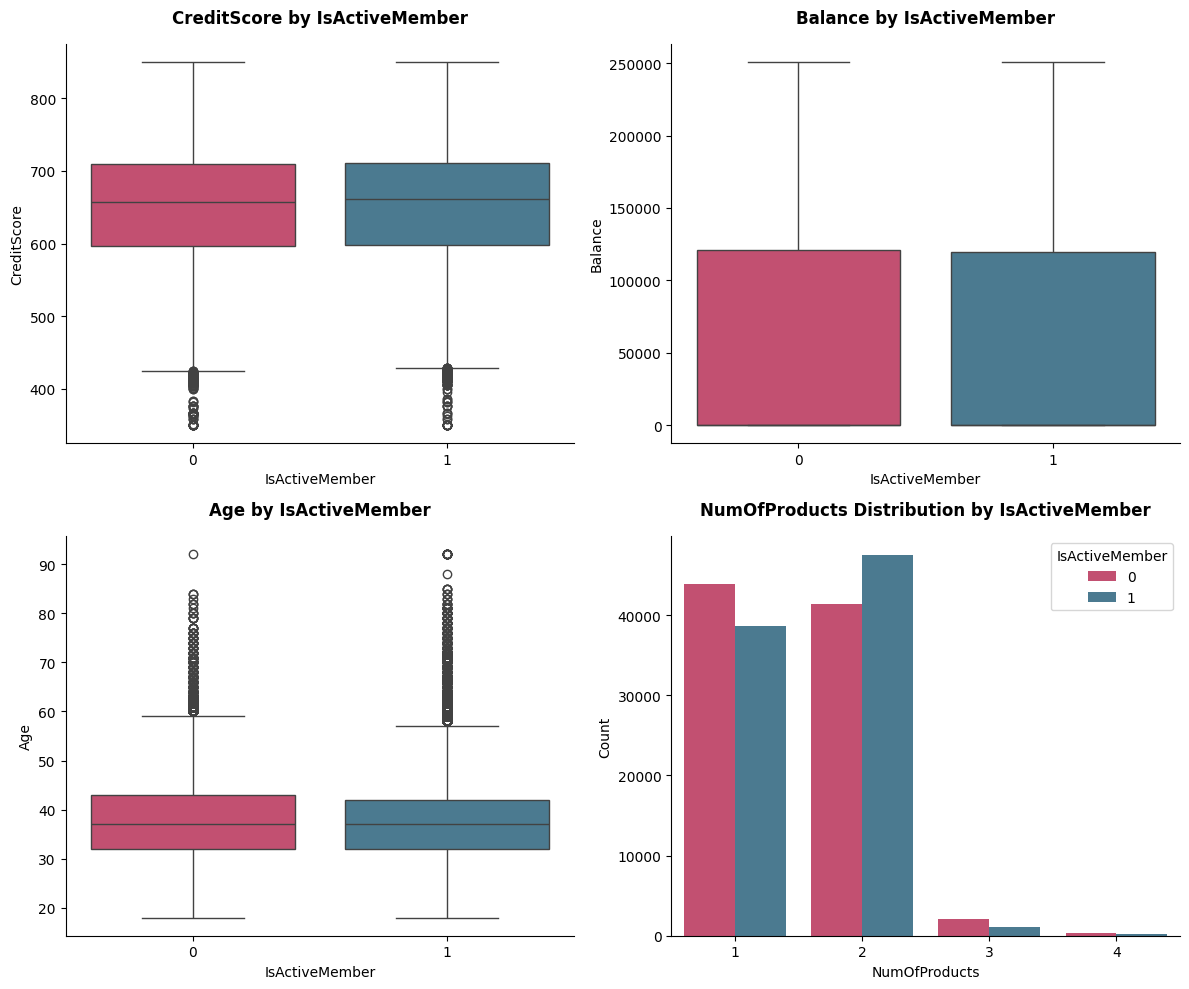

In [186]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# 1. CreditScore by IsActiveMember
sns.boxplot(data=df_customer_churnma, x="IsActiveMember", y="CreditScore", palette=color(n_colors=2), ax=ax[0,0])
sns.despine(ax=ax[0, 0])
ax[0,0].set_title("CreditScore by IsActiveMember", weight="bold", pad=15)
ax[0,0].set_xlabel("IsActiveMember")
ax[0,0].set_ylabel("CreditScore")

# 2. Balance by IsActiveMember
sns.boxplot(data=df_customer_churnma, x="IsActiveMember", y="Balance", palette=color(n_colors=2), ax=ax[0,1])
sns.despine(ax=ax[0, 1])
ax[0,1].set_title("Balance by IsActiveMember", weight="bold", pad=15)
ax[0,1].set_xlabel("IsActiveMember")
ax[0,1].set_ylabel("Balance")

# 3. Age by IsActiveMember
sns.boxplot(data=df_customer_churnma, x="IsActiveMember", y="Age", palette=color(n_colors=2), ax=ax[1,0])
sns.despine(ax=ax[1, 0])
ax[1,0].set_title("Age by IsActiveMember", weight="bold", pad=15)
ax[1,0].set_xlabel("IsActiveMember")
ax[1,0].set_ylabel("Age")

# 4. NumOfProducts distribution by IsActiveMember
num_prod_dist = df_customer_churnma.groupby(["IsActiveMember", "NumOfProducts"]).size().reset_index(name="Count")
sns.barplot(data=num_prod_dist, x="NumOfProducts", y="Count", hue="IsActiveMember", palette=color(n_colors=2), ax=ax[1,1])
sns.despine(ax=ax[1, 1])
ax[1,1].set_title("NumOfProducts Distribution by IsActiveMember", weight="bold", pad=15)
ax[1,1].set_xlabel("NumOfProducts")
ax[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Analysis:**

> **Inactive customers** (IsActiveMember = 0) are not significantly different from active customers in terms of **CreditScore**, **Age** and **Balance**.
> However, they:
>
> * Are more concentrated in the single-product segment.

### Are customers with only 1 product typically those with lower CreditScore or lower Balance? 

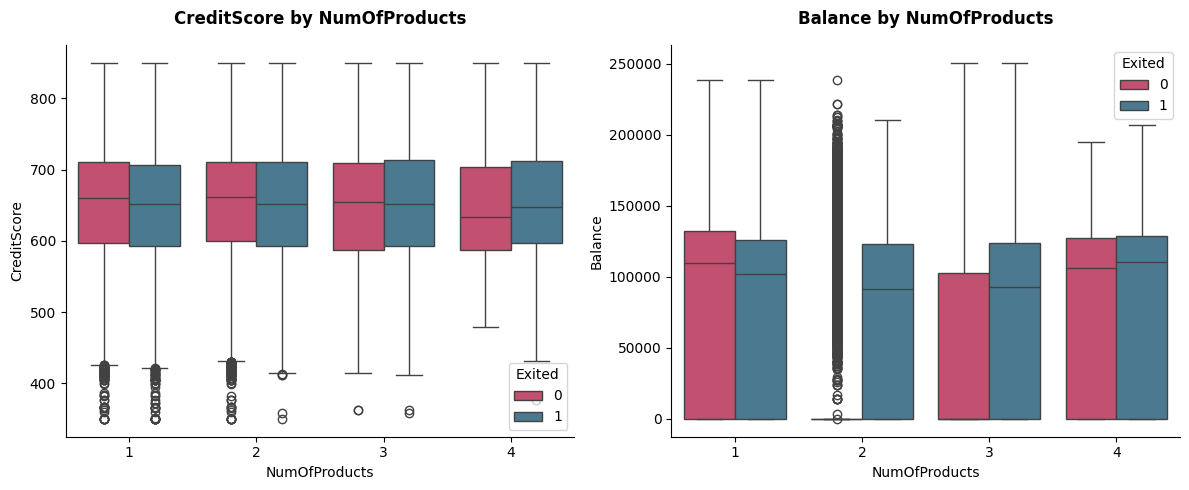

In [187]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 1. CreditScore by NumOfProducts
sns.boxplot(
    data=df_customer_churnma,
    x="NumOfProducts",
    y="CreditScore",
    hue="Exited",
    palette=color(n_colors=2),
    ax=ax[0]
)
ax[0].set_title("CreditScore by NumOfProducts", weight="bold", pad=15)
ax[0].set_xlabel("NumOfProducts")
ax[0].set_ylabel("CreditScore")
sns.despine(ax=ax[0])

# 2. Balance by NumOfProducts
sns.boxplot(
    data=df_customer_churnma,
    x="NumOfProducts",
    y="Balance",
    hue="Exited",
    palette=color(n_colors=2),
    ax=ax[1]
)
ax[1].set_title("Balance by NumOfProducts", weight="bold", pad=15)
ax[1].set_xlabel("NumOfProducts")
ax[1].set_ylabel("Balance")
sns.despine(ax=ax[1])

plt.tight_layout()
plt.show()

**Analysis:**

**CreditScore by NumOfProducts**

* Customers with **only 1 product** do not have noticeably lower CreditScores compared to other groups.
* The median CreditScore for this group is quite similar to those with 2–4 products (\~650–670).

**Balance by NumOfProducts**

* The **1-product** group actually has a **high median Balance**, not low — in fact, it’s higher than the 2-product group (since the latter has many customers with a Balance of 0).
* This indicates that having only 1 product **does not imply** weaker financial capacity.

**Conclusion**

> Customers with only 1 product are **not** a group with low CreditScores or low Balances.

### Do customers with 3–4 products have different characteristics compared to the 2-product (low churn) group?

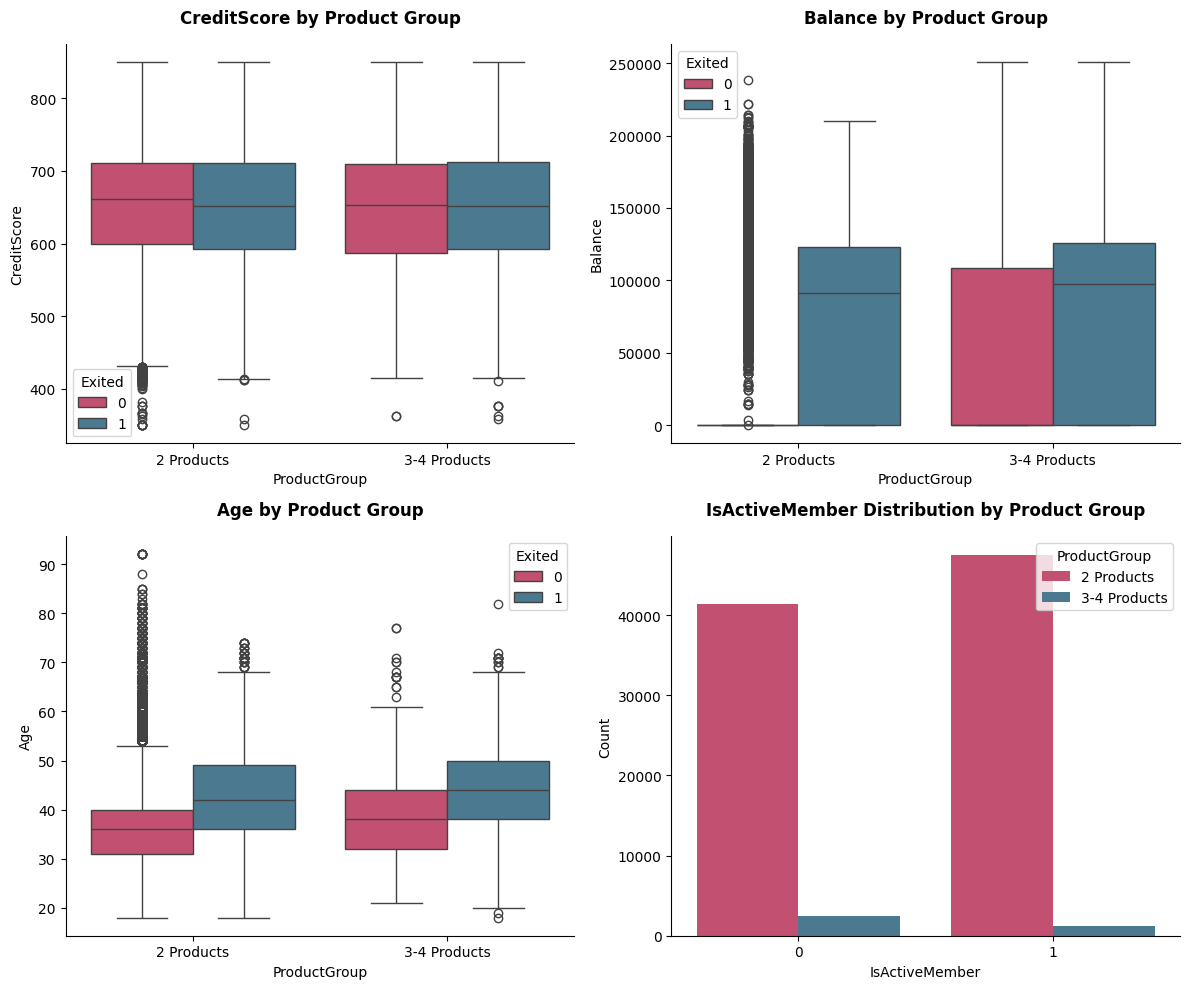

In [188]:
# Filter only the 2-product group and the 3–4 product group
df_compare = df_customer_churnma[df_customer_churnma["NumOfProducts"].isin([2, 3, 4])].copy()
df_compare["ProductGroup"] = df_compare["NumOfProducts"].apply(lambda x: "3-4 Products" if x >= 3 else "2 Products")

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# 1. CreditScore
sns.boxplot(data=df_compare, x="ProductGroup", y="CreditScore", palette=color(n_colors=2), hue="Exited", ax=ax[0,0])
sns.despine(ax=ax[0, 0])
ax[0,0].set_title("CreditScore by Product Group", weight="bold", pad=15)

# 2. Balance
sns.boxplot(data=df_compare, x="ProductGroup", y="Balance", palette=color(n_colors=2), hue="Exited", ax=ax[0,1])
sns.despine(ax=ax[0, 1])
ax[0,1].set_title("Balance by Product Group", weight="bold", pad=15)

# 3. Age
sns.boxplot(data=df_compare, x="ProductGroup", y="Age", palette=color(n_colors=2), hue="Exited", ax=ax[1,0])
sns.despine(ax=ax[1, 0])
ax[1,0].set_title("Age by Product Group", weight="bold", pad=15)

# 4. IsActiveMember distribution
active_dist = df_compare.groupby(["ProductGroup", "IsActiveMember"]).size().reset_index(name="Count")
sns.barplot(data=active_dist, x="IsActiveMember", y="Count", hue="ProductGroup", palette=color(n_colors=2), ax=ax[1,1])
sns.despine(ax=ax[1, 1])
ax[1,1].set_title("IsActiveMember Distribution by Product Group", weight="bold", pad=15)

plt.tight_layout()
plt.show()

**Analysis:**

**CreditScore**

* The median CreditScore for the **3–4 products** group is almost the same as for the **2 products** group.
* In both groups, churned customers (Exited = 1) tend to have lower CreditScores than retained customers.

**Balance**

* Both groups have similar Balance distributions, with no significant difference in the median.
* In both groups, churned customers generally have lower Balances than those who stayed.

**Age**

* The **3–4 products** group has a **slightly higher** median age compared to the 2 products group.
* In both groups, churned customers tend to be older than retained customers.

**IsActiveMember**

* The **3–4 products** group is predominantly **inactive** (IsActiveMember = 0), which is a stark contrast to the 2 products group.
* This is the most notable difference between the two groups and could be the main reason for the higher churn rate in the 3–4 products group.

**Summary Conclusion**

> Compared to the 2 products group (low churn), the 3–4 products group does not differ much in **CreditScore** and **Balance**, and only has a slightly higher **Age**.
> The key difference is that the 3–4 products group has an **high inactive rate**, which could explain its higher churn rate.

### Does churn rate consistently decrease as CreditScore increases?

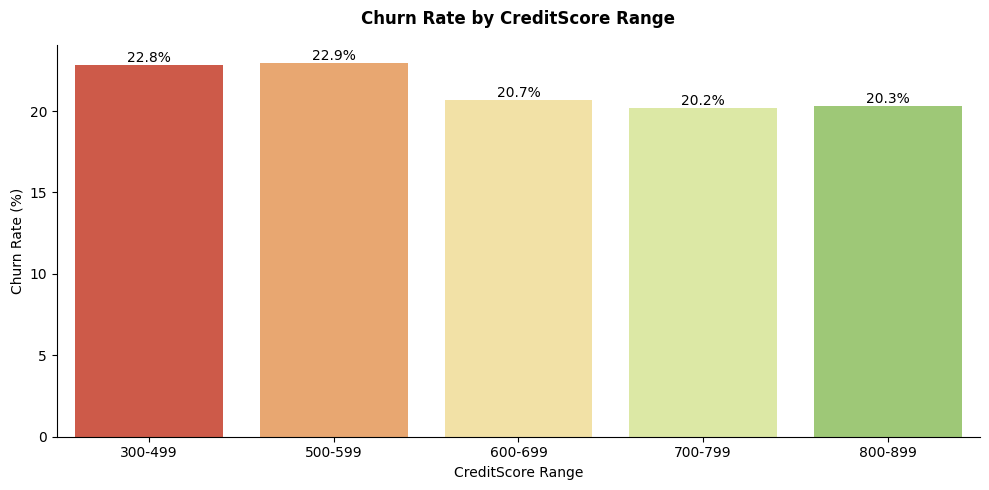

In [189]:
# Divide CreditScore into ranges (bins)
bins = [300, 500, 600, 700, 800, 900]  # adjust as needed
labels = ["300-499", "500-599", "600-699", "700-799", "800-899"]
df_customer_churnma["CS_group"] = pd.cut(df_customer_churnma["CreditScore"], bins=bins, labels=labels, right=False)

# Calculate churn rate for each group
churn_by_group = df_customer_churnma.groupby("CS_group")["Exited"].mean().reset_index()
churn_by_group["Exited"] *= 100  # convert to percentage

# Plot barplot
plt.figure(figsize=(10,5))
sns.barplot(data=churn_by_group, x="CS_group", y="Exited",palette=color(n_colors=5, tone="RdYlGn"))
sns.despine()
plt.title("Churn Rate by CreditScore Range", weight="bold", pad=15)
plt.ylabel("Churn Rate (%)")
plt.xlabel("CreditScore Range")

# Display percentage values
for i, v in enumerate(churn_by_group["Exited"]):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

**Analysis:**

* **Churn rate does not consistently decrease** as CreditScore increases.
* The first two ranges (**300–499** and **500–599**) have similar churn rates (\~22.8–22.9%).
* There is a small drop for **600–699** (\~20.7%) and **700–799** (\~20.2%), but it slightly increases again for **800–899** (\~20.3%).
* Overall, the difference between the highest and lowest churn rate ranges is small (\~2.7 percentage points), suggesting that CreditScore alone is not a strong predictor of churn in this dataset.

### Are there notable patterns when combining CreditScore with Geography or Age?

[i] Computing percentage table by Credit Score Group × Age Group × Geography...


Exited                                            0          1
Geography credit_score_group age_group                        
France    excellent          adult        92.710997   7.289003
                             elderly      94.915254   5.084746
                             mature       56.796117  43.203883
                             mid_age      81.510417  18.489583
                             senior       61.224490  38.775510
...                                             ...        ...
Spain     very_poor          elderly      81.818182  18.181818
                             mature       56.204380  43.795620
                             mid_age      76.957494  23.042506
                             senior       59.183673  40.816327
                             young_adult  89.062500  10.937500

[90 rows x 2 columns]

[i] Running Chi-Square Test for combined factors (Credit Score Group × Age Group × Geography) vs Exited...
[i] Chi2: 32365.7608
[i] dof: 89
[i] p-value: 0.000000


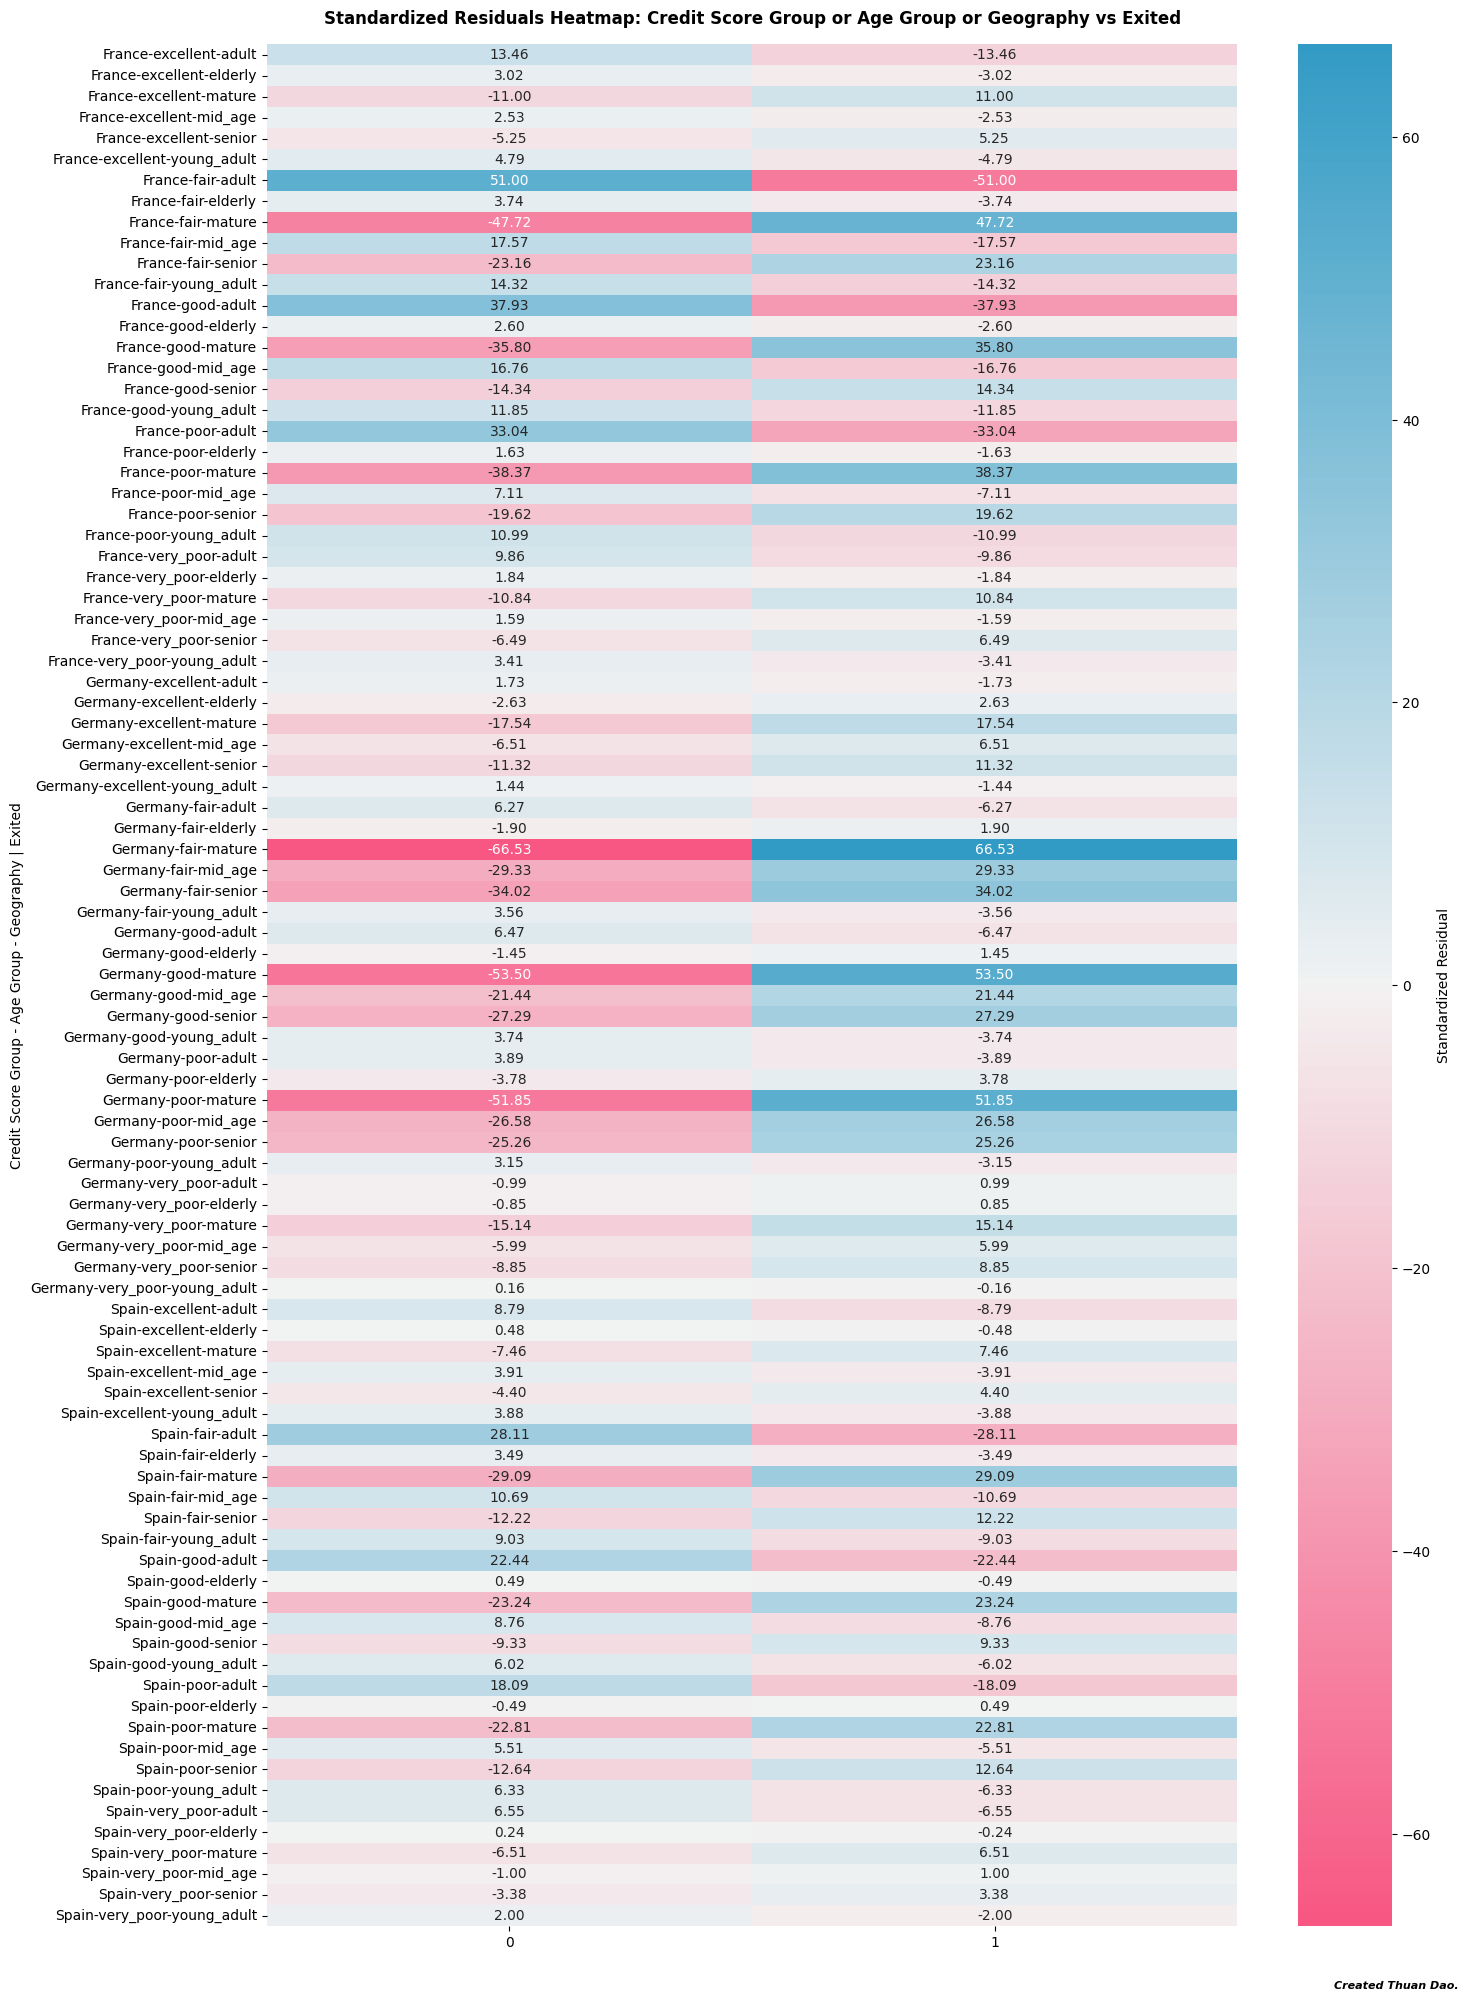

In [190]:
def credit_score_group(x):
    if 350 <= x < 500:
        return "very_poor"
    elif 500 <= x < 600:
        return "poor"
    elif 600 <= x < 700:
        return "fair"
    elif 700 <= x < 800:
        return "good"
    elif 800 <= x <= 850:
        return "excellent"
    else:
        return "unknown"
df_customer_churnma["credit_score_group"] = df_customer_churnma["CreditScore"].apply(credit_score_group)

def age_group(x):
    if 18 <= x <= 25:
        return "young_adult"
    elif 26 <= x <= 35:
        return "adult"
    elif 36 <= x <= 45:
        return "mid_age"
    elif 46 <= x <= 55:
        return "mature"
    elif 56 <= x <= 65:
        return "senior"
    elif 66 <= x <= 92:
        return "elderly"
    else:
        return "unknown"
df_customer_churnma["age_group"] = df_customer_churnma["Age"].apply(age_group)

print("[i] Computing percentage table by Credit Score Group × Age Group × Geography...")
df_group = pd.crosstab(
    [df_customer_churnma["Geography"], df_customer_churnma["credit_score_group"], df_customer_churnma["age_group"]],
    df_customer_churnma["Exited"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Credit Score Group × Age Group × Geography) vs Exited...")
contingency = pd.crosstab(
    [df_customer_churnma["Geography"], df_customer_churnma["credit_score_group"], df_customer_churnma["age_group"]],
    df_customer_churnma["Exited"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom
std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,20))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Credit Score Group or Age Group or Geography vs Exited", 
          weight="bold", fontsize=12, pad=15)
plt.ylabel("Credit Score Group - Age Group - Geography | Exited")
plt.xlabel("")
plt.text(2.2,93, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Analysis:**

Yes — the heatmap reveals **clear and strong patterns** when combining CreditScore with Geography or Age:

1. **Germany shows the strongest high-risk combinations**, especially

   * Fair/Poor credit × Mid-age/Adult/Elderly.
2. **France shows strong retention** among high-credit older groups.
3. **Spain patterns are moderate** without extreme churn clusters.
4. **Age interacts heavily with credit score**, amplifying churn for older low-credit groups.

### Is churn rate linearly related to Age, or is it higher only in certain age groups?

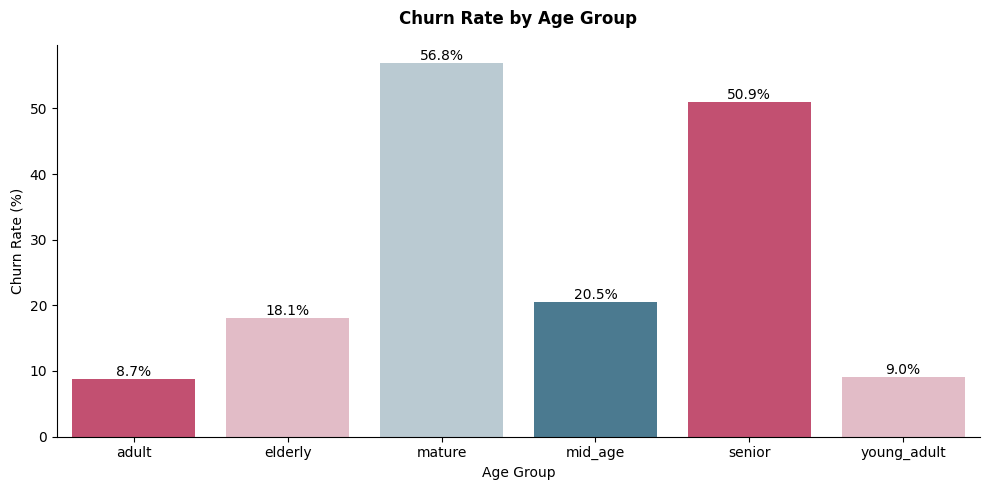

In [191]:
# Calculate churn rate for each group
churn_by_group = df_customer_churnma.groupby("age_group")["Exited"].mean().reset_index()
churn_by_group["Exited"] *= 100  # convert to percentage

# Plot barplot
plt.figure(figsize=(10,5))
sns.barplot(data=churn_by_group, x="age_group", y="Exited",palette=color(n_colors=4))
sns.despine()
plt.title("Churn Rate by Age Group", weight="bold", pad=15)
plt.ylabel("Churn Rate (%)")
plt.xlabel("Age Group")

# Display percentage values
for i, v in enumerate(churn_by_group["Exited"]):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

**Analysis:**

***Churn rate is not linearly related to age. Instead, it spikes sharply in specific age groups (particularly mature and senior customers), while younger and very elderly customers show much lower churn levels.***

### Does the high-balance group churn more in all Geographies?

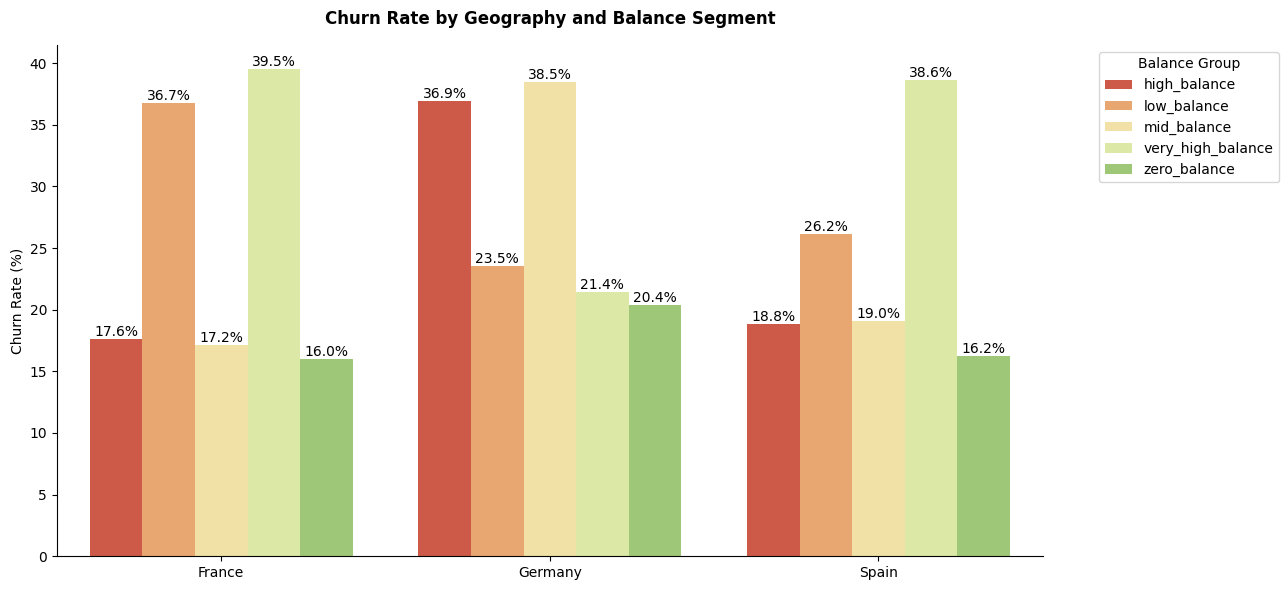

In [192]:
# Split Balance into High/Low based on the overall median
def balance_group(x):
    if x == 0:
        return "zero_balance"
    elif 0 < x <= 50000:
        return "low_balance"
    elif 50000 < x <= 120000:
        return "mid_balance"
    elif 120000 < x <= 200000:
        return "high_balance"
    elif 200000 < x <= 250898.1:
        return "very_high_balance"
    else:
        return "unknown"
df_customer_churnma["balance_group"] = df_customer_churnma["Balance"].apply(balance_group)

# Calculate churn rate
churn_rate = (
    df_customer_churnma.groupby(["Geography", "balance_group"])["Exited"]
    .mean()
    .reset_index()
)
churn_rate["Exited"] *= 100  # convert to percentage

# Plot bar chart
plt.figure(figsize=(13,6))
sns.barplot(data=churn_rate, x="Geography", y="Exited", hue="balance_group", 
            palette=color(n_colors=df_customer_churnma["balance_group"].nunique(), tone="RdYlGn"))
sns.despine()
plt.title("Churn Rate by Geography and Balance Segment", weight="bold", pad=15)
plt.ylabel("Churn Rate (%)")
plt.xlabel("")

# Display percentage values
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.text(p.get_x() + p.get_width()/2, p.get_height(),
                 f'{p.get_height():.1f}%',
                 ha='center', va='bottom')

plt.legend(title="Balance Group", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


**Analysis:**

***The high-balance group does not consistently churn more across all geographies. In France and Spain, high-balance customers have relatively low churn, while Germany shows higher churn but still not the highest among balance groups.***

### How does the relationship between Balance and IsActiveMember affect churn?

[i] Computing percentage table by Balance Group × Active Member...


Exited                                    0          1
balance_group     IsActiveMember                      
high_balance      0               63.338057  36.661943
                  1               83.858286  16.141714
low_balance       0               57.575758  42.424242
                  1               79.054054  20.945946
mid_balance       0               63.049494  36.950506
                  1               83.043265  16.956735
very_high_balance 0               59.782609  40.217391
                  1               68.918919  31.081081
zero_balance      0               77.000433  22.999567
                  1               90.705373   9.294627

[i] Running Chi-Square Test for combined factors (Balance Group × Active Member) vs Exited...
[i] Chi2: 10728.7280
[i] dof: 9
[i] p-value: 0.000000


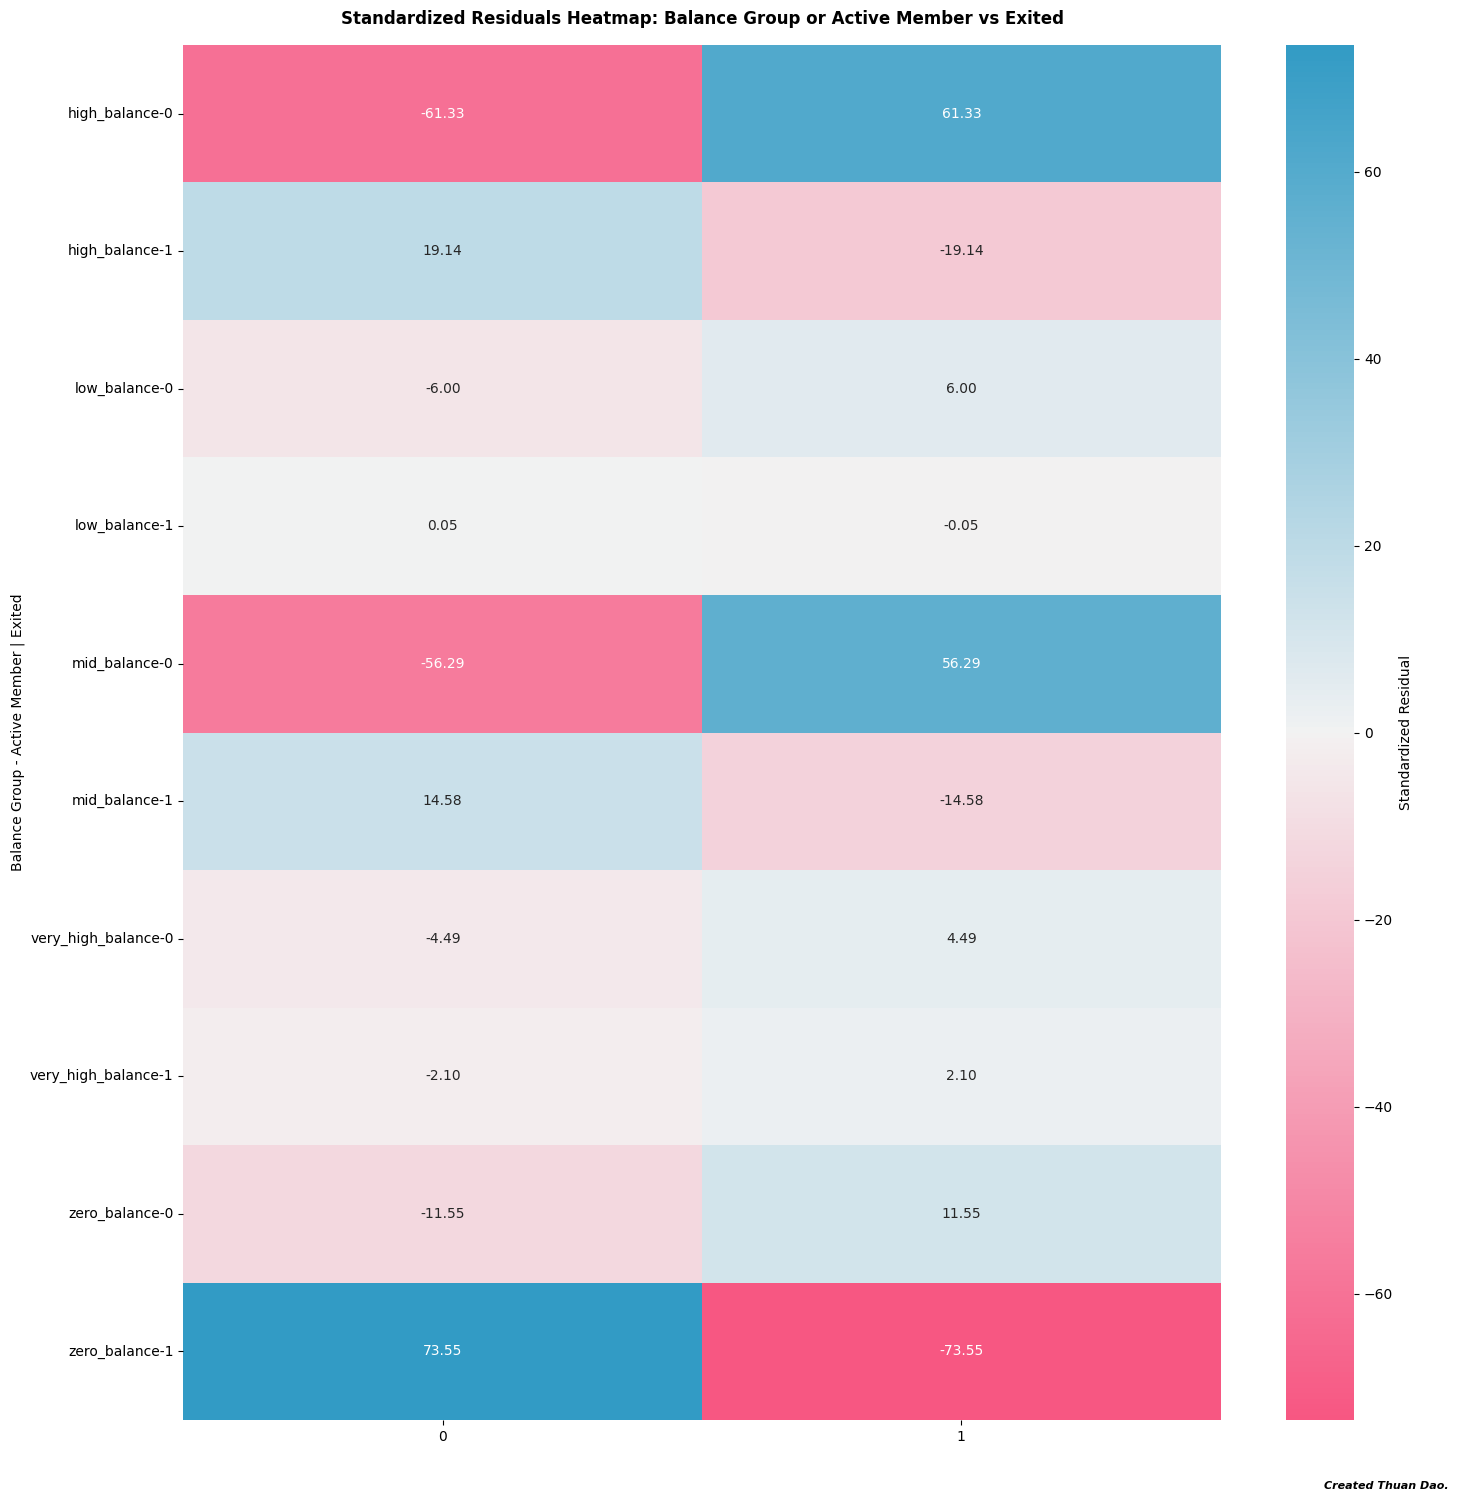

In [193]:
print("[i] Computing percentage table by Balance Group × Active Member...")
df_group = pd.crosstab(
    [df_customer_churnma["balance_group"], df_customer_churnma["IsActiveMember"]],
    df_customer_churnma["Exited"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Balance Group × Active Member) vs Exited...")
contingency = pd.crosstab(
    [df_customer_churnma["balance_group"], df_customer_churnma["IsActiveMember"]],
    df_customer_churnma["Exited"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom
std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,15))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Balance Group or Active Member vs Exited", 
          weight="bold", fontsize=12, pad=15)
plt.ylabel("Balance Group - Active Member | Exited")
plt.xlabel("")
plt.text(2.2,10.5, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Analysis:**

***Churn is driven more by customer activity status than balance alone. Inactive customers churn much more than expected across all balance levels—especially zero-balance, mid-balance, and high-balance groups. Conversely, active customers show significantly lower churn rates regardless of their balance.***

### Are there specific Tenure ranges (0–2 years, 7–10 years) with abnormal churn when combined with Geography or Age?

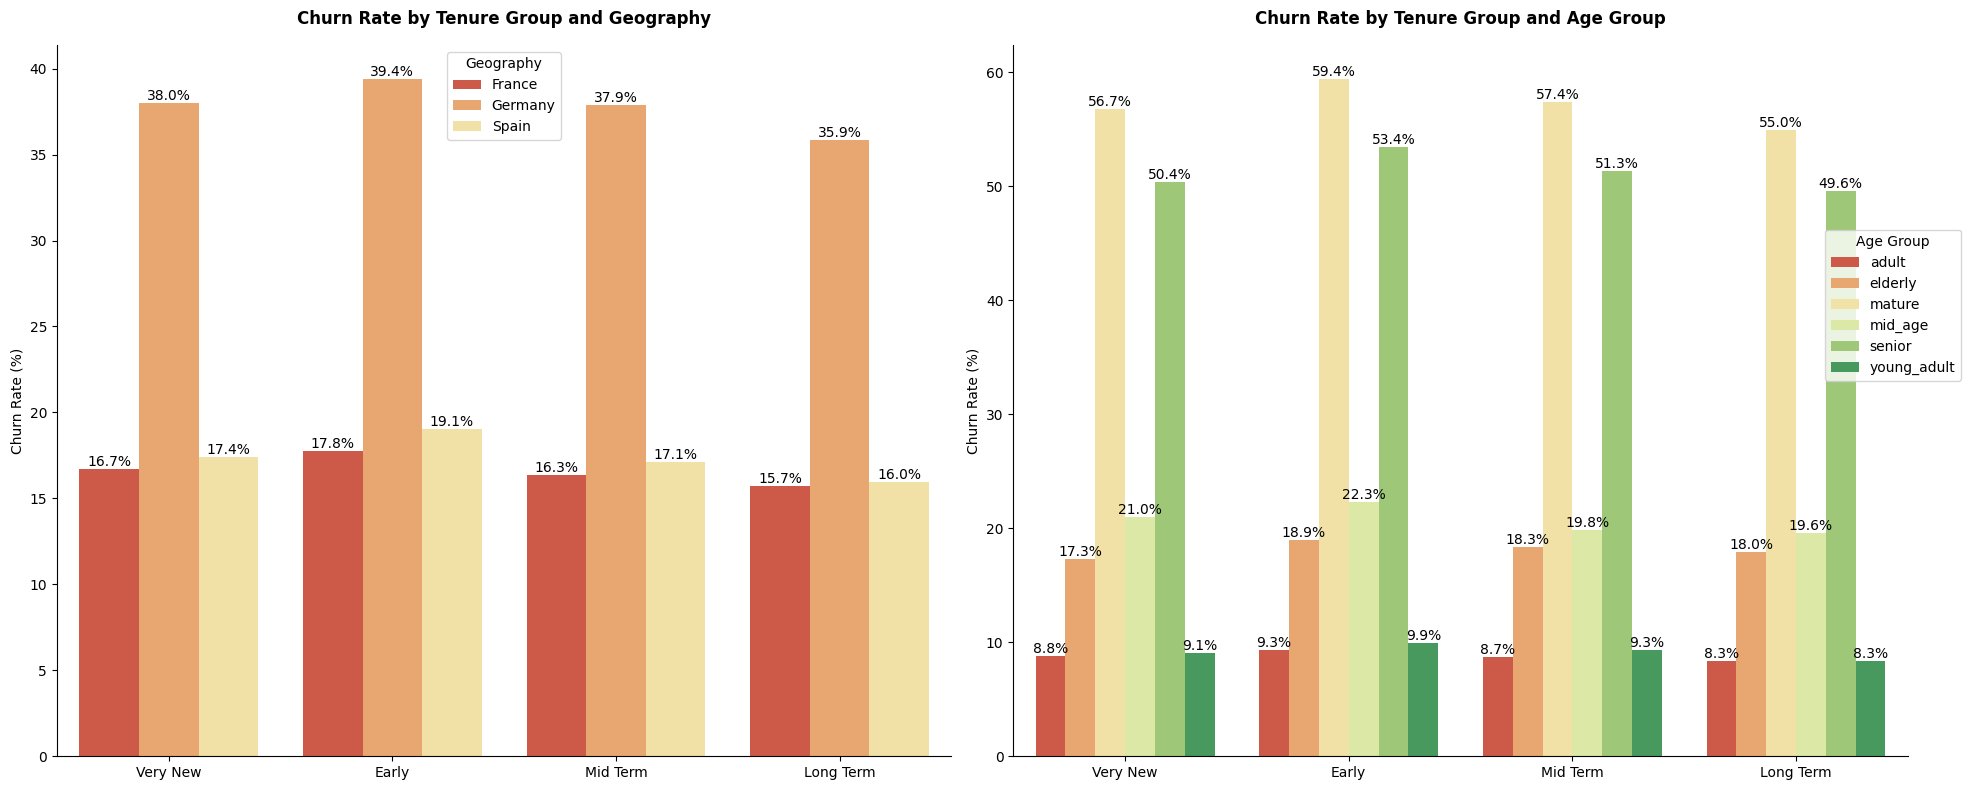

In [194]:
def tenure_group(x):
    if 0 <= x <= 2:
        return "Very New"
    elif 3 <= x <= 4:
        return "Early"
    elif 5 <= x <= 6:
        return "Mid Term"
    elif 7 <= x <= 10:
        return "Long Term"
    else:
        return "Unknown"

df_customer_churnma["tenure_group"] = df_customer_churnma["Tenure"].apply(tenure_group)

# Churn rate by TenureGroup × Geography
churn_geo = (
    df_customer_churnma.groupby(["tenure_group", "Geography"])["Exited"]
    .mean()
    .reset_index()
)
churn_geo["Exited"] *= 100

# Churn rate by TenureGroup × AgeGroup
churn_age = (
    df_customer_churnma.groupby(["tenure_group", "age_group"])["Exited"]
    .mean()
    .reset_index()
)
churn_age["Exited"] *= 100

fig, ax = plt.subplots(1, 2, figsize=(20, 8))
# Barplot: Tenure Group × Geography
sns.barplot(
    data=churn_geo,
    x="tenure_group",
    y="Exited",
    hue="Geography",
    palette=color(n_colors=4, tone="RdYlGn"),
    ax=ax[0], order=["Very New", "Early", "Mid Term", "Long Term"]
)
sns.despine(ax=ax[0])
ax[0].set_title("Churn Rate by Tenure Group and Geography", weight="bold", pad=15)
ax[0].set_ylabel("Churn Rate (%)")
ax[0].set_xlabel("")

# Annotate
for p in ax[0].patches:
    height = p.get_height()
    if height > 0:
        ax[0].text(
            p.get_x() + p.get_width()/2,
            height,
            f"{height:.1f}%",
            ha="center", va="bottom"
        )

# Barplot: Tenure Group × Age Group
sns.barplot(
    data=churn_age,
    x="tenure_group",
    y="Exited",
    hue="age_group",
    palette=color(n_colors=6, tone="RdYlGn"),
    ax=ax[1], order=["Very New", "Early", "Mid Term", "Long Term"]
)
sns.despine(ax=ax[1])
ax[1].set_title("Churn Rate by Tenure Group and Age Group", weight="bold", pad=15)
ax[1].set_ylabel("Churn Rate (%)")
ax[1].set_xlabel("")
ax[1].legend(title="Age Group", bbox_to_anchor=(0.9, 0.75), loc="upper left")

# Annotate
for p in ax[1].patches:
    height = p.get_height()
    if height > 0:
        ax[1].text(
            p.get_x() + p.get_width()/2,
            height,
            f"{height:.1f}%",
            ha="center", va="bottom"
        )

plt.tight_layout()
plt.show()

**Analysis:**

**Across Geography:**

No — churn does **not** spike or drop abnormally for Tenure 0–2 or 7–10 years.
Churn stays stable across Tenure within each geography.

**Across Age:**

Yes — churn is **abnormally high** across all Tenure ranges for:

* **Mature** customers (≈56–59%)
* **Senior** customers (≈50–53%)

→ These two age groups show **consistently extreme churn**, regardless of whether their Tenure is **very new, early, mid-term, or long-term**.

### Is there any relationship between EstimatedSalary and other variables (Balance, CreditScore) that helps explain churn?

[i] Computing percentage table by Credit Score Group × Balance Group × Salary Group...


Exited                                                          0          1
salary_group     credit_score_group balance_group                           
high_income      excellent          high_balance        72.936660  27.063340
                                    low_balance        100.000000   0.000000
                                    mid_balance         78.596491  21.403509
                                    very_high_balance  100.000000   0.000000
                                    zero_balance        85.893720  14.106280
...                                                           ...        ...
very_high_income very_poor          high_balance        74.299065  25.700935
                                    low_balance         50.000000  50.000000
                                    mid_balance         70.987654  29.012346
                                    very_high_balance  100.000000   0.000000
                                    zero_balance        82.382763  17.617237

[109 rows x 2 columns]

[i] Running Chi-Square Test for combined factors (Credit Score Group × Balance Group × Salary Group) vs Exited...
[i] Chi2: 3401.9635
[i] dof: 108
[i] p-value: 0.000000


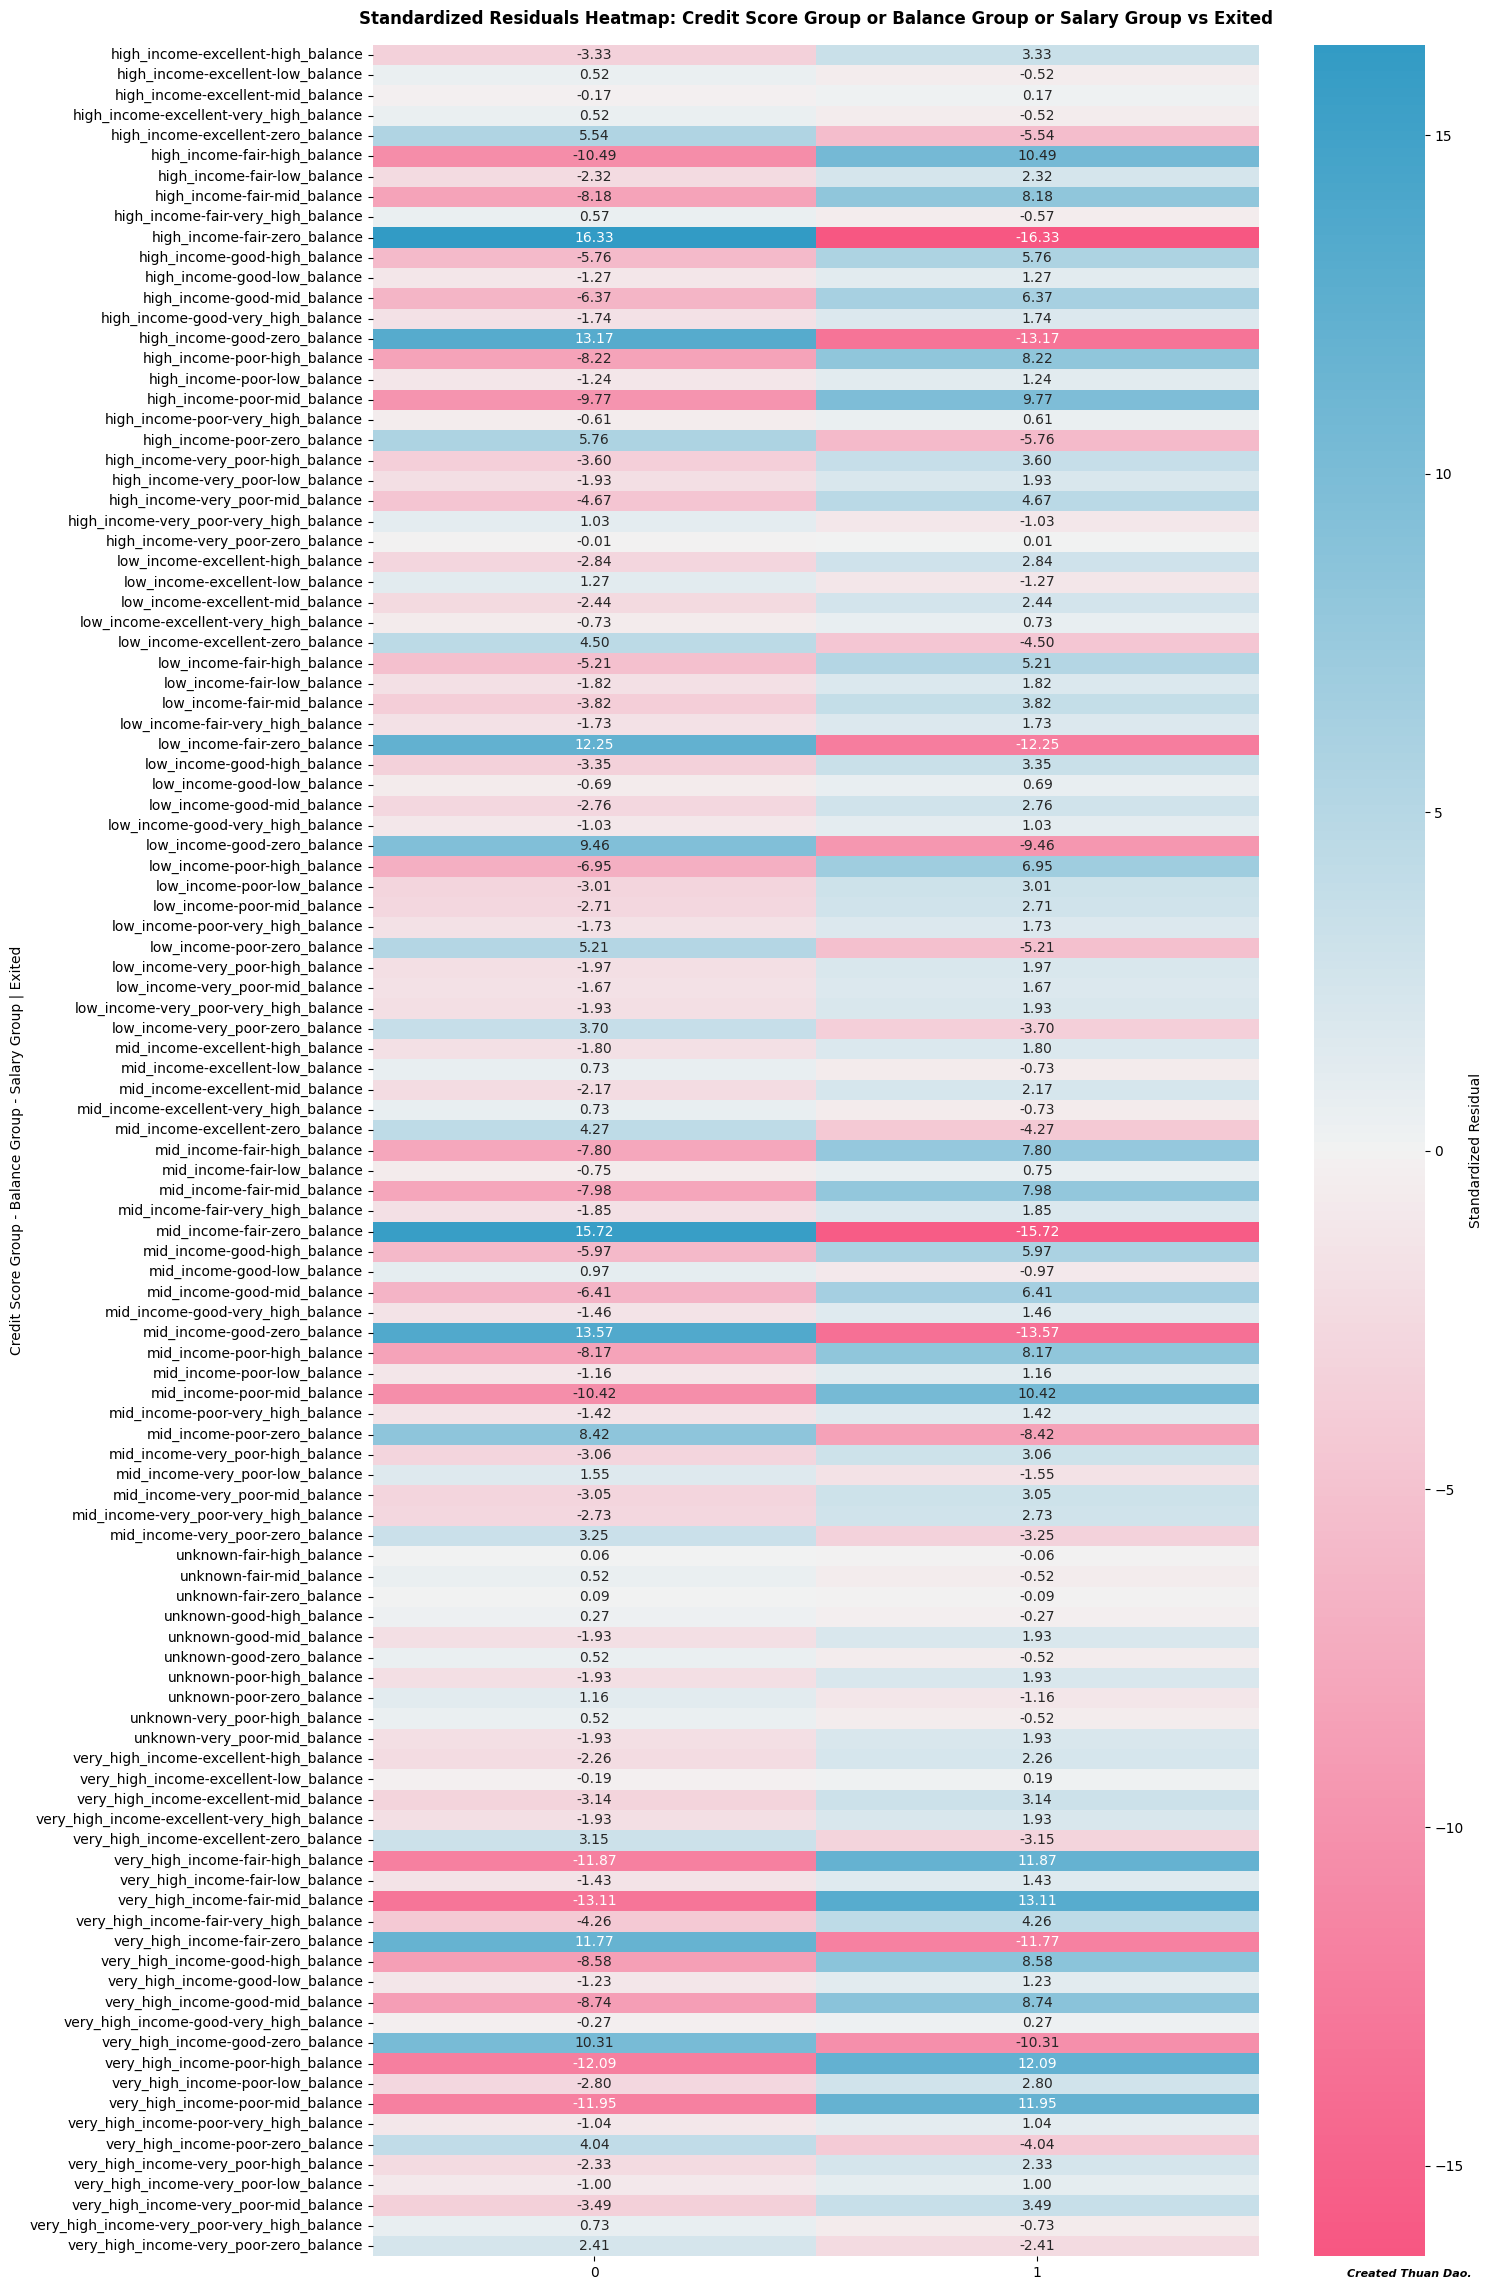

In [195]:
def salary_group(x):
    if 11.58 <= x <= 50000:
        return "low_income"
    elif 50000 < x <= 100000:
        return "mid_income"
    elif 100000 < x <= 150000:
        return "high_income"
    elif 150000 < x <= 199992.48:
        return "very_high_income"
    else:
        return "unknown"
df_customer_churnma["salary_group"] = df_customer_churnma["EstimatedSalary"].apply(salary_group)

print("[i] Computing percentage table by Credit Score Group × Balance Group × Salary Group...")
df_group = pd.crosstab(
    [df_customer_churnma["salary_group"], df_customer_churnma["credit_score_group"], df_customer_churnma["balance_group"]],
    df_customer_churnma["Exited"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Credit Score Group × Balance Group × Salary Group) vs Exited...")
contingency = pd.crosstab(
    [df_customer_churnma["salary_group"], df_customer_churnma["credit_score_group"], df_customer_churnma["balance_group"]],
    df_customer_churnma["Exited"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom
std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,23))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Credit Score Group or Balance Group or Salary Group vs Exited", 
          weight="bold", fontsize=12, pad=15)
plt.ylabel("Credit Score Group - Balance Group - Salary Group | Exited")
plt.xlabel("")
plt.text(2.2,110, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Analysis:**

***EstimatedSalary does not directly explain churn, but it interacts with Balance and CreditScore in ways that create meaningful patterns. High-income customers churn more when they also hold high balances, suggesting they are more sensitive to competing financial offers. Low-income customers churn more when paired with low credit scores or low balances. Salary alone is weak, but its interaction with financial indicators amplifies churn behavior.***

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>


## Feature Engineering

In [196]:
# Credit Utilization
df_train_combined["CreditUtilization"] = df_train_combined["Balance"] / df_train_combined["EstimatedSalary"]
df_test["CreditUtilization"] = df_test["Balance"] / df_test["EstimatedSalary"]

# CreditScore per Age
df_train_combined["CreditScorePerAge"] = df_train_combined["CreditScore"] / df_train_combined["Age"]
df_test["CreditScorePerAge"] = df_test["CreditScore"] / df_test["Age"]

# HighBalance_Inactive
bal_median_train = df_train_combined["Balance"].median()
bal_median_test = df_test["Balance"].median()
df_train_combined["HighBalance_Inactive"] = ((df_train_combined["Balance"] >= bal_median_train) & (df_train_combined["IsActiveMember"] == 0)).astype(int)
df_test["HighBalance_Inactive"] = ((df_test["Balance"] >= bal_median_test) & (df_test["IsActiveMember"] == 0)).astype(int)

,Exited,Count,Mean,Median,Std
0,1,36959,2.761059,0.688933,103.968155
1,0,138073,2.052975,0.000000,89.414650



[i] Checking normality of feature 'CreditUtilization' by groups of 'Exited'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


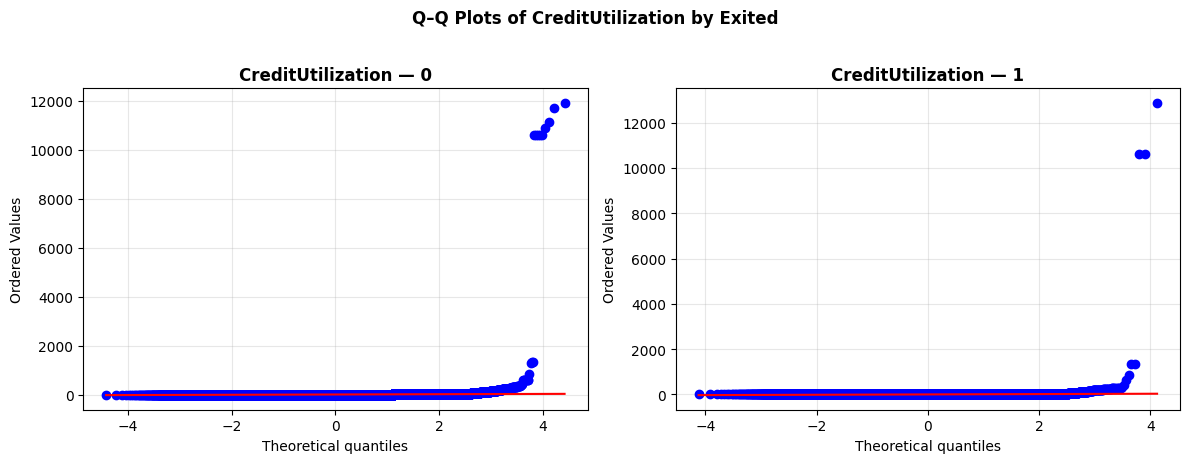

,Feature,Group,Skewness,Kurtosis,Remark
0,CreditUtilization,0,120.9196,14896.5850,"Highly skewed, Heavy/light tails"
1,CreditUtilization,1,108.9156,12208.0996,"Highly skewed, Heavy/light tails"


[!] At least one group deviates from normality.
[i] Non-normal distribution detected → Consider Kruskal–Wallis or Mann–Whitney U test.

[i] Running Mann–Whitney U Test: 'CreditUtilization' by 'Exited'...
[i] U statistic: 2151989249.5
[i] p-value    : 0.000000

[✓] Significant difference detected between the two groups (Reject H0).
[i] Median of group '0': 0.0000
[i] Median of group '1': 0.6889
[i] Interpretation: Group '1' has a higher median 'CreditUtilization'.


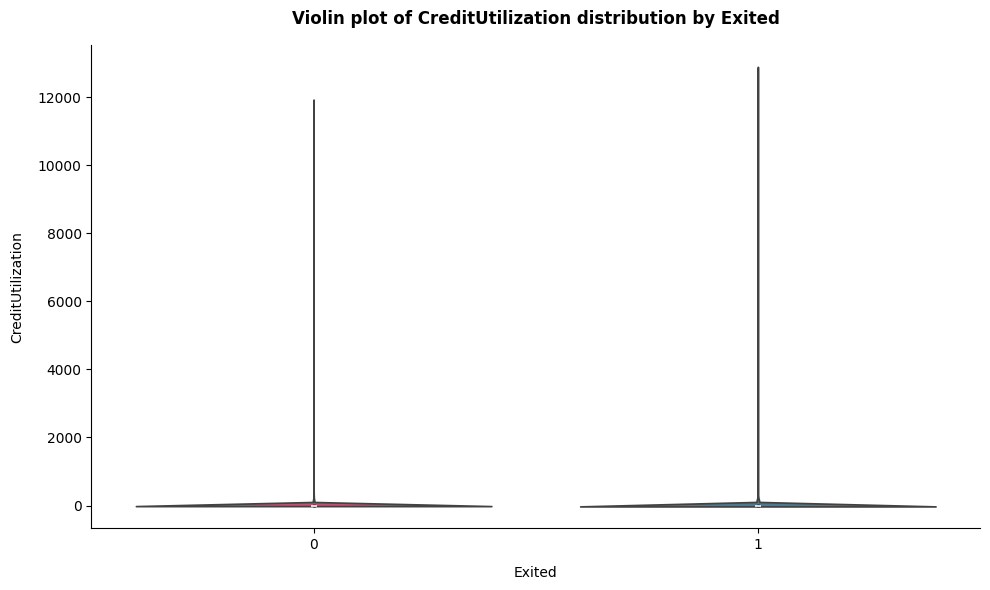

In [197]:
display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of CreditUtilization by Exited</b></h2>"))
plot_numerical_distribution(feature="CreditUtilization", df=df_train_combined)

,Exited,Count,Mean,Median,Std
0,0,138073,18.788496,18.384615,4.598192
1,1,36959,15.513114,14.829787,4.116993



[i] Checking normality of feature 'CreditScorePerAge' by groups of 'Exited'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


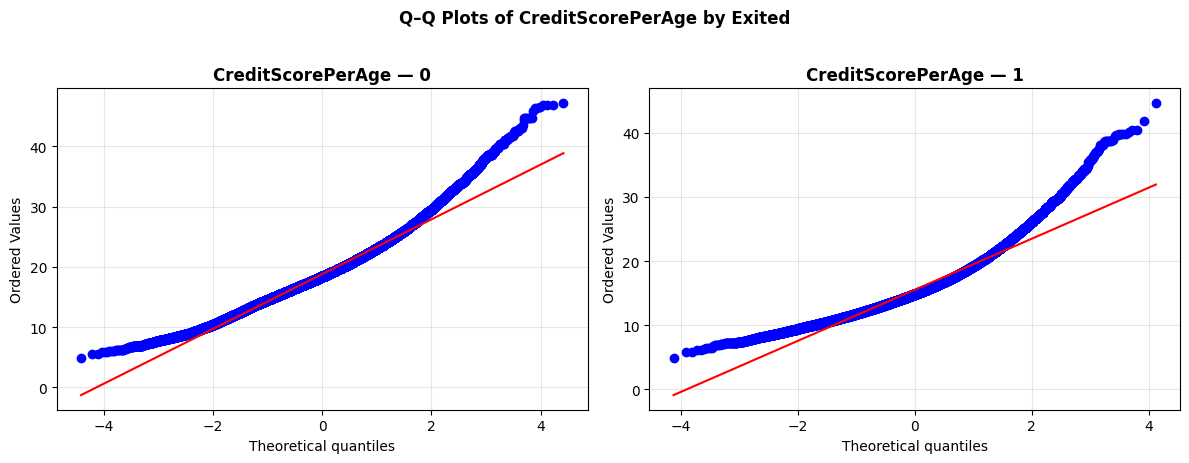

,Feature,Group,Skewness,Kurtosis,Remark
0,CreditScorePerAge,0,0.6435,1.2079,"Moderately skewed, Normal tails"
1,CreditScorePerAge,1,1.2121,2.5880,"Highly skewed, Heavy/light tails"


[!] At least one group deviates from normality.
[i] Non-normal distribution detected → Consider Kruskal–Wallis or Mann–Whitney U test.

[i] Running Mann–Whitney U Test: 'CreditScorePerAge' by 'Exited'...
[i] U statistic: 3688749532.5
[i] p-value    : 0.000000

[✓] Significant difference detected between the two groups (Reject H0).
[i] Median of group '0': 18.3846
[i] Median of group '1': 14.8298
[i] Interpretation: Group '0' has a higher median 'CreditScorePerAge'.


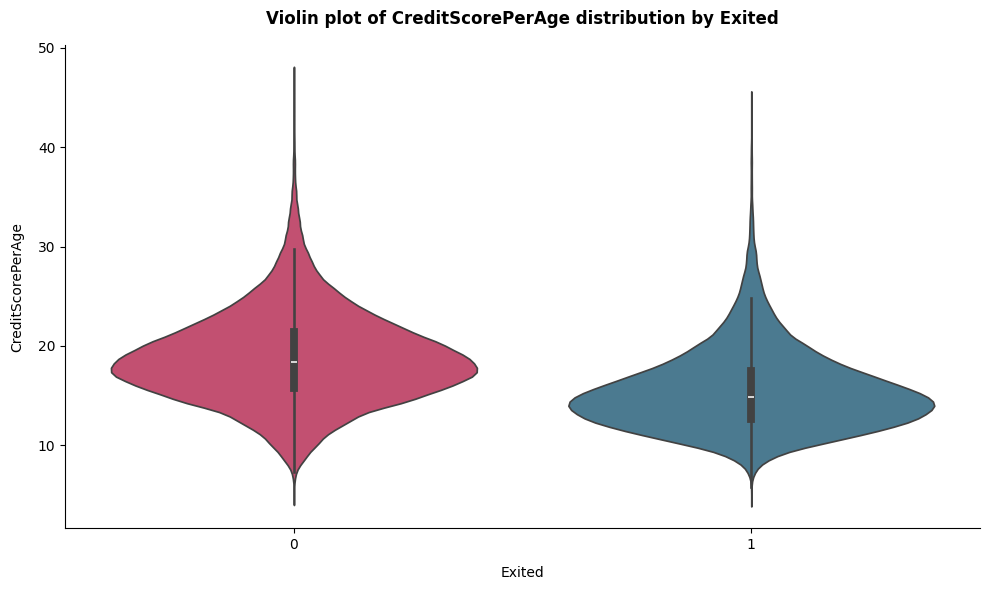

In [198]:
display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of CreditScorePerAge by Exited</b></h2>"))
plot_numerical_distribution(feature="CreditScorePerAge", df=df_train_combined)

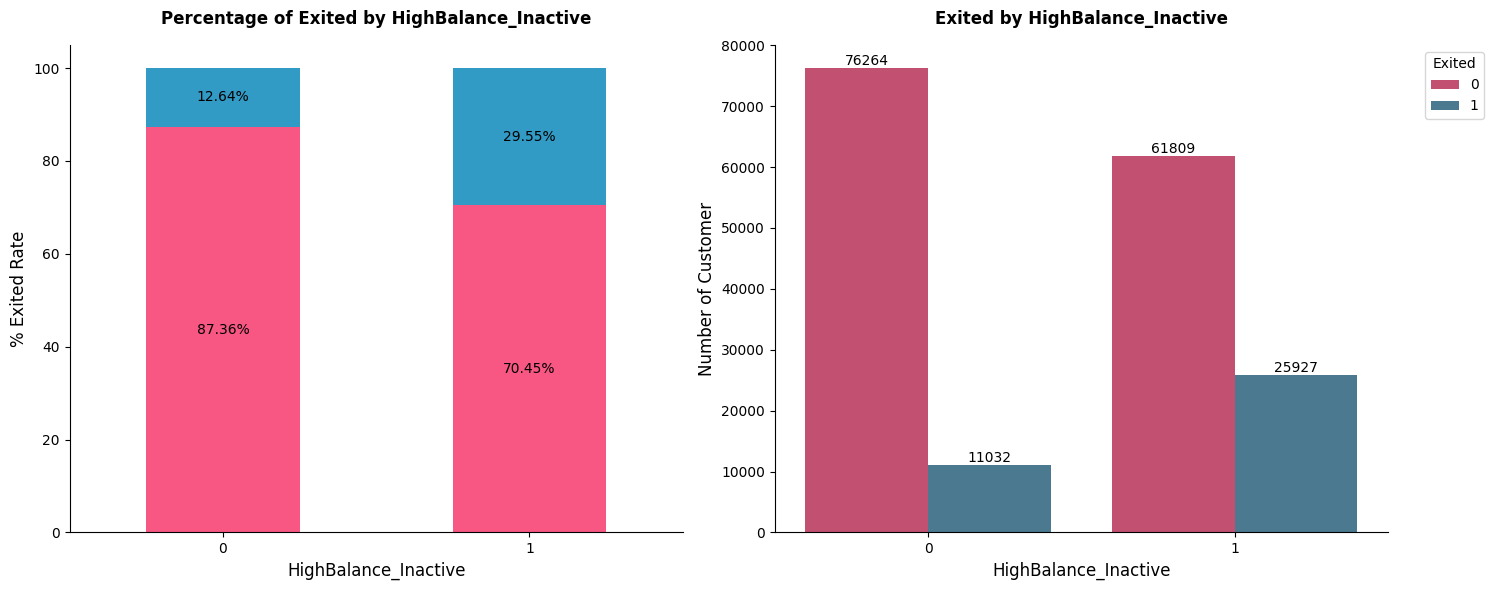


[i] Chi-Square Test of Independence: 'HighBalance_Inactive' vs. 'Exited'...
[i] Chi-squared statistic: 7514.130
[i] Degrees of freedom: 1
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'HighBalance_Inactive' and 'Exited' are statistically associated.

[i] Standardized Residuals:
Exited                    0      1
HighBalance_Inactive              
0                     28.20 -54.51
1                    -28.13  54.38


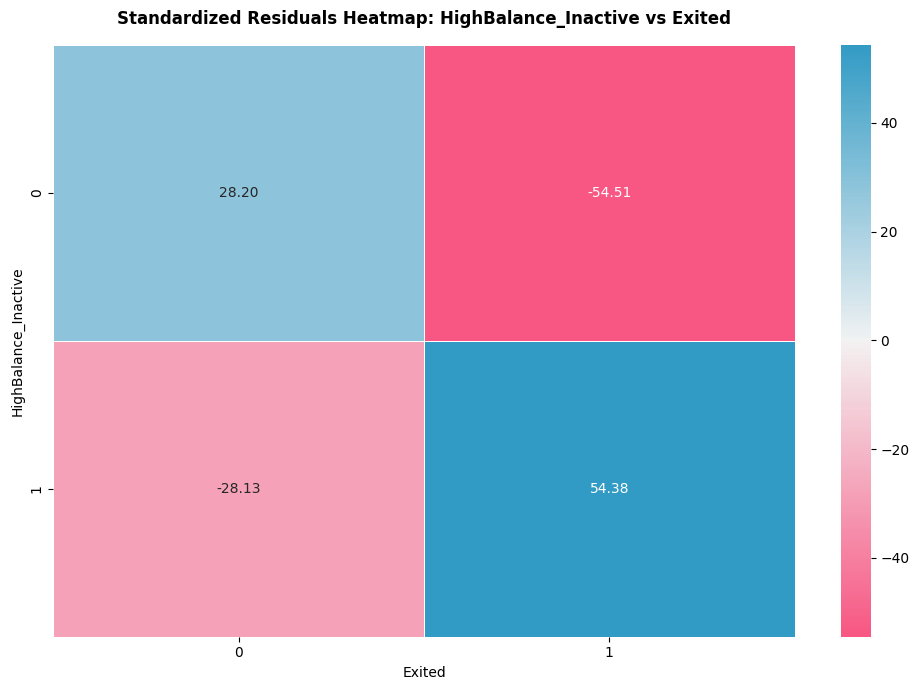

In [199]:
bivariate_percent_plot(cat="HighBalance_Inactive", df=df_train_combined)

**Analysis:**

**CreditUtilization**

* Churned customers have **much higher credit utilization** (median 0.689 vs. 0), indicating they rely more heavily on credit.

**CreditScorePerAge**

* The retained group shows **higher CreditScorePerAge**, suggesting better creditworthiness relative to age among non-churners.

**HighBalance_Inactive**

* Customers who are **both high-balance and inactive** exhibit **significantly higher churn**, confirming this as a high-risk segment.

### Overall Picture (After feature engineering)

| Feature                  | Summary                                                                                                 |
| ------------------------ | ------------------------------------------------------------------------------------------------------- |
| **Geography**            | Customers from **Germany** are more likely to churn, **France** and **Spain** less likely to churn.     |
| **Gender**               | **Female** customers have a higher churn rate than males.                                               |
| **HasCrCard**            | Customers **without a credit card** churn more than expected, those **with** churn less.                |
| **IsActiveMember**       | **Inactive** customers are more likely to churn.                                                        |
| **NumOfProducts**        | Customers with **1, 3, or 4 products** have higher-than-expected churn.                                 |
| **HighBalance_Inactive** | Customers with **high account balances but inactive status** churn at a much higher rate than expected. |
| **CreditScore**          | Non-churned customers have slightly **higher median credit scores** (653 vs. 646).                      |
| **CreditUtilization**    | Churned customers have a **higher median credit utilization** (0.689 vs. 0).                            |
| **CreditScorePerAge**    | Non-churned customers have a **higher median CreditScorePerAge** than churned customers.                |
| **Age**                  | Churned customers tend to be **older** (median 45 vs. 36).                                              |
| **Balance**              | Churned customers have a **notably higher median balance** (109,344 vs. 92,063).                        |
| **Tenure**               | The distribution of Tenure between the two groups **differs significantly**.                            |
| **EstimatedSalary**      | The churn group has a **higher median estimated salary**.                                               |


## Handling Skewness

In [200]:
num_features = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary", "CreditUtilization", "CreditScorePerAge"]
skew_feature_train, skew_train_df = check_skewness(data=df_train_combined, dataset_name="Train Data",
                                                   numerical_features=num_features)


[i] Skewness for Train Data...
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
CreditUtilization              | +118.1294 | Highly skewed
Age                            |   +0.9799 | Moderately skewed
CreditScorePerAge              |   +0.6830 | Moderately skewed
Balance                        |   +0.3506 | Approximately symmetric
EstimatedSalary                |   -0.2950 | Approximately symmetric
CreditScore                    |   -0.0660 | Approximately symmetric
Tenure                         |   +0.0067 | Approximately symmetric
----------------------------------------------------------------------


In [201]:
skew_feature_test, skew_test_df = check_skewness(data=df_test, dataset_name="Test Data",
                                                 numerical_features=num_features)


[i] Skewness for Test Data...
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
CreditUtilization              | +119.4261 | Highly skewed
Age                            |   +0.9724 | Moderately skewed
CreditScorePerAge              |   +0.6891 | Moderately skewed
Balance                        |   +0.3852 | Approximately symmetric
EstimatedSalary                |   -0.3053 | Approximately symmetric
CreditScore                    |   -0.0624 | Approximately symmetric
Tenure                         |   +0.0213 | Approximately symmetric
----------------------------------------------------------------------


In [202]:
from sklearn.preprocessing import PowerTransformer

def handle_skewed_features(
    df,
    zero_threshold=0.9,
    skew_threshold=0.5,
    num_features=None,
    exclude_cols=None
):
    """
    Handle skewed numerical features by applying appropriate transformations.

    Parameters:
    - df: pandas.DataFrame
    - zero_threshold: float (default=0.9)
    - skew_threshold: float (default=0.5)
    - num_features: list of numerical columns to consider
    - exclude_cols: list of columns to skip entirely

    Returns:
    - df: transformed DataFrame
    - transformed_cols: list of new feature names
    - high_zero_cols: list of sparse features (> zero_threshold)
    - skewed_cols: list of auto‑detected skewed features
    """
    df = df.copy()
    if num_features is None:
        raise ValueError("`num_features` must be provided")
    if exclude_cols is None:
        exclude_cols = []

    # 1) pick the numeric cols to scan
    numerical_cols = [c for c in num_features if c not in exclude_cols]

    # 2) detect ultra‑sparse
    zero_ratios = (df[numerical_cols] == 0).sum() / len(df)
    high_zero_cols = zero_ratios[zero_ratios > zero_threshold].index.tolist()

    # 3) compute skew
    skew_vals = df[numerical_cols].apply(lambda s: skew(s.dropna()))
    auto_skewed = skew_vals[abs(skew_vals) > skew_threshold].index.tolist()

    # 4) union these with your forced list
    to_transform = list(set(auto_skewed))

    transformed_cols = []
    dropped_cols     = []

    for col in to_transform:
        # if it's sparse → binary+log
        if col in high_zero_cols:
            df[f"Has_{col}"] = (df[col] > 0).astype(int)
            df[f"Log_{col}"] = df[col].map(lambda x: np.log1p(x) if x > 0 else 0)
            transformed_cols += [f"Has_{col}", f"Log_{col}"]
            dropped_cols.append(col)
        # if it's discrete small‑cardinality, skip transform but keep
        elif df[col].nunique() <= 5:
            # do nothing (we still keep raw col in df)
            continue
        # otherwise apply Yeo‑Johnson
        else:
            pt = PowerTransformer(method="yeo-johnson")
            arr = df[[col]].values  # shape (n,1)
            df[f"PT_{col}"] = pt.fit_transform(arr)
            transformed_cols.append(f"PT_{col}")
            dropped_cols.append(col)

    # drop originals for any column we did transform
    df.drop(columns=dropped_cols, inplace=True)

    return df, transformed_cols, high_zero_cols, auto_skewed

In [203]:
processed_train_df, transformed_columns, sparse_columns, skewed_columns = handle_skewed_features(df=df_train_combined, num_features=skew_feature_train)
num_features = ["CreditScore", "PT_Age", "Tenure", "Balance", "EstimatedSalary", "PT_CreditUtilization", "PT_CreditScorePerAge"]
skew_feature_train, skew_train_df = check_skewness(data=processed_train_df, dataset_name="Train Data", numerical_features=num_features)


[i] Skewness for Train Data...
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
PT_CreditUtilization           |   +0.4112 | Approximately symmetric
Balance                        |   +0.3506 | Approximately symmetric
EstimatedSalary                |   -0.2950 | Approximately symmetric
CreditScore                    |   -0.0660 | Approximately symmetric
Tenure                         |   +0.0067 | Approximately symmetric
PT_Age                         |   -0.0061 | Approximately symmetric
PT_CreditScorePerAge           |   +0.0024 | Approximately symmetric
----------------------------------------------------------------------


In [204]:
processed_test_df, transformed_columns_test, sparse_columns_test, skewed_columns_test = handle_skewed_features(df=df_test, num_features=skew_feature_test)
skew_feature_test, skew_test_df = check_skewness(data=processed_test_df, numerical_features=num_features, dataset_name= "Test data")


[i] Skewness for Test data...
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
PT_CreditUtilization           |   +0.4306 | Approximately symmetric
Balance                        |   +0.3852 | Approximately symmetric
EstimatedSalary                |   -0.3053 | Approximately symmetric
CreditScore                    |   -0.0624 | Approximately symmetric
Tenure                         |   +0.0213 | Approximately symmetric
PT_Age                         |   -0.0063 | Approximately symmetric
PT_CreditScorePerAge           |   +0.0026 | Approximately symmetric
----------------------------------------------------------------------


**Observations from the Skewness Table (`processed_combined_df` and `processed_test_df`):**

**Skewed**:

* The features `CreditUtilization`, `CreditScorePerAge`, `Age` exhibit skewness.

**Approximately Symmetric**:

* Several features, such as:

  * `PT_CreditScorePerAge `, `PT_Age` and `PT_CreditUtilization` close to zero.
  * This indicates that **Yeo-Johnson transformation was effective** for this feature.

## Re-check Outlier

In [205]:
checking_outlier(list_feature=num_features, df=processed_train_df, dataset_name="Training data")

[i] Checking for outliers in Training data...


,Feature,Outlier Count
0,CreditScore,331
1,PT_Age,3511
2,PT_CreditScorePerAge,2028


In [206]:
checking_outlier(list_feature=num_features, df=processed_test_df, dataset_name="Test data")

[i] Checking for outliers in Test data...


,Feature,Outlier Count
0,CreditScore,176
1,PT_Age,2091
2,PT_CreditScorePerAge,1321


**Insight**

***Both the training and test datasets contain outliers in four features: `CreditScore`, `PT_Age`, `PT_CreditScorePerAge`. We will use RobustScaler to reduce the impact of these outliers.***

## Create Test Set

Suppose we chatted with experts who told us that the **EstimatedSalary** is a very important attribute to predict **Exited**. We may want to ensure that the test set is representative of the various categories of **EstimatedSalary** in the whole dataset. Since the **EstimatedSalary** is a continuous numerical attribute, we first need to create an category attribute.

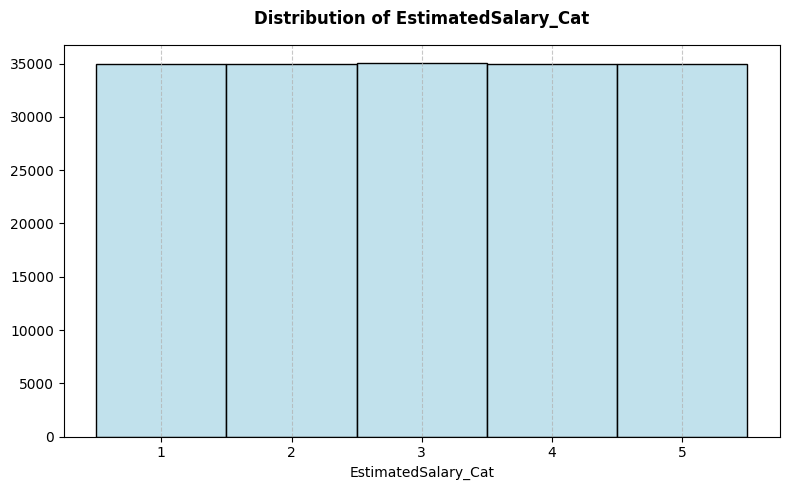

In [208]:
processed_train_df["EstimatedSalary_Cat"] = pd.qcut(processed_train_df["EstimatedSalary"],
                                              q=5,
                                              labels=[1, 2, 3, 4, 5])

plt.figure(figsize=(8, 5))
sns.histplot(data=processed_train_df, x="EstimatedSalary_Cat", color="lightblue", edgecolor="black")

plt.title("Distribution of EstimatedSalary_Cat", fontsize=12, pad=15, weight="bold")
plt.xlabel("EstimatedSalary_Cat")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [210]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(processed_train_df, processed_train_df["EstimatedSalary_Cat"]):
    start_train_set = processed_train_df.iloc[train_index]
    start_test_set = processed_train_df.iloc[test_index]\

# Now we should remove the EstimatedSalary_Cat attribute so the data is back to its original state:
for set_ in (start_train_set, start_test_set): 
    set_.drop("EstimatedSalary_Cat", axis=1, inplace=True)

df_train_new = start_train_set.drop("Exited", axis=1)
df_train_label = start_train_set["Exited"].copy()

## Scale and Ecode

In [211]:
# Define feature groups
# Numerical features with outliers → use RobustScaler
list_feature_num_robust = ["CreditScore", "PT_Age", "PT_CreditScorePerAge"]
# Numerical features with standard distribution → use StandardScaler
list_feature_num_stand = ["Tenure", "Balance", "EstimatedSalary", "PT_CreditUtilization"]
# Categorical features that need One-Hot Encoding
list_feature_cat_onehot = ["Geography", "Gender", "NumOfProducts"]
# Binary/low-cardinality categorical features → keep as-is (no one-hot)
list_feature_cat_keep = ["HasCrCard", "IsActiveMember", "HighBalance_Inactive"]

# Define transformers
# Robust scaling for outlier-prone numeric features
num_robust_transformer = Pipeline(steps=[
    ("scaler", RobustScaler()),
    ("imputer", SimpleImputer(strategy="median"))
])
# Standard scaling for normally distributed numeric features
num_stand_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("imputer", SimpleImputer(strategy="median"))
])
# One-hot encoding for multi-category categorical features
cat_onehot_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ("imputer", SimpleImputer(strategy="most_frequent"))
])
# Keep binary/boolean categorical features (1/0) without encoding
cat_keep_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Build ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num_robust", num_robust_transformer, list_feature_num_robust),
    ("num_standard", num_stand_transformer, list_feature_num_stand),
    ("cat_onehot", cat_onehot_transformer, list_feature_cat_onehot),
    ("cat_keep", cat_keep_transformer, list_feature_cat_keep),
])

# Fit the preprocessing pipeline
preprocessor.fit(df_train_new)
# Transform training data
df_train_new_prepared = preprocessor.transform(df_train_new)
# Extract clean feature names
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
# Clean prefix names for readability
clean_features = [
    col.replace("num_standard__", "")
       .replace("num_robust__", "")
       .replace("cat_onehot__", "")
       .replace("cat_keep__", "")
       .replace("PT_", "") 
    for col in list_feature_prepared
]

clean_features

['CreditScore',
 'Age',
 'CreditScorePerAge',
 'Tenure',
 'Balance',
 'EstimatedSalary',
 'CreditUtilization',
 'cat_onehot__Geography_France',
 'cat_onehot__Geography_Germany',
 'cat_onehot__Geography_Spain',
 'cat_onehot__Gender_Female',
 'cat_onehot__Gender_Male',
 'cat_onehot__NumOfProducts_1',
 'cat_onehot__NumOfProducts_2',
 'cat_onehot__NumOfProducts_3',
 'cat_onehot__NumOfProducts_4',
 'cat_keep__HasCrCard',
 'cat_keep__IsActiveMember',
 'cat_keep__HighBalance_Inactive']

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Metric</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Metric
    </h1>
</div>


**AUC-ROC Overview**

**AUC-ROC** evaluates a model’s ability to **distinguish between two classes**.

* **ROC curve** plots **TPR vs FPR**
* **AUC** = Area under ROC curve → **ranking quality of predictions**

**Why AUC-ROC?**

* Robust to **class imbalance**
* Measures **ranking ability**, not fixed threshold (0.5)
* Common metric in **credit risk & fraud prediction**

> Higher AUC → better separation between *Paid* vs *Default*

**Interpretation**

| AUC Score     | Meaning                  |
| ------------- | ------------------------ |
| **1.0**       | Perfect model            |
| **0.9+**      | Excellent discrimination |
| **0.7 – 0.9** | Good                     |
| **0.5**       | Random guessing          |
| **< 0.5**     | Worse than random        |

(Source: [ROC AUC](https://en.wikipedia.org/wiki/Receiver_operating_characteristic))

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>

## Class Imbalance Handling

- The dataset has ~80% 'Not Churned' in the target, so models may be biased toward the majority class.
- To mitigate this, we explicitly calculate a **`scale_pos_weight`** to emphasize the minority class (Introverts) during training:

**Breakdown of Class Imbalance Calculation**

| Line                                   | What It Does     | Why It's Useful                      |
| -------------------------------------- | ---------------- | ------------------------------------ |
| `class_1 = df_train_label_new.sum()`                    | Count of class 1 | Needed for imbalance calculation     |
| `class_0 = len(df_train_label_new) - class_1`           | Count of class 0 | Complement of class 1                |
| `scale_pos_weight = class_0 / class_1` | Weight factor    | Penalizes minority class errors more |

**Class Imbalance Strategies by Model**

- We instantiate five high-performance gradient boosting models, each tuned using Optuna and configured to handle class imbalance natively.

| Model                            | Class Imbalance Handling                   |
| -------------------------------- | ------------------------------------------ |
| `CatBoostClassifier`             | `class_weights={1: scale_pos_weight}`       |
| `LGBMClassifier`          | `class_weight={0: 1, 1: scale_pos_weight}` |
| `XGBClassifier`           | `scale_pos_weight=scale_pos_weight`        |
| `HistGradientBoostingClassifier` | `class_weight="balanced"`                  |

- These configurations ensure that each model gives proportional attention to both personality classes.

In [215]:
class_1 = df_train_label.sum()
class_0 = len(df_train_label) - class_1
scale_pos_weight = class_0 / class_1

In [218]:
def shap_plot(model, X_test, list_feature, type = None):
     # https://towardsdatascience.com/using-shap-values-to-explain-how-your-machine-learning-model-works-732b3f40e137/
    if hasattr(X_test, "toarray"):
        X_test = X_test.toarray()
    X_test_sample = pd.DataFrame(X_test, columns=list_feature)
    explainer = shap.Explainer(model.predict, X_test_sample)
    shap_values = explainer(X_test_sample)
    if type =="bar":
        shap_importance = np.abs(shap_values.values).mean(axis=0)
        shap_df = pd.DataFrame({"feature": X_test_sample.columns, "importance": shap_importance})
        shap_df = shap_df.sort_values("importance", ascending=False).head(20)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=shap_df["importance"], y=shap_df["feature"], palette="viridis", order=shap_df["feature"])
        plt.xlabel("mean(|SHAP value|)")
        plt.title("SHAP Feature Importance", fontsize=14, weight="bold", pad=20)
        plt.tight_layout()
        plt.show()
    else:
        shap.summary_plot(shap_values, X_test_sample)

In [219]:
def run_oof(model, X, y, X_test, n_splits=Config.n_split_kfold):
    print(f"[i] Starting OOF training with {model.__class__.__name__}...")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    oof_pred = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    fold_models = []
    fold_auc = []

    # For plotting
    roc_curves = []
    pr_curves = []
    auc_values = []
    ap_values = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        print(f"\n[i] Fold {fold+1}/{n_splits}...")

        X_train, X_valid = X[train_idx], X[valid_idx]
        y_train, y_valid = y[train_idx], y[valid_idx]

        if "LGBMClassifier" == model.__class__.__name__:
            model.fit(
                X_train, y_train,
                eval_set=[(X_valid, y_valid)],
                # verbose=False,
                # early_stopping_rounds=300
            )
        else:
            model.fit(
                X_train, y_train,
                eval_set=[(X_valid, y_valid)],
                verbose=False,
                early_stopping_rounds=300
            )        

        fold_models.append(model)

        # Predict fold
        if "CatBoostClassifier" == model.__class__.__name__:
            fold_pred = model.predict_proba(
                X_valid,
                ntree_end=model.best_iteration_
            )[:, 1]
        elif "LGBMClassifier" == model.__class__.__name__:
            fold_pred = model.predict_proba(
                X_valid,
                num_iteration=model.best_iteration_
            )[:, 1]
        elif "XGBClassifier" == model.__class__.__name__:
            fold_pred = model.predict_proba(
                X_valid,
                iteration_range=(0, model.best_iteration + 1)
            )[:, 1]
        else:
            fold_pred = model.predict_proba(X_valid)[:, 1]

        oof_pred[valid_idx] = fold_pred

        # Test prediction
        if "CatBoostClassifier" == model.__class__.__name__:
            test_pred += model.predict_proba(
                X_test,
                ntree_end=model.best_iteration_
            )[:, 1] / n_splits
        elif "LGBMClassifier" == model.__class__.__name__:
            test_pred += model.predict_proba(
                X_test,
                num_iteration=model.best_iteration_
            )[:, 1] / n_splits
        elif "XGBClassifier" == model.__class__.__name__:
            test_pred += model.predict_proba(
                X_test,
                iteration_range=(0, model.best_iteration + 1)
            )[:, 1] / n_splits
        else:
            fold_pred = model.predict_proba(X_test)[:, 1]

        # === Compute AUC for the fold ===
        auc_fold = roc_auc_score(y_valid, fold_pred)
        fold_auc.append(auc_fold)
        print(f"[✓] Fold {fold+1} - AUC: {auc_fold:.5f}")

        # === ROC curve by fold ===
        fpr, tpr, _ = roc_curve(y_valid, fold_pred)
        roc_curves.append((fpr, tpr))

        # === Precision–Recall curve by fold ===
        precision, recall, _ = precision_recall_curve(y_valid, fold_pred)
        pr_curves.append((recall, precision))

        # Average Precision for fold
        ap = average_precision_score(y_valid, fold_pred)
        ap_values.append(ap)

    # Final OOF AUC
    oof_auc = roc_auc_score(y, oof_pred)
    print("\n==========================")
    print(f"[i] OOF AUC: {oof_auc:.5f}")
    print(f"[✓] Fold AUCs: {fold_auc}")
    print("==========================\n")

    # 3 SUBPLOTS: ROC, PR, CONF MATRIX

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # ------------------------ ROC Curve ------------------------
    ax = axes[0, 0]
    for i, (fpr, tpr) in enumerate(roc_curves):
        ax.plot(fpr, tpr, label=f"Fold {i+1} AUC = {fold_auc[i]:.4f}")

    ax.plot([0,1], [0,1], "--", color="gray")
    ax.set_title("ROC Curve (Each Fold)", pad=15, weight="bold", fontsize=12)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(True)

    # --------------------- PR Curve ---------------------------
    ax = axes[0, 1]
    for i, (recall, precision) in enumerate(pr_curves):
        ax.plot(recall, precision, label=f"Fold {i+1} AP = {ap_values[i]:.4f}")

    ax.set_title("Precision–Recall Curve (Each Fold)", pad=15, weight="bold", fontsize=12)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.grid(True)

    # --------------------- Confusion Matrix --------------------
    ax = axes[1, 0]
    threshold = 0.5
    y_pred_label = (oof_pred >= threshold).astype(int)
    cm = confusion_matrix(y, y_pred_label)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix (Threshold = 0.5)", pad=15, weight="bold", fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax = axes[1, 1]
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    return oof_pred, test_pred, fold_models

In [220]:
X_val = start_test_set.drop("Exited", axis=1)
y_val = start_test_set["Exited"].copy()
X_val_prepared = preprocessor.transform(X_val)

## CatBoostClassifier

In [ ]:
from catboost import CatBoostClassifier
param_cb = {
"bootstrap_type": "Bernoulli",
"colsample_bylevel": 0.7658926065030167,
"iterations": 1984,
"depth": 5,
"learning_rate": 0.015171349611571652,
"l2_leaf_reg": 1.337578073889382,
"min_data_in_leaf": 76,
"subsample": 0.7280698256173038,
"eval_metric": "AUC",
"class_weights": [1, scale_pos_weight],
"verbose": False,
"random_seed": Config.seed,
"loss_function": "Logloss",
"allow_writing_files": False,
"thread_count": -1,
"grow_policy": "Lossguide",
"task_type": "GPU",
"devices": "0"
}

model_cb = CatBoostClassifier(**param_cb)
df_test_prepared = preprocessor.transform(processed_test_df)
oof_pred_cb, test_pred_cb, fold_models_cb = run_oof(model = model_cb, X = df_train_new_prepared, y = df_train_label.values, 
                                                    X_test = df_test_prepared)

## XGBClassifier

In [ ]:
from xgboost import XGBClassifier
param_xgb = {
"n_estimators": 1637,
"learning_rate": 0.013448370696239944,
"max_depth": 5,
"min_child_weight": 0.03159892617906292,
"subsample": 0.7185805327584004,
"colsample_bytree": 0.6611176553575923,
"gamma": 5.256647828620208,
"reg_alpha": 1.8881089265623683e-07,
"reg_lambda": 3.3879565314300123e-07,
"n_jobs": -1,
"random_state": seed,
"scale_pos_weight": scale_pos_weight,
"objective": "binary:logistic",
"eval_metric": "auc"
}

model_xgb = XGBClassifier(**param_xgb)
model_xgb

In [ ]:
rocScore_xgb = evaluate_model(model = model_xgb, X_train=df_train_new_prepared, X_val=X_val_prepared,
                               y_train=df_train_label_new, y_val=y_val, figsize=(15, 10))

## LGBMClassifier

In [ ]:
from lightgbm import LGBMClassifier

param_lgbm = {
"n_estimators": 1530,
"learning_rate": 0.0030804807162494864,
"num_leaves": 345,
"max_depth": 5,
"min_child_samples": 62,
"min_split_gain": 0.6369464169580782,
"feature_fraction": 0.7846216887053435,
"bagging_fraction": 0.7647361784813704,
"reg_alpha": 0.3212093236745268,
"reg_lambda": 0.0006563052961663804,
"max_bin": 243,
"bagging_freq": 7,
"objective": "binary",
"metric": "AUC",
"random_state": seed,
"n_jobs": -1,
"verbosity": -1
}

model_lgbm = LGBMClassifier(**param_lgbm)
model_lgbm

In [ ]:
rocScore_lgbm = evaluate_model(model = model_lgbm, X_train=df_train_new_prepared, X_val=X_val_prepared,
                               y_train=df_train_label_new, y_val=y_val, figsize=(15, 10))

## HistGradientBoostingClassifier

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

param_hgb = {
"learning_rate": 0.0323356329876002,
"max_iter": max_iter,
"max_leaf_nodes": 15,
"min_samples_leaf": 254,
"l2_regularization": 0.00011009865934208523,
"max_bins": 117,
"early_stopping": True,
"validation_fraction": 0.1,
"random_state": seed,
"verbose": 0,
"class_weight": "balanced",
"loss": "log_loss"
}

model_hgb = HistGradientBoostingClassifier(**param_hgb)
model_hgb

In [ ]:
rocScore_hgb = evaluate_model(model = model_hgb, X_train=df_train_new_prepared, X_val=X_val_prepared,
                               y_train=df_train_label_new, y_val=y_val, figsize=(15, 10))

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Prepare Final Submission File</span>

<div style="
    border-radius: 15px;
    border: 2px solid #2e7d32;
    padding: 20px;
    background: linear-gradient(125deg, #1b5e20 5%, #43a047 40%, #81c784 75%, #c8e6c9 100%);
    text-align: center;
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Prepare Final Submission File
    </h1>
</div>

In [ ]:
from sklearn.ensemble import VotingClassifier
voting_clf_soft = VotingClassifier(
    estimators=[
        ("cb", model_cb),
        ("xgb", model_xgb),
        ("lgbm", model_lgbm),
        ("hgb", model_hgb)
    ],
    voting="soft",
    weights=[rocScore_cat, rocScore_xgb, rocScore_lgbm, rocScore_hgb],
    n_jobs=-1
)

In [ ]:
df_test_prepared = preprocessor.transform(processed_test_df)

In [ ]:
rocScore_vc = evaluate_model(model = voting_clf_soft, X_train=df_train_new_prepared, X_val=X_val_prepared,
               y_train=df_train_label_new, y_val=y_val, figsize=(15, 10))

In [ ]:
# Generate predicted probabilities for the test set
y_pred_test_prob_cat = voting_clf_soft.predict_proba(df_test_prepared)
exited = y_pred_test_prob_cat[:, 1]

# Prepare submission file
submission = pd.DataFrame({
    "id": df_test.index,
    "Exited": exited
})

submission.to_csv("submission.csv", index=False)
print("\nSubmission file saved!")
submission.head()

In [ ]:
# Plot distribution of predicted probabilities
plt.figure(figsize=(10, 6))
sns.histplot(exited, bins=30, kde=True)
plt.title("Distribution of Predicted Exited Probabilities", weight="bold")
plt.xlabel("Predicted Probability of Exited")
sns.despine(left=False, bottom=False, right=False)
plt.ylabel("Frequency")
plt.xlim(0, 1)  # Limit x-axis to [0, 1]
plt.show()

In [ ]:
# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
binary_predictions = (exited > 0.5).astype(int)

# Plot distribution of binary predictions
plt.figure(figsize=(8, 5))
sns.countplot(x=binary_predictions.flatten(), palette= color(n_colors=2))
plt.title("Distribution of Predicted Exited", weight="bold")
plt.xlabel("Exited Status (0: Not churned, 1: Churned)")
plt.ylabel("")
sns.despine(left=False, bottom=False)
plt.xticks(ticks=[0, 1], labels=["Not churned", "Churned"])
plt.show()

In [ ]:
shap_plot(model=voting_clf_soft, X_test=df_test_prepared[:200], list_feature=list_feature_prepared, type="bar")

In [ ]:
shap_plot(model=voting_clf_soft, X_test=df_test_prepared[:200], list_feature=list_feature_prepared)

**Most important features**

From top to bottom — decreasing influence:

1. **cat\_onehot\_\_NumOfProducts\_2**

   * High values (red) → negative SHAP → reduce churn.
   * Low values (blue, meaning the customer doesn’t have 2 products) → positive SHAP → increase churn.
   * Meaning: Customers with **2 products** are less likely to leave.

2. **num\_robust\_\_PT\_Age**

   * Older customers (red) → positive SHAP → more likely to churn.
   * Younger customers (blue) → negative SHAP → less likely to churn.
   * Meaning: Older customers have a higher risk of leaving.

3. **cat\_onehot\_\_NumOfProducts\_1**

   * High values (red) → positive SHAP → increase churn.
   * Meaning: Customers with **only 1 product** are at higher churn risk.

4. **cat\_keep\_\_IsActiveMember**

   * Active (red) → negative SHAP → reduce churn.
   * Inactive (blue) → positive SHAP → increase churn.
   * Meaning: Inactive customers are more likely to leave.

5. **cat\_onehot\_\_Geography\_Germany**

   * Located in Germany (red) → positive SHAP → higher churn risk.
   * Other locations → different impacts.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Recommendation</span>

<div style="
    border-radius: 15px;
    border: 2px solid #2e7d32;
    padding: 20px;
    background: linear-gradient(125deg, #1b5e20 5%, #43a047 40%, #81c784 75%, #c8e6c9 100%);
    text-align: center;
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Recommendation
    </h1>
</div>

**Business insights**

* **Cross-sell additional products**: Moving customers from 1 product to 2 products can reduce churn.
* **Focus on older customer retention**: Improve experience, offer personalized perks.
* **Increase customer activity**: Run campaigns to encourage transactions, logins, and online service usage.
* **Monitor German customers**: Possibly due to competitive landscape or product fit — further investigation needed.
* **Balance** and **Credit Utilization ratio** show moderate impact but are still worth tracking.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px;
    border: 2px solid #2e7d32;
    padding: 20px;
    background: linear-gradient(125deg, #1b5e20 5%, #43a047 40%, #81c784 75%, #c8e6c9 100%);
    text-align: center;
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
